<a href="https://colab.research.google.com/github/serkinmi-source/queuechella-simulation/blob/main/Queuechella_Simulation_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div dir="rtl" style="text-align: right; color: blue;">

# פרויקט סימולציה - Queuechella
קבוצה 6


<div dir="rtl" style="text-align: right; color: blue;">

# התאמת התפלגויות

</div>

In [ ]:
import pandas as pd
import seaborn as sns
from google.colab import files
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
from IPython.display import display, HTML
from scipy.optimize import minimize
from scipy.stats import probplot

import heapq
import math
import random
import statistics
from dataclasses import dataclass, field
from typing import Optional, Sequence, TypeVar

from scipy.stats import t


<div dir="rtl" style="text-align: right; color: blue;">

##מבחנים סטטיסטיים להתפלגות FriendsGroup ו-MainStage

In [ ]:

uploaded = files.upload()
# Get the file name
excel_file = list(uploaded.keys())[0]

# Read the 'FriendsGroup_arrival_intervals' sheet
friends_group_arrival_intervals_df = pd.read_excel(excel_file, sheet_name='FriendsGroup_arrival_intervals')
print("\nFriendsGroup_arrival_intervals DataFrame head:") #just to check its the right sheet - delete later
display(friends_group_arrival_intervals_df.head())

# Read the 'MainStage_concert_duration' sheet
main_stage_concert_duration_df = pd.read_excel(excel_file, sheet_name='MainStage_concert_duration')
print("\nMainStage_concert_duration DataFrame head:")#just to check its the right sheet - delete later
display(main_stage_concert_duration_df.head())

Saving samples_for_simulation.xlsx to samples_for_simulation.xlsx

FriendsGroup_arrival_intervals DataFrame head:


,minutes
0,1.788132
1,2.961514
2,1.124513
3,0.298724
4,2.313455



MainStage_concert_duration DataFrame head:


,minutes
0,27.305066
1,54.992807
2,43.730419
3,49.107227
4,48.366694


<div dir="rtl" style="text-align: right; color: blue;">

# היסטוגרמה עבור מרווחי ההגעה של FriendsGroup ומשכי ההופעות ב-MainStage
</div>

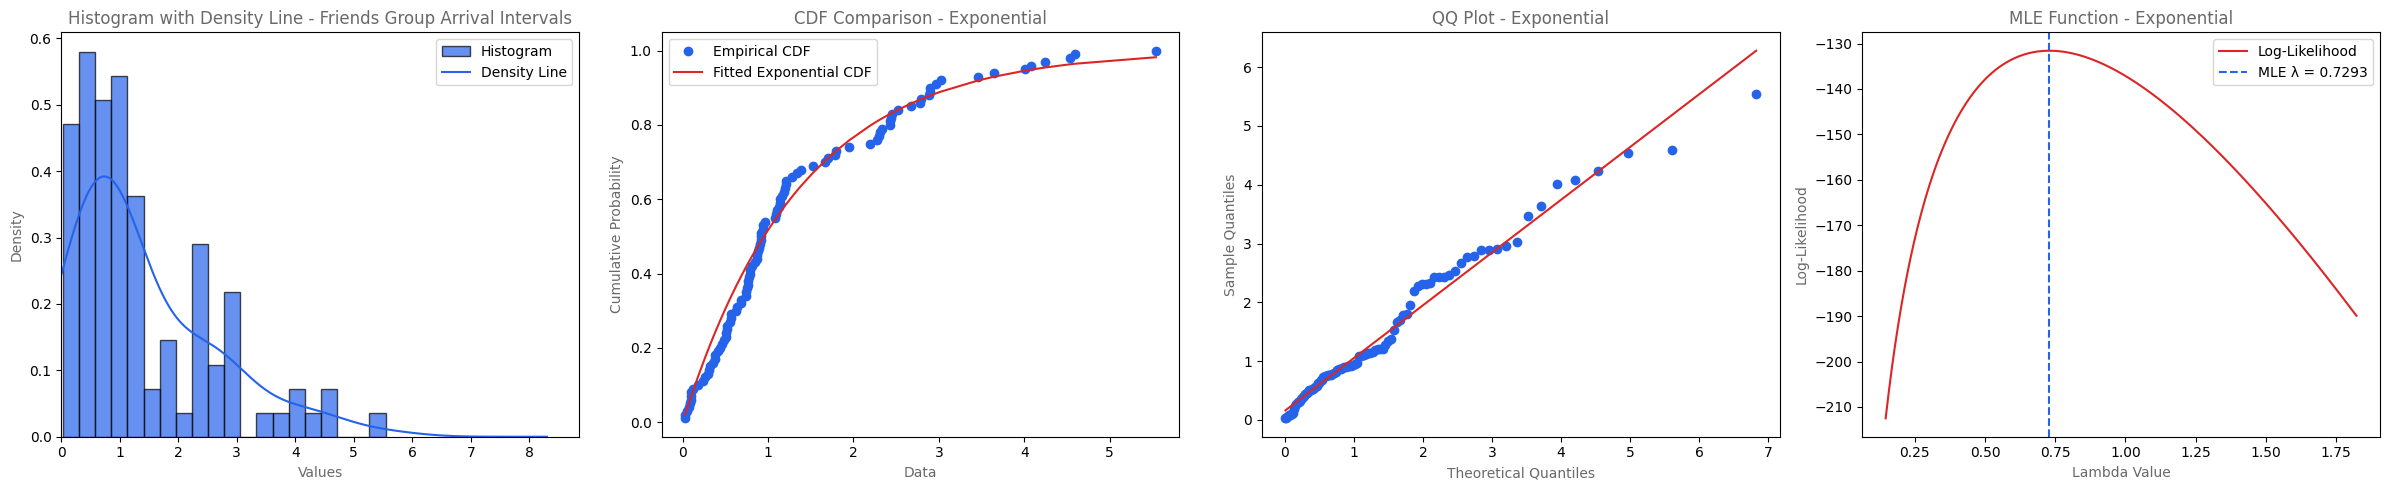

Estimated Exponential Parameter:
Lambda = 0.7293
Mean = 1.3712


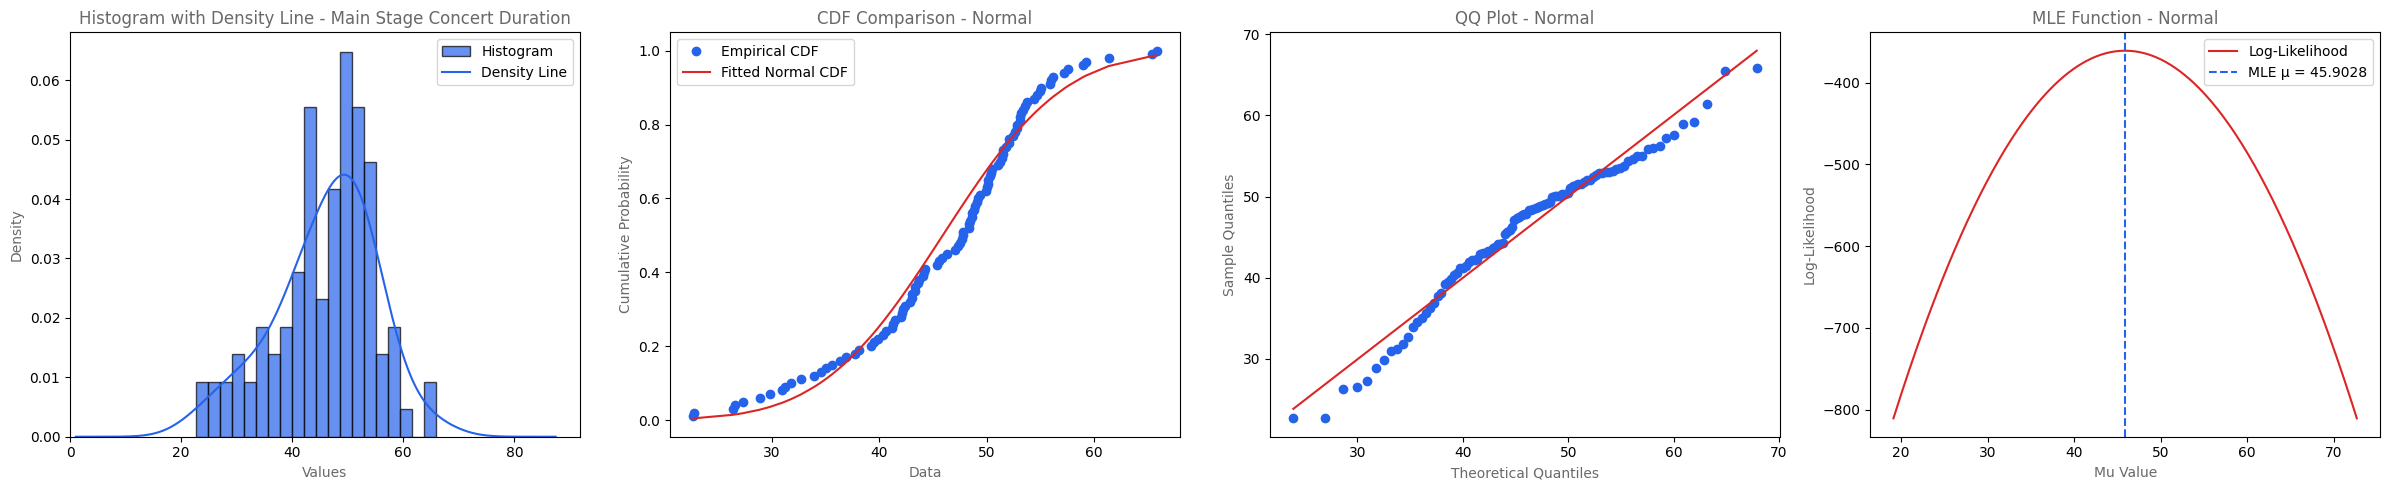

Estimated Normal Parameters:
Mu = 45.9028
Sigma = 8.9274


In [ ]:
# Global Plot Colors
EMPIRICAL_COLOR = "#2563EB"   # Blue - empirical information
THEORETICAL_COLOR = "#DC2626" # Red - theoretical information

# General Helper Functions
def prepare_data(df):
    # Read the first column of a DataFrame, convert it to numeric values, and remove missing values
    column_name = df.columns[0]
    data = pd.to_numeric(df[column_name], errors="coerce").dropna()
    return data, column_name

def histogram_and_density_line(data, title, ax):
    # Plot histogram and KDE based on the empirical data
    ax.hist(
        data,
        bins=20,
        edgecolor="black",
        alpha=0.7,
        label="Histogram",
        color=EMPIRICAL_COLOR,
        density=True
    )
    data.plot(
        kind="kde",
        color=EMPIRICAL_COLOR,
        label="Density Line",
        bw_method=0.5,
        ax=ax
    )
    ax.set_title(f"Histogram with Density Line - {title}", color="dimgray")
    ax.set_xlabel("Values", color="dimgray")
    ax.set_ylabel("Density", color="dimgray")
    ax.set_xlim(left=0)
    ax.legend()

def empirical_cdf(data):
    # Calculate the empirical CDF of the data
    sorted_data = np.sort(data)
    empirical_probabilities = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    return sorted_data, empirical_probabilities

# Exponential Distribution Functions
def MLE_for_lambda(data):
    # Estimate the lambda parameter for the exponential distribution using MLE
    def neg_log_likelihood(lambda_value, data):
        lambda_value = lambda_value[0]
        return -np.sum(np.log(lambda_value) - lambda_value * data)

    initial_lambda = 1 / np.mean(data)

    result = minimize(
        neg_log_likelihood,
        x0=[initial_lambda],
        args=(data,),
        bounds=[(0.0001, None)]
    )

    return result.x[0]

def exponential_CDF_plot(data, lambda_mle, ax):
    # Plot empirical CDF compared to fitted exponential CDF
    sorted_data, empirical_probabilities = empirical_cdf(data)

    fitted_cdf = stats.expon.cdf(
        sorted_data,
        loc=0,
        scale=1 / lambda_mle
    )
    ax.plot(
        sorted_data,
        empirical_probabilities,
        marker="o",
        linestyle="",
        label="Empirical CDF",
        color=EMPIRICAL_COLOR
    )
    ax.plot(
        sorted_data,
        fitted_cdf,
        label="Fitted Exponential CDF",
        color=THEORETICAL_COLOR
    )
    ax.set_title("CDF Comparison - Exponential", color="dimgray")
    ax.set_xlabel("Data", color="dimgray")
    ax.set_ylabel("Cumulative Probability", color="dimgray")
    ax.legend(loc="upper left")

def exponential_QQ_plot(data, lambda_mle, ax):
    # Plot QQ plot for the exponential distribution
    probplot(
        data,
        dist="expon",
        sparams=(0, 1 / lambda_mle),
        plot=ax
    )

    # Empirical sample points
    ax.get_lines()[0].set_markerfacecolor(EMPIRICAL_COLOR)
    ax.get_lines()[0].set_markeredgecolor(EMPIRICAL_COLOR)
    ax.get_lines()[0].set_color(EMPIRICAL_COLOR)

    # Theoretical reference line
    ax.get_lines()[1].set_color(THEORETICAL_COLOR)
    ax.set_title("QQ Plot - Exponential", color="dimgray")
    ax.set_xlabel("Theoretical Quantiles", color="dimgray")
    ax.set_ylabel("Sample Quantiles", color="dimgray")

def exponential_MLE_plot(data, lambda_mle, ax):
    # Plot the log-likelihood function for the exponential distribution
    lambda_values = np.linspace(lambda_mle * 0.2, lambda_mle * 2.5, 300)

    log_likelihood_values = [
        np.sum(np.log(lambda_value) - lambda_value * data)
        for lambda_value in lambda_values
    ]

    # Theoretical likelihood curve
    ax.plot(
        lambda_values,
        log_likelihood_values,
        color=THEORETICAL_COLOR,
        label="Log-Likelihood"
    )

    # Empirical estimate based on the sample
    ax.axvline(
        lambda_mle,
        linestyle="--",
        color=EMPIRICAL_COLOR,
        label=f"MLE λ = {lambda_mle:.4f}"
    )
    ax.set_title("MLE Function - Exponential", color="dimgray")
    ax.set_xlabel("Lambda Value", color="dimgray")
    ax.set_ylabel("Log-Likelihood", color="dimgray")
    ax.legend()

# Normal Distribution Functions
def MLE_for_normal(data):
    # Estimate the mu and sigma parameters for the normal distribution using MLE
    def neg_log_likelihood(params, data):
        mu, sigma = params
        return -np.sum(stats.norm.logpdf(data, loc=mu, scale=sigma))

    initial_mu = np.mean(data)
    initial_sigma = np.std(data)

    result = minimize(
        neg_log_likelihood,
        x0=[initial_mu, initial_sigma],
        args=(data,),
        bounds=[(None, None), (0.0001, None)]
    )
    mu_mle, sigma_mle = result.x
    return mu_mle, sigma_mle

def normal_CDF_plot(data, mu_mle, sigma_mle, ax):
    # Plot empirical CDF compared to fitted normal CDF
    sorted_data, empirical_probabilities = empirical_cdf(data)

    fitted_cdf = stats.norm.cdf(
        sorted_data,
        loc=mu_mle,
        scale=sigma_mle
    )
    ax.plot(
        sorted_data,
        empirical_probabilities,
        marker="o",
        linestyle="",
        label="Empirical CDF",
        color=EMPIRICAL_COLOR
    )
    ax.plot(
        sorted_data,
        fitted_cdf,
        label="Fitted Normal CDF",
        color=THEORETICAL_COLOR
    )
    ax.set_title("CDF Comparison - Normal", color="dimgray")
    ax.set_xlabel("Data", color="dimgray")
    ax.set_ylabel("Cumulative Probability", color="dimgray")
    ax.legend(loc="upper left")

def normal_QQ_plot(data, mu_mle, sigma_mle, ax):
    # Plot QQ plot for the normal distribution
    probplot(
        data,
        dist="norm",
        sparams=(mu_mle, sigma_mle),
        plot=ax
    )

    # Empirical sample points
    ax.get_lines()[0].set_markerfacecolor(EMPIRICAL_COLOR)
    ax.get_lines()[0].set_markeredgecolor(EMPIRICAL_COLOR)
    ax.get_lines()[0].set_color(EMPIRICAL_COLOR)

    # Theoretical reference line
    ax.get_lines()[1].set_color(THEORETICAL_COLOR)
    ax.set_title("QQ Plot - Normal", color="dimgray")
    ax.set_xlabel("Theoretical Quantiles", color="dimgray")
    ax.set_ylabel("Sample Quantiles", color="dimgray")

def normal_MLE_plot(data, mu_mle, sigma_mle, ax):
    # Plot the log likelihood function for the normal distribution
    # Sigma is fixed at its MLE value, and the function is shown over mu
    mu_values = np.linspace(
        np.mean(data) - 3 * np.std(data),
        np.mean(data) + 3 * np.std(data),
        300
    )
    log_likelihood_values = [
        np.sum(stats.norm.logpdf(data, loc=mu_value, scale=sigma_mle))
        for mu_value in mu_values
    ]

    # Theoretical likelihood curve
    ax.plot(
        mu_values,
        log_likelihood_values,
        color=THEORETICAL_COLOR,
        label="Log-Likelihood"
    )

    # Empirical estimate based on the sample
    ax.axvline(
        mu_mle,
        linestyle="--",
        color=EMPIRICAL_COLOR,
        label=f"MLE μ = {mu_mle:.4f}"
    )
    ax.set_title("MLE Function - Normal", color="dimgray")
    ax.set_xlabel("Mu Value", color="dimgray")
    ax.set_ylabel("Log-Likelihood", color="dimgray")
    ax.legend()

# Full Analysis Functions
def analyze_friends_group_arrival_intervals():
    # Analyze FriendsGroup arrival intervals using the exponential distribution
    display(HTML("<h2 style='text-align: center; color: #2563EB;'>Friends Group Arrival Intervals - Exponential Distribution</h2>"))

    data, column_name = prepare_data(friends_group_arrival_intervals_df)
    lambda_mle = MLE_for_lambda(data)

    fig, axs = plt.subplots(1, 4, figsize=(24, 5))

    histogram_and_density_line(
        data,
        "Friends Group Arrival Intervals",
        axs[0]
    )
    exponential_CDF_plot(
        data,
        lambda_mle,
        axs[1]
    )
    exponential_QQ_plot(
        data,
        lambda_mle,
        axs[2]
    )
    exponential_MLE_plot(
        data,
        lambda_mle,
        axs[3]
    )
    plt.tight_layout()
    plt.show()
    print("Estimated Exponential Parameter:")
    print(f"Lambda = {lambda_mle:.4f}")
    print(f"Mean = {1 / lambda_mle:.4f}")

def analyze_main_stage_concert_duration():
    # Analyze MainStage concert duration using the normal distribution
    display(HTML("<h2 style='text-align: center; color: #2563EB;'>Main Stage Concert Duration - Normal Distribution</h2>"))
    data, column_name = prepare_data(main_stage_concert_duration_df)
    mu_mle, sigma_mle = MLE_for_normal(data)

    fig, axs = plt.subplots(1, 4, figsize=(24, 5))

    histogram_and_density_line(
        data,
        "Main Stage Concert Duration",
        axs[0]
    )
    normal_CDF_plot(
        data,
        mu_mle,
        sigma_mle,
        axs[1]
    )
    normal_QQ_plot(
        data,
        mu_mle,
        sigma_mle,
        axs[2]
    )
    normal_MLE_plot(
        data,
        mu_mle,
        sigma_mle,
        axs[3]
    )
    plt.tight_layout()
    plt.show()
    print("Estimated Normal Parameters:")
    print(f"Mu = {mu_mle:.4f}")
    print(f"Sigma = {sigma_mle:.4f}")

# Run Analysis
analyze_friends_group_arrival_intervals()
analyze_main_stage_concert_duration()

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

<h2>ניתוח התפלגות עבור זמני הגעה של קבוצות חברים ומשך הופעות בבמה המרכזית</h2>

בשלב זה ביצענו ניתוח ראשוני לשני משתנים מתוך קובץ הנתונים:

<b>Friends Group Arrival Intervals</b> - מרווחי הזמן בין הגעות של קבוצות חברים.  

<b>Main Stage Concert Duration</b> - משך ההופעות בבמה המרכזית.


מטרת הניתוח היא לבדוק איזו התפלגות מתאימה לכל אחד מהמשתנים, על בסיס כלים גרפיים וסטטיסטיים.  
עבור זמני ההגעה של קבוצות החברים נבחנה התאמה להתפלגות <b>אקספוננציאלית</b>, ועבור משך ההופעות בבמה המרכזית נבחנה התאמה להתפלגות <b>נורמלית</b>.





<h3>היסטוגרמה וקו צפיפות</h3>

עבור כל משתנה הוצגה היסטוגרמה יחד עם קו צפיפות אמפירי.



עבור <b>Friends Group Arrival Intervals</b>, ההיסטוגרמה מאפשרת לבחון האם קיימת תבנית המתאימה להתפלגות אקספוננציאלית. בהתפלגות מסוג זה מצופה לראות ריכוז גבוה יחסית של תצפיות בערכים נמוכים, כאשר שכיחות הערכים הולכת ופוחתת ככל שמרווח הזמן גדל. תבנית זו מתאימה למצבים של זמני ביניים בין הגעות, ולכן יש היגיון לבדוק התאמה להתפלגות זו.






עבור <b>Main Stage Concert Duration</b>, ההיסטוגרמה מאפשרת לבחון האם משכי ההופעות מתרכזים סביב ערך מרכזי מסוים, עם פיזור יחסית סימטרי סביבו. מבנה כזה עשוי להתאים להתפלגות נורמלית, שבה רוב הערכים נמצאים סביב הממוצע ורק מעט ערכים נמצאים בקצוות.


---


<h3>התאמה לפונקציה המצטברת - CDF</h3>

בנוסף להיסטוגרמה, הוצגה השוואה בין פונקציית ההתפלגות המצטברת האמפירית לבין פונקציית ההתפלגות המצטברת התאורטית.



עבור <b>Friends Group Arrival Intervals</b>, השווינו בין ה-CDF האמפירי לבין ה-CDF של ההתפלגות האקספוננציאלית. ככל שהקו התאורטי קרוב יותר לנקודות האמפיריות, כך ניתן לומר שההתפלגות האקספוננציאלית מתארת טוב יותר את הנתונים.



עבור <b>Main Stage Concert Duration</b>, השווינו בין ה-CDF האמפירי לבין ה-CDF של ההתפלגות הנורמלית. התאמה טובה בין שני הקווים מצביעה על כך שההתפלגות הנורמלית מצליחה לתאר את אופן ההצטברות של הנתונים לאורך טווח הערכים.

---

<h3>QQ Plot</h3>

ה-QQ Plot משמש להשוואה בין הכמותונים של הנתונים בפועל לבין הכמותונים הצפויים לפי ההתפלגות התאורטית.


עבור <b>Friends Group Arrival Intervals</b>, ה-QQ Plot בוחן האם מרווחי ההגעה מתאימים להתפלגות אקספוננציאלית. אם הנקודות ממוקמות קרוב לקו הישר, הדבר מעיד על התאמה טובה. סטיות משמעותיות, בעיקר בקצוות, עשויות להעיד על כך שההתפלגות האקספוננציאלית אינה מתארת היטב ערכים חריגים.


עבור <b>Main Stage Concert Duration</b>, ה-QQ Plot בוחן את ההתאמה להתפלגות נורמלית. במקרה של התאמה טובה, הנקודות צפויות להסתדר בקירוב לאורך קו ישר. סטיות מהקו עשויות להעיד על חוסר סימטריה, זנבות כבדים או ערכים חריגים במדגם.

---
<h3>מציאת פרמטרים לפי MLE</h3>

לאחר בחירת ההתפלגויות החשודות, חישבנו את הפרמטרים המתאימים לכל התפלגות באמצעות שיטת <b>Maximum Likelihood Estimation — MLE</b>.


עבור <b>Friends Group Arrival Intervals</b>, נבחרה התפלגות אקספוננציאלית. בהתפלגות זו הפרמטר המרכזי הוא λ, המייצג את קצב ההגעה. את אומדן λ חישבנו לפי הנוסחה:

</div>

$$
\lambda_{MLE} = \frac{1}{\bar{x}}
$$

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

כאשר x̄ הוא ממוצע מרווחי הזמן בין הגעות קבוצות החברים.



עבור <b>Main Stage Concert Duration</b>, נבחרה התפלגות נורמלית. בהתפלגות זו הפרמטרים הם:

</div>

$$
\mu
$$

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

המייצג את ממוצע משך ההופעה, ו-

</div>

$$
\sigma
$$

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

המייצג את סטיית התקן של משך ההופעה.

באמצעות MLE נאמדו הערכים של μ ו-σ, כך שההתפלגות הנורמלית שתתקבל תהיה זו שמתאימה בצורה הטובה ביותר לנתוני משך ההופעות במדגם.

---

<h3>סיכום</h3>

ההיסטוגרמות, גרפי ה-CDF, גרפי ה-QQ וגרפי ה-MLE מספקים יחד בסיס ראשוני לבחינת איכות ההתאמה של ההתפלגויות שנבחרו. בהמשך, נשתמש גם במבחן KS על מנת לתמוך בהחלטה באופן סטטיסטי.

</div>

<div dir="rtl" style="text-align: right; color: blue;">

###מבחני טיב התאמה - KS

</div>

In [ ]:

def empirical_cdf_for_ks(data):
    # Compute the empirical CDF of the data
    data_sorted = np.sort(data)
    n = len(data)
    empirical_cdf_values = np.arange(1, n + 1) / n
    return data_sorted, empirical_cdf_values

def ks_test(data, theoretical_cdf, *params):
    # Compute the KS test statistic
    n = len(data)
    data_sorted, empirical_cdf_values = empirical_cdf_for_ks(data)
    theoretical_cdf_values = theoretical_cdf(data_sorted, *params)
    d_statistic = np.max(
        np.abs(empirical_cdf_values - theoretical_cdf_values)
    )

    # Adjusted KS statistic according to the course-style formula
    adjusted_d_statistic = (
        (np.sqrt(n) + 0.26 + (0.25 / np.sqrt(n)))
        * (d_statistic - 0.2 / n)
    )
    return adjusted_d_statistic

def exponential_cdf(x, lambda_mle):
    # Theoretical CDF of the exponential distribution
    return 1 - np.exp(-lambda_mle * x)

def normal_cdf(x, mu_mle, sigma_mle):
    # Theoretical CDF of the normal distribution
    return stats.norm.cdf(x, loc=mu_mle, scale=sigma_mle)

def d_critical(alpha):
    # Critical values according to the required confidence level
    confidence_level = 1 - alpha
    critical_values = {
        0.85: 0.926,
        0.90: 0.900,
        0.95: 1.094,
        0.975: 1.190,
        0.99: 1.308
    }
    return critical_values.get(confidence_level)

def hypothesis_test(d_statistic, critical_value):
    # Decide whether to reject or fail to reject H0
    if d_statistic > critical_value:
        print(f"{d_statistic:.4f} > {critical_value:.4f}")
        print("Reject H0")
        print("The fitted distribution does not seem to fit the data well.")
    else:
        print(f"{d_statistic:.4f} < {critical_value:.4f}")
        print("Fail to reject H0")
        print("The fitted distribution seems reasonable for the data.")

def run_ks_test_for_friends_group(alpha=0.05):
    # Run KS test for FriendsGroup arrival intervals using the exponential distribution
    display(HTML(
        "<h2 style='text-align: left; color: #2563EB;'>"
        "Friends Group Arrival Intervals - KS Test for Exponential Distribution"
        "</h2>"
    ))
    data, column_name = prepare_data(friends_group_arrival_intervals_df)
    lambda_mle = MLE_for_lambda(data)
    d_statistic = ks_test(
        data,
        exponential_cdf,
        lambda_mle
    )
    critical_value = d_critical(alpha)
    print("Distribution: Exponential")
    print(f"Estimated Lambda: {lambda_mle:.4f}")
    print(f"Estimated Mean: {1 / lambda_mle:.4f}")
    print(f"D Statistic: {d_statistic:.4f}")
    print(f"Critical Value: {critical_value:.4f}")
    hypothesis_test(d_statistic, critical_value)

def run_ks_test_for_main_stage(alpha=0.05):
    # Run KS test for MainStage concert duration using the normal distribution
    display(HTML(
        "<h2 style='text-align: left; color: #2563EB;'>"
        "Main Stage Concert Duration - KS Test for Normal Distribution"
        "</h2>"
    ))
    data, column_name = prepare_data(main_stage_concert_duration_df)
    mu_mle, sigma_mle = MLE_for_normal(data)
    d_statistic = ks_test(
        data,
        normal_cdf,
        mu_mle,
        sigma_mle
    )
    critical_value = d_critical(alpha)
    print("Distribution: Normal")
    print(f"Estimated Mu: {mu_mle:.4f}")
    print(f"Estimated Sigma: {sigma_mle:.4f}")
    print(f"D Statistic: {d_statistic:.4f}")
    print(f"Critical Value: {critical_value:.4f}")
    hypothesis_test(d_statistic, critical_value)


# Run KS Tests
run_ks_test_for_friends_group(alpha=0.05)
run_ks_test_for_main_stage(alpha=0.05)

Distribution: Exponential
Estimated Lambda: 0.7293
Estimated Mean: 1.3712
D Statistic: 0.7865
Critical Value: 1.0940
0.7865 < 1.0940
Fail to reject H0
The fitted distribution seems reasonable for the data.


Distribution: Normal
Estimated Mu: 45.9028
Estimated Sigma: 8.9274
D Statistic: 0.9297
Critical Value: 1.0940
0.9297 < 1.0940
Fail to reject H0
The fitted distribution seems reasonable for the data.


<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

---

### אישוש התפלגויות באמצעות מבחן Kolmogorov-Smirnov (KS)

בהמשך לניתוח הגרפי שבוצע באמצעות היסטוגרמה, פונקציית CDF ו־QQ Plot, ביצענו מבחן Kolmogorov-Smirnov על מנת לבדוק באופן סטטיסטי את התאמת ההתפלגויות שנבחרו לנתונים.

מבחן KS משווה בין פונקציית ההתפלגות המצטברת האמפירית של הנתונים לבין פונקציית ההתפלגות המצטברת התאורטית של ההתפלגות שנבדקת.  
במידה שסטטיסטיקת המבחן \(D\) קטנה מהערך הקריטי, אין לנו מספיק עדות לדחות את השערת האפס, ולכן ניתן לומר כי ההתפלגות שנבדקה מתאימה לנתונים ברמת המובהקות שנבחרה.

---

#### תוצאות עבור Friends Group Arrival Intervals - התפלגות אקספוננציאלית:

- סטטיסטיקת המבחן:

  $$
  D = 0.7865
  $$

- הערך הקריטי:

  $$
  D_{\text{critical}} = 1.0940
  $$

- פרמטר ההתפלגות שנאמד:

  $$
  \lambda = 0.7293
  $$

 מתקיים:

$$
D < D_{\text{critical}}
$$

 אין לנו מספיק עדות לדחות את השערת האפס, ולכן ניתן לומר כי מרווחי הזמן בין הגעות קבוצות החברים מתאימים להתפלגות אקספוננציאלית עם הפרמטר λ שנאמד.


---

#### תוצאות עבור Main Stage Concert Duration - התפלגות נורמלית:

- סטטיסטיקת המבחן:

  $$
  D = 0.9297
  $$

- הערך הקריטי:

  $$
  D_{\text{critical}} = 1.0940
  $$

- פרמטרי ההתפלגות שנאמדו:

  $$
  \mu = 45.9028
  $$

  $$
  \sigma = 8.9274
  $$

 מתקיים:

$$
D < D_{\text{critical}}
$$

 אין לנו מספיק עדות לדחות את השערת האפס, ולכן ניתן לומר כי משך ההופעות בבמה המרכזית מתאים להתפלגות נורמלית עם הפרמטרים μ ו-σ שנאמדו.

---

### מסקנה:

בהתאם לתוצאות מבחן KS ולניתוח הגרפי שבוצע, נבחרו ההתפלגויות הבאות עבור המשך הסימולציה:

- עבור **Friends Group Arrival Intervals**, נבחרה התפלגות אקספוננציאלית, מאחר שהיא מתאימה הן מבחינה סטטיסטית והן מבחינה לוגית למרווחי זמן בין הגעות.

- עבור **Main Stage Concert Duration**, נבחרה התפלגות נורמלית, מאחר שמשכי ההופעות מתרכזים סביב ערך ממוצע מסוים ומתפזרים סביבו.

התפלגויות אלו ישמשו בהמשך לבניית פונקציות הדגימה עבור הסימולציה.

</div>

<div dir="rtl" style="text-align: right; color: blue;">

# אלגוריתמי דגימה
בחלק זה מוצגים אלגוריתמי הדגימה שבהם נעשה שימוש בסימולציה. הדגימות מבוססות על משתנה אחיד

U∼U(0,1), וממנו נגזרות דגימות מהתפלגויות אחידה, אקספוננציאלית, נורמלית ואחידה בדידה באמצעות טרנספורמציות מתאימות. בנוסף מוצגים חישובים מתמטיים לדגימת משתנים בזמן, כגון זמני הגעה בחלונות זמן, משכי שירות, משכי פעילות בפעיליות וזמני אוכל, בהתאם להתפלגויות שהוגדרו במודל.

<div dir="rtl" style="text-align: right; color: blue;">

## חישוב אלגוריתמי דגימה

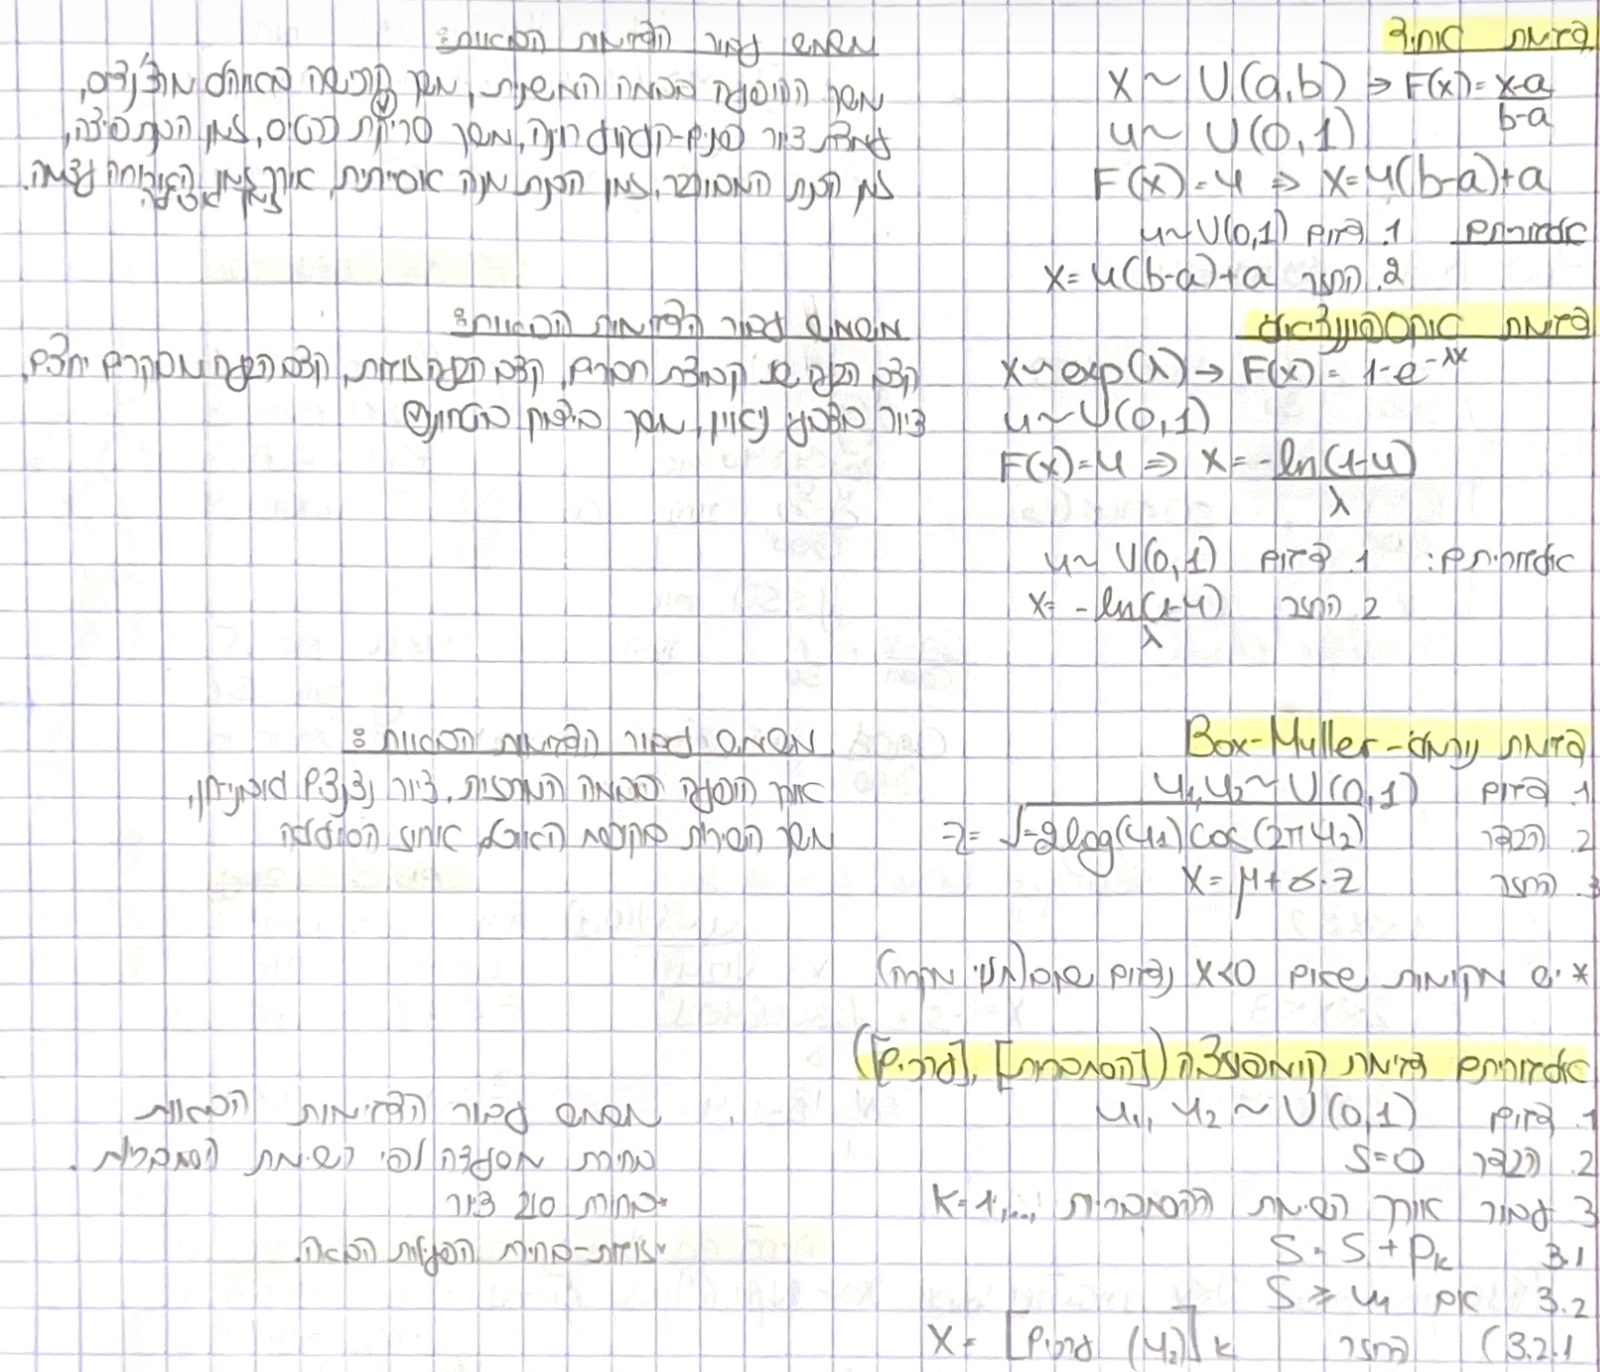

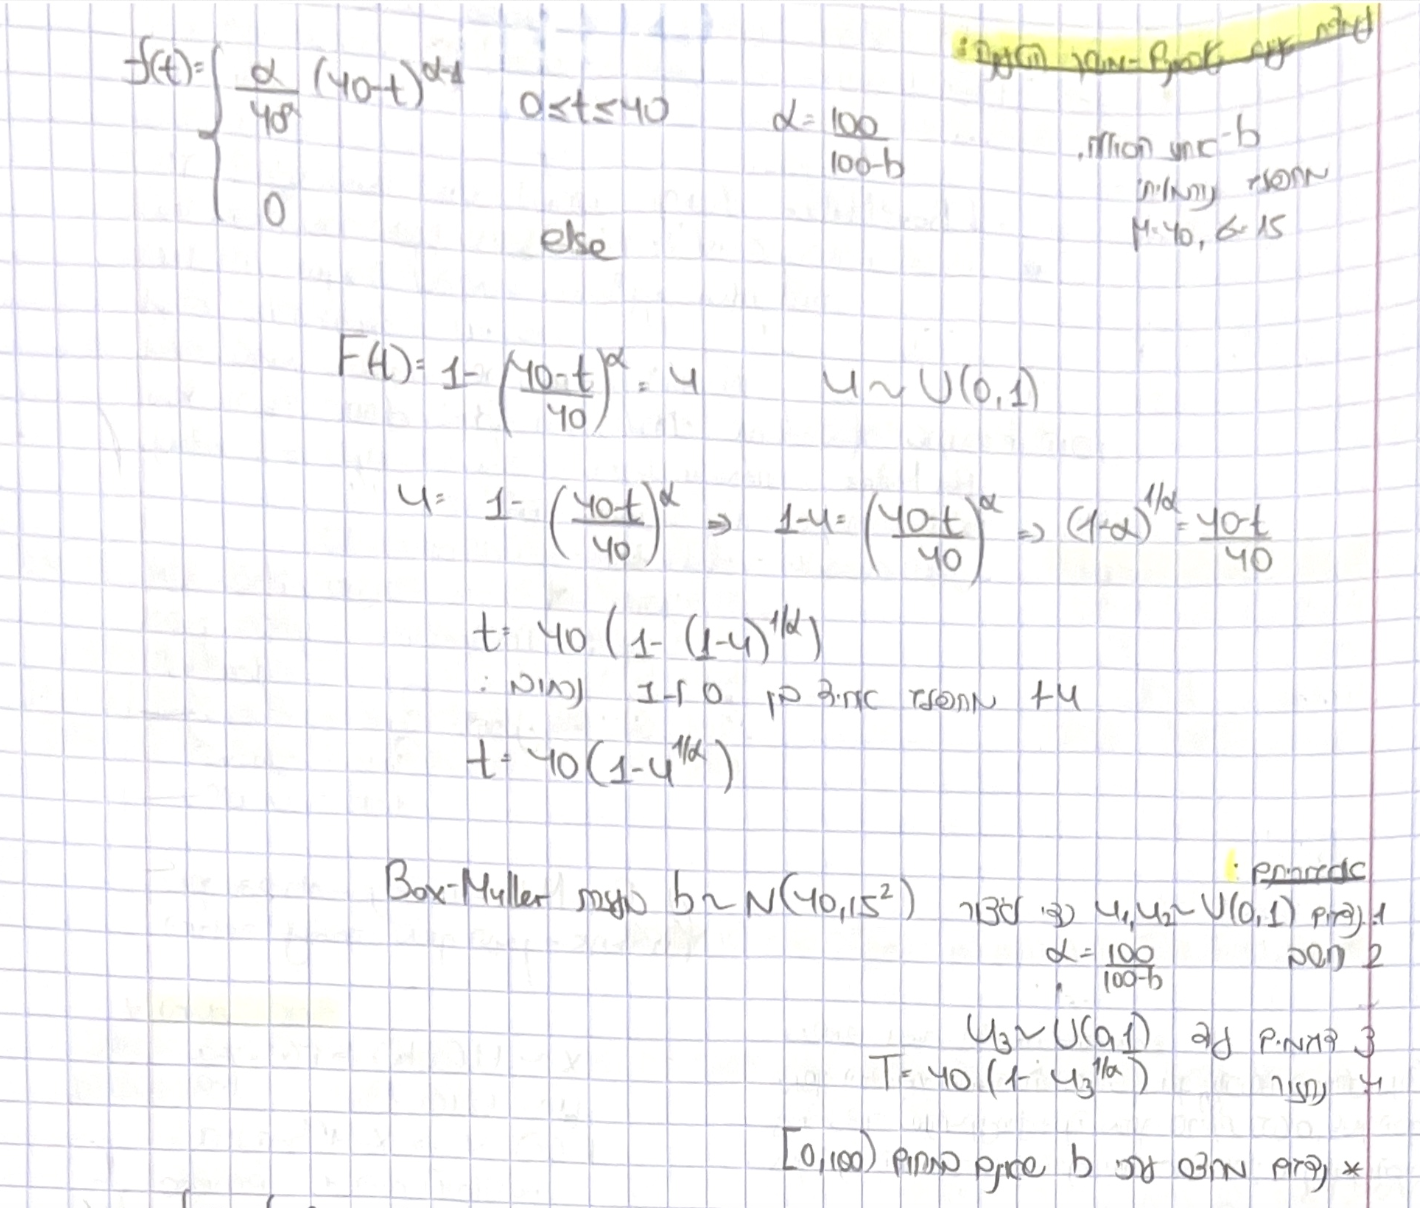

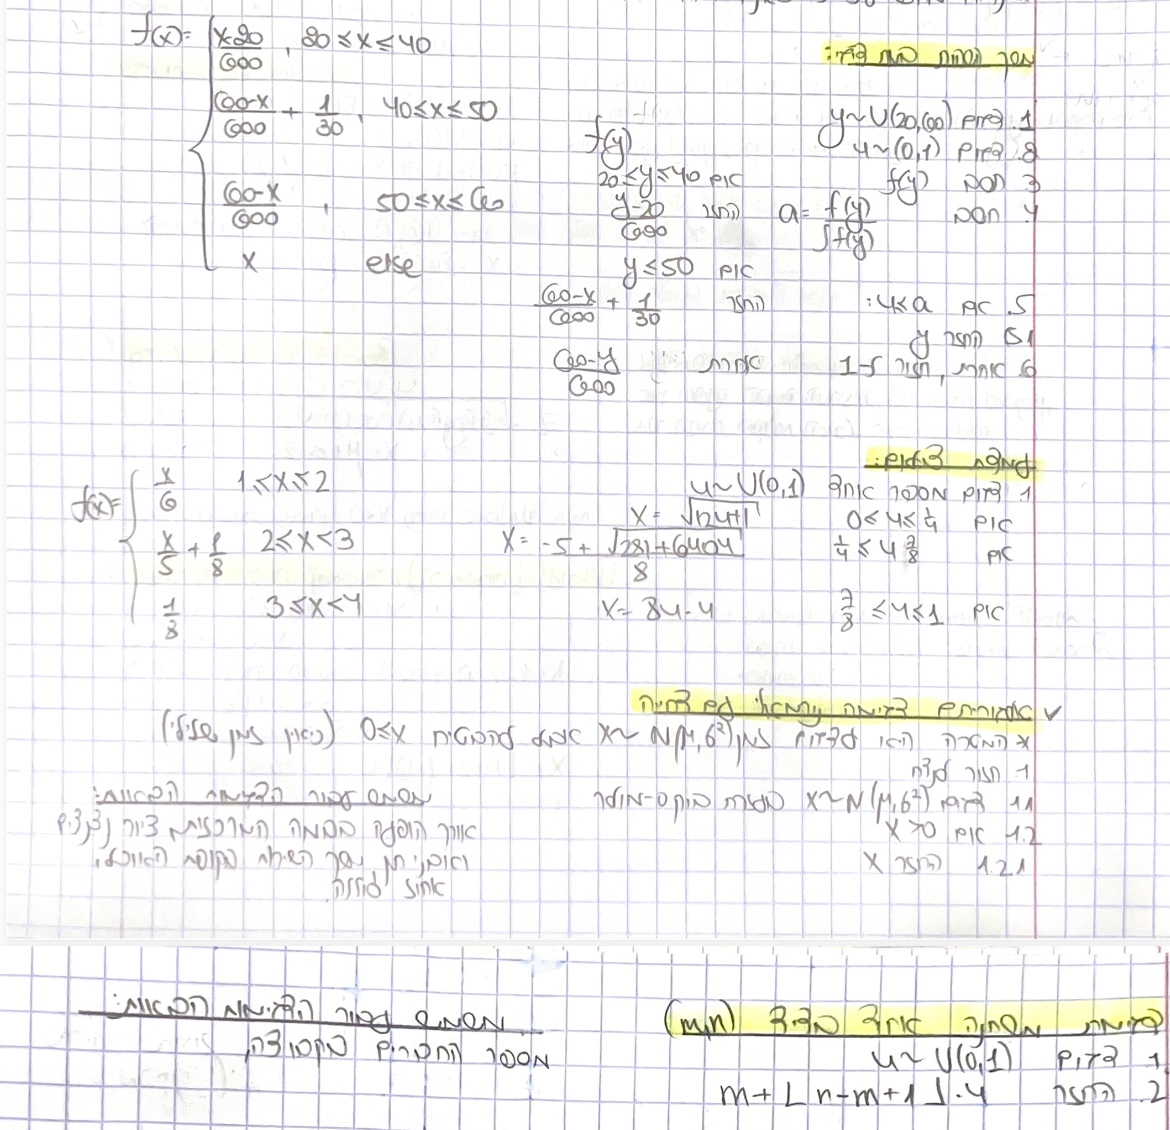

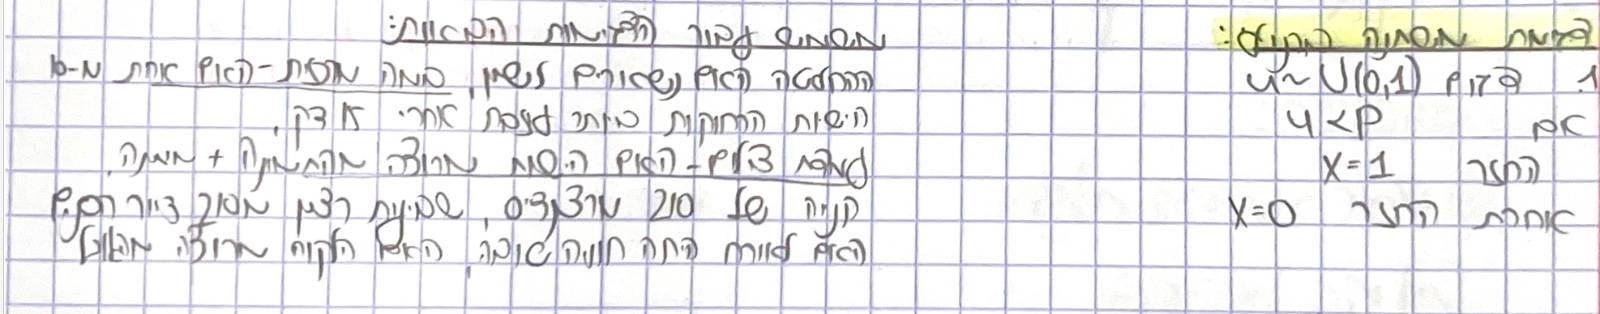

<div dir="rtl" style="text-align: right; color: blue;">

## קוד עבור קבועים וחבילות בסימולציה

In [ ]:
import heapq
import math
import random
import statistics
from dataclasses import dataclass, field
from typing import Optional, Sequence, TypeVar

from scipy.stats import t

T = TypeVar("T")

SEED = 102
_SIM_ALREADY_RAN = False

# Time constants (active minutes since each 09:00 opening)
OPEN = 0.0
TEN_AM = 60.0
ONE_PM = 240.0
THREE_PM = 360.0
FOUR_PM = 420.0
CLOSE = 660.0
DAY_2_START = 660.0
SIM_END = 1320.0
MAX_RATING = 10.0
EPSILON = 1e-9

MAIN_STAGE = "MainStage"
SIDE_STAGE = "SideStage"
DJ_STAGE = "DJStage"
MERCH = "MerchTent"
PHOTO = "PhotoStation"
CHARGING = "ChargingStation"
BODY_ART = "BodyArt"
PERSONAL_RESOURCES = {"Entrance", MERCH, CHARGING, BODY_ART}

PERFORMANCES = [MAIN_STAGE, SIDE_STAGE, DJ_STAGE]
STATIONS = [MERCH, PHOTO, CHARGING, BODY_ART]
RESTAURANTS = ["Burger", "Pizza", "Asian"]

# ----------------------------------------------------------- #
# -------------------- SCENARIO CONFIG ---------------------- #
# ----------------------------------------------------------- #

BUDGET = 1_000_000

# ----------------------------------------------------------- #
# -------------------- REVENUE CONFIG ----------------------- #
# ----------------------------------------------------------- #
# Every real revenue source is a tunable parameter here so we can study the BASE
# revenue distribution and later spin up alternatives that change these values.
# NOTE: Stages, Body Art, and Charging generate no revenue today, so they have no
# entry here. Add one if a future alternative makes them paid.
REVENUE = {
    "ticket_per_person": 500.0,
    # Overnight FriendsGroups pay 700/person = 500 base ticket + 200 sleep premium.
    "overnight_friends_premium_per_person": 200.0,
    # Couples who stay overnight (Day 1, rating > 7) pay this extra per person.
    "couple_overnight_extra_per_person": 250.0,
    "food": {
        "Burger": 100.0,
        "Pizza_single": 40.0,
        "Pizza_per_3": 100.0,
        "Asian": 65.0,
    },
    # Each merch component: (price, purchase_probability). The band shirt probability
    # stays scenario-driven (SCN_BAND_SHIRT_PROB); only its price lives here.
    "merch": {
        "base": (100.0, 0.8),
        "accessory": (50.0, 0.4),
        "small": (40.0, 0.9),
        "band_shirt_price": 200.0,
    },
    "photo": {"price": 30.0, "prob": 0.70},
}

SCN_BAD_DISH_PROB = 0.40
SCN_LUNCH_PROB = 0.70
SCN_STAGE_CAPACITY_MULTIPLIER = 1.0
SCN_BAND_SHIRT_PROB = 0.30
SCN_MAINSTREAM_GENRE_WEIGHT = 3.0
SCN_PHOTO_STATIONS = 3
SCN_BODY_ART_ARTISTS = 2
SCN_ARRIVAL_RATE_MULTIPLIER = 1.0   # Festival Advertising: scales guest arrival rate
SCN_AUTOMATIC_ENTRANCE = False      # Automatic Entrance: drop ticket scan, keep security only
SCN_INITIAL_RATING = 5.0            # Visitor Benefit: starting satisfaction index

SCENARIOS = {
    "BASE": {
        "invest_cost": 0,
        "alternatives": "None",
        "bad_dish_prob": 0.40,
        "lunch_prob": 0.70,
        "stage_capacity_multiplier": 1.0,
        "band_shirt_prob": 0.30,
        "mainstream_genre_weight": 3.0,
        "photo_stations": 3,
        "body_art_artists": 2,
        "arrival_rate_multiplier": 1.0,
        "automatic_entrance": False,
        "initial_rating": 5.0,
        "label": "BASE (Current state)",
    },
    "ALT1": {
        # Popular Mainstream Bands (300k) + Visitor Benefit (200k) + Better Kitchen Staff (500k) = 1,000,000
        "invest_cost": 1_000_000,
        "alternatives": "Popular Mainstream Bands + Visitor Benefit + Better Kitchen Staff",
        "bad_dish_prob": 0.10,            # Better Kitchen Staff
        "lunch_prob": 0.85,               # Better Kitchen Staff
        "stage_capacity_multiplier": 1.0,
        "band_shirt_prob": 0.80,          # Popular Mainstream Bands
        "mainstream_genre_weight": 4.0,   # Popular Mainstream Bands
        "photo_stations": 3,
        "body_art_artists": 2,
        "arrival_rate_multiplier": 1.0,
        "automatic_entrance": False,
        "initial_rating": 6.5,            # Visitor Benefit
        "label": "ALT1 (Mainstream Bands + Visitor Benefit + Kitchen) [1.0M]",
    },
    "ALT2": {
        # Festival Advertising (200k) + Automatic Entrance (600k) + Visitor Benefit (200k) = 1,000,000
        "invest_cost": 1_000_000,
        "alternatives": "Festival Advertising + Automatic Entrance Stations + Visitor Benefit",
        "bad_dish_prob": 0.40,
        "lunch_prob": 0.70,
        "stage_capacity_multiplier": 1.0,
        "band_shirt_prob": 0.30,
        "mainstream_genre_weight": 3.0,
        "photo_stations": 3,
        "body_art_artists": 2,
        "arrival_rate_multiplier": 1.2,   # Festival Advertising (+20% arrivals)
        "automatic_entrance": True,       # Automatic Entrance Stations
        "initial_rating": 6.5,            # Visitor Benefit
        "label": "ALT2 (Advertising + Automatic Entrance + Visitor Benefit) [1.0M]",
    },
}

# The report compares the current state against two selected feasible alternatives.
SCENARIO_KEYS = tuple(SCENARIOS.keys())

# COMPARISON PHASE: BASE vs the two chosen alternatives. The single-scenario revenue
# distribution study (phase 1) ran with ACTIVE_SCENARIO_KEYS = ("BASE",); set it back to
# that to re-run the distribution-only report.
ACTIVE_SCENARIO_KEYS = ("BASE", "ALT1", "ALT2")

# Revenue buckets reported for the distribution study (see get_metrics income_by_source).
REVENUE_METRICS = ("ticket_income", "sleep_income", "food_income", "merch_income", "photo_income")

# Metrics chosen for the alternative comparison (all maximized):
#   ticket_income_total = base entry + overnight lodging (ticket_income + sleep_income)
#   merch_income        = total merchandise revenue
#   avg_rating          = average guest satisfaction at exit
PRIMARY_METRICS = ("ticket_income_total", "merch_income", "avg_rating")
METRIC_DIRECTIONS = {
    "ticket_income_total": "maximize",
    "merch_income": "maximize",
    "avg_rating": "maximize",
}


# Applies the selected scenario settings to global parameters.
def apply_scenario_to_globals(scn: dict) -> None:
    global SCN_BAD_DISH_PROB, SCN_LUNCH_PROB, SCN_STAGE_CAPACITY_MULTIPLIER
    global SCN_BAND_SHIRT_PROB, SCN_MAINSTREAM_GENRE_WEIGHT
    global SCN_PHOTO_STATIONS, SCN_BODY_ART_ARTISTS
    global SCN_ARRIVAL_RATE_MULTIPLIER, SCN_AUTOMATIC_ENTRANCE, SCN_INITIAL_RATING

    SCN_BAD_DISH_PROB = float(scn["bad_dish_prob"])
    SCN_LUNCH_PROB = float(scn["lunch_prob"])
    SCN_STAGE_CAPACITY_MULTIPLIER = float(scn["stage_capacity_multiplier"])
    SCN_BAND_SHIRT_PROB = float(scn["band_shirt_prob"])
    SCN_MAINSTREAM_GENRE_WEIGHT = float(scn["mainstream_genre_weight"])
    SCN_PHOTO_STATIONS = int(scn["photo_stations"])
    SCN_BODY_ART_ARTISTS = int(scn["body_art_artists"])
    SCN_ARRIVAL_RATE_MULTIPLIER = float(scn["arrival_rate_multiplier"])
    SCN_AUTOMATIC_ENTRANCE = bool(scn["automatic_entrance"])
    SCN_INITIAL_RATING = float(scn["initial_rating"])


# Checks that the configured scenarios are valid for the report.
def validate_scenarios() -> None:
    if tuple(SCENARIOS.keys()) != ("BASE", "ALT1", "ALT2"):
        raise ValueError("SCENARIOS must contain exactly BASE, ALT1, and ALT2 in report order")
    required_keys = {
        "invest_cost",
        "alternatives",
        "bad_dish_prob",
        "lunch_prob",
        "stage_capacity_multiplier",
        "band_shirt_prob",
        "mainstream_genre_weight",
        "photo_stations",
        "body_art_artists",
        "arrival_rate_multiplier",
        "automatic_entrance",
        "initial_rating",
        "label",
    }
    for key, scn in SCENARIOS.items():
        missing_keys = required_keys - set(scn)
        if missing_keys:
            raise ValueError(f"{key} is missing Queuechella parameters: {sorted(missing_keys)}")
        extra_keys = set(scn) - required_keys
        if extra_keys:
            raise ValueError(f"{key} contains non-Queuechella parameters: {sorted(extra_keys)}")
        if int(scn["invest_cost"]) > BUDGET:
            raise ValueError(f"{key} exceeds budget")
    if SCENARIO_KEYS != ("BASE", "ALT1", "ALT2"):
        raise ValueError("SCENARIO_KEYS must be exactly BASE, ALT1, and ALT2")
    if tuple(SCENARIOS.keys()) != SCENARIO_KEYS:
        raise ValueError("SCENARIO_KEYS must match the configured scenarios in report order")


# Returns the festival day for a simulation time.
def day_number(t_now: float) -> int:
    return 1 if t_now < DAY_2_START else 2


# Returns the start time of the current festival day.
def day_start(t_now: float) -> float:
    return 0.0 if t_now < DAY_2_START else DAY_2_START


# Returns the closing time of the current festival day.
def day_end(t_now: float) -> float:
    return day_start(t_now) + CLOSE


# Converts global simulation time to local day time.
def local_time(t_now: float) -> float:
    return t_now % CLOSE


# Converts a day and local minute value to global simulation time.
def day_local_to_global(day: int, local_minutes: float) -> float:
    return (0.0 if int(day) == 1 else DAY_2_START) + float(local_minutes)


# Returns the global start and end times for an arrival window.
def arrival_window_global(day: int, start_local: float, end_local: float) -> tuple[float, float]:
    return day_local_to_global(day, start_local), day_local_to_global(day, end_local)


# Keeps a rating value within the allowed rating range.
def clamp_rating(value: float) -> float:
    return max(0.0, min(MAX_RATING, float(value)))

<div dir="rtl" style="text-align: right; color: blue;">

## אאלגוריתמי דגימה כלליים בסימולציה

תת-קוד זה מציג שיטות דגימה שונות, בהתאם למידע המכיל חישובים שהוצגו לפני כן, להמרת מספרים אחידים להתפלגויות מותאמות. אלגוריתמי הדגימה שמומשו משמשים בכל הסימולציה ליצירת משתנים אקראיים כמו זמני שהייה, זמני שירות, וגודל קבוצות, בהתאם להתפלגויות שנקבעו במודל.

In [ ]:
# ----------------------------------------------------------- #
# ------------------------- Sampler -------------------------- #
# ----------------------------------------------------------- #


class Sampler:
    # Samples a continuous uniform random value.
    @staticmethod
    def sample_uniform(a: float, b: float) -> float:
        if b < a:
            raise ValueError("Upper bound must be >= lower bound in sample_uniform.")
        return a + (b - a) * random.random()

    # Samples an exponential random value from a rate.
    @staticmethod
    def sample_exponential(rate: float) -> float:
        if rate <= 0:
            raise ValueError("Rate must be > 0 in sample_exponential.")
        u = random.random()
        while u <= 0.0:
            u = random.random()
        return -math.log(1.0 - u) / rate

    # Samples a normal random value using the Box-Muller method.
    @staticmethod
    def sample_normal(mean: float, std: float) -> float:
        if std <= 0:
            raise ValueError("Standard deviation must be > 0 in sample_normal.")
        u1 = random.random()
        while u1 <= 0.0:
            u1 = random.random()
        u2 = random.random()
        z = math.sqrt(-2.0 * math.log(u1)) * math.cos(2.0 * math.pi * u2)
        return mean + std * z

    # Samples an integer uniformly from the inclusive range.
    @staticmethod
    def sample_discrete_uniform(m: int, n: int) -> int:
        if n < m:
            raise ValueError("Upper bound must be >= lower bound in sample_discrete_uniform.")
        return m + int((n - m + 1) * random.random())

    # Samples one value according to the supplied probabilities.
    @staticmethod
    def sample_discrete_by_probs(values: Sequence[T], probs: Sequence[float]) -> T:
        if len(values) != len(probs) or len(values) == 0:
            raise ValueError("Values and probs must be non-empty and of equal length.")
        if any(p < 0 for p in probs):
            raise ValueError("Probabilities must be non-negative.")
        total = sum(probs)
        if total <= 0:
            raise ValueError("Sum of probabilities must be positive.")
        u = random.random() * total
        s = 0.0
        for value, p in zip(values, probs):
            s += p
            if u <= s:
                return value
        return values[-1]

    # Samples the time until the next friends group arrival.
    @staticmethod
    def sample_friends_group_arrival_interval() -> float:
        return Sampler.sample_exponential(0.7293 * SCN_ARRIVAL_RATE_MULTIPLIER)

    # Samples a Main Stage performance duration.
    @staticmethod
    def sample_main_stage_duration() -> float:
        duration = Sampler.sample_normal(45.9028, 8.9274)
        while duration <= 0:
            duration = Sampler.sample_normal(45.9028, 8.9274)
        return duration

    # Samples a Side Stage performance duration.
    @staticmethod
    def sample_side_stage_duration() -> float:
        return Sampler.sample_uniform(20.0, 30.0)

    # Evaluates the DJ duration density at a candidate value.
    @staticmethod
    def _dj_density(x: float) -> float:
        if 20 <= x <= 40:
            return (x - 20.0) / 600.0
        if 40 < x <= 50:
            return (60.0 - x) / 600.0 + 1.0 / 30.0
        if 50 < x <= 60:
            return (60.0 - x) / 600.0
        return 0.0

    # Samples a DJ Stage performance duration by acceptance rejection.
    @staticmethod
    def sample_dj_stage_duration() -> float:
        while True:
            x = Sampler.sample_uniform(20.0, 60.0)
            y = Sampler.sample_uniform(0.0, 0.05)
            if y <= Sampler._dj_density(x):
                return x

    # Samples the ticket scanning service duration.
    @staticmethod
    def sample_ticket_scan_duration() -> float:
        return Sampler.sample_uniform(1.5, 3.0)

    # Samples the security check service duration.
    @staticmethod
    def sample_security_check_duration() -> float:
        return Sampler.sample_exponential(0.5)

    # Samples the total entrance service duration.
    @staticmethod
    def sample_entrance_duration() -> float:
        # Automatic Entrance Stations: ticket scanning is automated, so only the manual
        # security check remains.
        if SCN_AUTOMATIC_ENTRANCE:
            return Sampler.sample_security_check_duration()
        return Sampler.sample_ticket_scan_duration() + Sampler.sample_security_check_duration()

    # Samples the merchandise service duration.
    @staticmethod
    def sample_merch_duration() -> float:
        return Sampler.sample_uniform(2.0, 6.0)

    # Samples food preparation time for a restaurant.
    @staticmethod
    def sample_food_prep_time(restaurant: str) -> float:
        if restaurant == "Burger":
            return Sampler.sample_uniform(3.0, 4.0)
        if restaurant == "Pizza":
            return Sampler.sample_uniform(4.0, 6.0)
        if restaurant == "Asian":
            return Sampler.sample_uniform(3.0, 7.0)
        raise ValueError("Unknown restaurant")

    # Samples the food counter service time.
    @staticmethod
    def sample_food_service_time() -> float:
        service = Sampler.sample_normal(5.0, 1.5)
        while service <= 0:
            service = Sampler.sample_normal(5.0, 1.5)
        return service

    # Samples the time spent eating a meal.
    @staticmethod
    def sample_meal_duration() -> float:
        return Sampler.sample_uniform(15.0, 35.0)

    # Samples the photo service duration by acceptance rejection.
    @staticmethod
    def sample_photo_duration() -> float:
        while True:
            x = Sampler.sample_uniform(1.0, 4.0)
            if 1 <= x < 2:
                fx = x / 6.0
            elif 2 <= x < 3:
                fx = x / 5.0 + 1.0 / 8.0
            elif 3 <= x < 4:
                fx = 1.0 / 8.0
            else:
                fx = 0.0
            if Sampler.sample_uniform(0.0, 0.725) <= fx:
                return x

    # Samples a guest phone battery percentage.
    @staticmethod
    def sample_battery_percentage() -> float:
        b = Sampler.sample_normal(40.0, 15.0)
        while b < 1.0 or b > 99.0:
            b = Sampler.sample_normal(40.0, 15.0)
        return b

    # Samples the phone charging duration.
    @staticmethod
    def sample_charging_duration() -> float:
        b = Sampler.sample_battery_percentage()
        alpha = 100.0 / (100.0 - b)
        u = random.random()
        return 40.0 - 40.0 * ((1.0 - u) ** (1.0 / alpha))

    # Samples the requested body art type.
    @staticmethod
    def sample_body_art_type() -> str:
        return Sampler.sample_discrete_by_probs(["glitter", "neon", "henna"], [0.3, 0.3, 0.4])

    # Samples a body art service duration for the selected type.
    @staticmethod
    def sample_body_art_duration(art_type: str) -> float:
        if art_type == "glitter":
            duration = Sampler.sample_normal(15.0, 3.0)
            while duration <= 0:
                duration = Sampler.sample_normal(15.0, 3.0)
            return duration
        if art_type == "neon":
            return Sampler.sample_exponential(1.0 / 12.0)
        if art_type == "henna":
            return Sampler.sample_uniform(17.0, 22.0)
        raise ValueError("Unknown body art type")

    # Samples the time until the next couple arrival.
    @staticmethod
    def sample_couple_arrival_interval() -> float:
        return Sampler.sample_exponential(1.0 * SCN_ARRIVAL_RATE_MULTIPLIER)

    # Samples the time until the next single visitor arrival.
    @staticmethod
    def sample_single_arrival_interval() -> float:
        return Sampler.sample_exponential((500.0 / 420.0) * SCN_ARRIVAL_RATE_MULTIPLIER)

<div dir="rtl" style="text-align: right; color: blue;">

# מחלקות
זהו בלוק המחלקות של הפסטיבל. כאן אנו מגדירים את הישויות המרכזיות שמרכיבות את הסימולציה (סוגי מבקרים, במות, תחנות שירות אישיות וקבוצתיות, מסעדות, תורים ומערכת האירועים). כל מחלקה מתארת אובייקט עם שדות (מצב/נתונים) ומתודות (התנהגות), וביחד הן יוצרות את הבסיס שעליו הקוד המרכזי מנהל ומריץ את הפסטיבל מאירוע לאירוע לאורך ציר הזמן.

In [ ]:
# ----------------------------------------------------------- #
# -------------------- QUEUES AND RESOURCES ----------------- #
# ----------------------------------------------------------- #


@dataclass
class GuestServiceJob:
    parent: "FestivalEntity"
    guest_index: int
    resource_name: str
    join_time: float
    queue_token: int
    service_token: int
    body_art_type: Optional[str] = None


class GuestPriorityQueue:
    # Initializes the guest-level priority queue.
    def __init__(self) -> None:
        self._heap: list[tuple[int, float, int, GuestServiceJob]] = []
        self._counter = 0

    # Adds a guest service job to the queue.
    def push(self, job: GuestServiceJob, priority: int, join_time: float) -> None:
        heapq.heappush(self._heap, (priority, float(join_time), self._counter, job))
        self._counter += 1

    # Removes and returns the next guest service job.
    def pop(self) -> GuestServiceJob:
        return heapq.heappop(self._heap)[3]

    # Removes queued guest jobs belonging to one parent entity.
    def remove_jobs_for_parent(self, parent: "FestivalEntity") -> int:
        n0 = len(self._heap)
        self._heap = [item for item in self._heap if item[3].parent is not parent]
        removed = n0 - len(self._heap)
        if removed:
            heapq.heapify(self._heap)
        return removed

    # Returns all queued guest service jobs.
    def jobs(self) -> list[GuestServiceJob]:
        return [item[3] for item in self._heap]

    # Clears all queued guest service jobs.
    def clear(self) -> int:
        n = len(self._heap)
        self._heap.clear()
        return n

    # Returns the number of queued guest jobs.
    def q_length_people(self) -> int:
        return len(self._heap)

    # Returns the number of queued guest jobs.
    def __len__(self) -> int:
        return len(self._heap)


class PriorityQueue:
    # Initializes the entity priority queue.
    def __init__(self) -> None:
        self._heap: list[tuple[int, float, int, "FestivalEntity"]] = []
        self._counter = 0

    # Adds an entity to the priority queue.
    def push(self, entity: "FestivalEntity", priority: int, join_time: float) -> None:
        heapq.heappush(self._heap, (priority, float(join_time), self._counter, entity))
        self._counter += 1

    # Removes and returns the next queued entity.
    def pop(self) -> "FestivalEntity":
        return heapq.heappop(self._heap)[3]

    # Removes the next entity that fits available capacity.
    def pop_fit(self, capacity_left: int) -> Optional["FestivalEntity"]:
        best_index = None
        for i, item in enumerate(self._heap):
            entity = item[3]
            if entity.group_size <= capacity_left:
                if best_index is None or item < self._heap[best_index]:
                    best_index = i
        if best_index is None:
            return None
        item = self._heap[best_index]
        self._heap[best_index] = self._heap[-1]
        self._heap.pop()
        if best_index < len(self._heap):
            heapq.heapify(self._heap)
        return item[3]

    # Removes a specific entity from the queue.
    def remove(self, target: "FestivalEntity") -> bool:
        n0 = len(self._heap)
        self._heap = [item for item in self._heap if item[3] is not target]
        removed = len(self._heap) != n0
        if removed:
            heapq.heapify(self._heap)
        return removed

    # Removes all entities that satisfy a predicate.
    def remove_matching(self, predicate) -> int:
        n0 = len(self._heap)
        self._heap = [item for item in self._heap if not predicate(item[3])]
        removed = n0 - len(self._heap)
        if removed:
            heapq.heapify(self._heap)
        return removed

    # Returns all queued entities.
    def entities(self) -> list["FestivalEntity"]:
        return [item[3] for item in self._heap]

    # Clears all queued entities.
    def clear(self) -> int:
        n = len(self._heap)
        self._heap.clear()
        return n

    # Returns the total number of people waiting in the queue.
    def q_length_people(self) -> int:
        return sum(item[3].group_size for item in self._heap)

    # Returns the number of queued entities.
    def __len__(self) -> int:
        return len(self._heap)


@dataclass
class Station:
    name: str
    servers: int
    queue: PriorityQueue = field(default_factory=PriorityQueue)
    busy: int = 0

    # Adds an entity to this station queue.
    def enqueue(self, entity: "FestivalEntity", t_now: float) -> None:
        self.queue.push(entity, 0, t_now)

    # Returns the number of people waiting at this station.
    def q_length(self) -> int:
        return self.queue.q_length_people()

    # Starts queued station services while servers are available.
    def start_if_possible(self, festival: "Festival") -> None:
        if self.name in PERSONAL_RESOURCES:
            raise RuntimeError(f"{self.name} must use personal guest-level service logic")
        while self.busy < self.servers and len(self.queue) > 0:
            entity = self.queue.pop()
            if not festival.is_valid_queue_entity(entity, self.name):
                festival.stale_queue_entities_discarded += 1
                continue
            wait = festival.current_time - float(entity.queue_join_time or festival.current_time)
            festival.record_wait(self.name, wait)
            duration = festival.sample_station_duration(self.name, entity)
            if not festival.can_finish_today(duration):
                if self.name == "Entrance":
                    festival.reject_arrival_at_close(entity)
                else:
                    festival.return_blocked_visitor_to_festival(entity, self.name)
                continue
            self.busy += 1
            entity.status = "IN_SERVICE"
            token = entity.next_service_token()
            festival.schedule_event(StationServiceCompleteEvent(festival.current_time + duration, entity, self.name, service_token=token))

    # Marks one station server as no longer busy.
    def finish_service(self) -> None:
        if self.busy <= 0:
            raise RuntimeError(f"finish_service with no busy server in {self.name}")
        self.busy -= 1


@dataclass
class PersonalStation:
    name: str
    servers: int
    queue: GuestPriorityQueue = field(default_factory=GuestPriorityQueue)
    busy: int = 0

    # Adds all guests in a parent entity to a personal service queue.
    def enqueue_parent(self, entity: "FestivalEntity", t_now: float) -> None:
        batch_token = entity.start_personal_service_batch(self.name, t_now)
        for guest_index in range(entity.group_size):
            self.queue.push(
                GuestServiceJob(entity, guest_index, self.name, t_now, entity.queue_token, batch_token),
                0,
                t_now,
            )

    # Returns the number of guest jobs waiting at this station.
    def q_length(self) -> int:
        return self.queue.q_length_people()

    # Samples the service duration for a guest job.
    def sample_job_duration(self, festival: "Festival", job: GuestServiceJob) -> float:
        return festival.sample_station_duration(self.name, job.parent)

    # Starts queued personal service jobs while servers are available.
    def start_if_possible(self, festival: "Festival") -> None:
        while self.busy < self.servers and len(self.queue) > 0:
            job = self.queue.pop()
            if not festival.is_valid_personal_job(job):
                festival.stale_queue_entities_discarded += 1
                continue
            duration = self.sample_job_duration(festival, job)
            if not festival.can_finish_today(duration):
                festival.handle_blocked_personal_job(self, job)
                continue
            parent = job.parent
            wait = festival.current_time - float(job.join_time)
            festival.record_wait(self.name, wait)
            self.busy += 1
            parent.status = "IN_SERVICE"
            parent.mark_personal_service_started()
            festival.personal_service_jobs_started_by_resource[self.name] = (
                festival.personal_service_jobs_started_by_resource.get(self.name, 0) + 1
            )
            festival.schedule_event(
                GuestServiceCompleteEvent(festival.current_time + duration, job, self.name, None, job.service_token)
            )

    # Marks one personal service server as no longer busy.
    def finish_service(self) -> None:
        if self.busy <= 0:
            raise RuntimeError(f"finish_service with no busy server in {self.name}")
        self.busy -= 1

    # Removes queued guest jobs for a parent entity.
    def remove_jobs_for_parent(self, parent: "FestivalEntity") -> int:
        return self.queue.remove_jobs_for_parent(parent)


@dataclass
class BodyArtStation(PersonalStation):
    artist_busy: list[bool] = field(default_factory=list)
    paintings_since_break: list[int] = field(default_factory=list)
    unavailable_until: list[float] = field(default_factory=list)

    # Initializes body art artist availability state.
    def __post_init__(self) -> None:
        self.artist_busy = [False for _ in range(self.servers)]
        self.paintings_since_break = [0 for _ in range(self.servers)]
        self.unavailable_until = [0.0 for _ in range(self.servers)]

    # Returns the first available body art artist.
    def available_artist(self, t_now: float) -> Optional[int]:
        for artist_id in range(self.servers):
            if (not self.artist_busy[artist_id]) and self.unavailable_until[artist_id] <= t_now:
                return artist_id
        return None

    # Samples a body art job duration and records its type.
    def sample_job_duration(self, festival: "Festival", job: GuestServiceJob) -> float:
        art_type = Sampler.sample_body_art_type()
        job.body_art_type = art_type
        return Sampler.sample_body_art_duration(art_type)

    # Starts body art jobs while artists are available.
    def start_if_possible(self, festival: "Festival") -> None:
        while len(self.queue) > 0:
            artist_id = self.available_artist(festival.current_time)
            if artist_id is None:
                break
            job = self.queue.pop()
            if not festival.is_valid_personal_job(job):
                festival.stale_queue_entities_discarded += 1
                continue
            duration = self.sample_job_duration(festival, job)
            if not festival.can_finish_today(duration):
                festival.handle_blocked_personal_job(self, job)
                continue
            parent = job.parent
            wait = festival.current_time - float(job.join_time)
            festival.record_wait(self.name, wait)
            self.artist_busy[artist_id] = True
            self.busy += 1
            parent.status = "IN_SERVICE"
            parent.mark_personal_service_started()
            festival.personal_service_jobs_started_by_resource[self.name] = (
                festival.personal_service_jobs_started_by_resource.get(self.name, 0) + 1
            )
            festival.schedule_event(
                GuestServiceCompleteEvent(festival.current_time + duration, job, self.name, artist_id, job.service_token)
            )

    # Completes an artist service and schedules breaks when needed.
    def finish_artist_service(self, festival: "Festival", artist_id: int) -> None:
        if not self.artist_busy[artist_id]:
            raise RuntimeError(f"BodyArt artist {artist_id} completed service while not busy")
        self.artist_busy[artist_id] = False
        if self.busy <= 0:
            raise RuntimeError("BodyArt completion with no busy artist")
        self.busy -= 1
        self.paintings_since_break[artist_id] += 1
        if self.paintings_since_break[artist_id] >= 10:
            self.paintings_since_break[artist_id] = 0
            self.unavailable_until[artist_id] = festival.current_time + 15.0
            festival.body_art_breaks_taken += 1
            festival.body_art_break_windows.append((artist_id, festival.current_time, festival.current_time + 15.0))
            festival.schedule_event(ArtistBreakEndEvent(festival.current_time + 15.0, artist_id))

    # Marks a body art artist break as finished.
    def finish_break(self, artist_id: int, t_now: float) -> None:
        self.unavailable_until[artist_id] = min(self.unavailable_until[artist_id], t_now)


@dataclass
class Restaurant:
    name: str
    queue: PriorityQueue = field(default_factory=PriorityQueue)
    busy: int = 0

    # Adds an entity to this restaurant queue.
    def enqueue(self, entity: "FestivalEntity", t_now: float) -> None:
        self.queue.push(entity, 0, t_now)

    # Starts food orders while the restaurant is available.
    def start_if_possible(self, festival: "Festival") -> None:
        while self.busy < 1 and len(self.queue) > 0:
            entity = self.queue.pop()
            if not festival.is_valid_queue_entity(entity, "Food:" + self.name):
                festival.stale_queue_entities_discarded += 1
                continue
            wait = festival.current_time - float(entity.queue_join_time or festival.current_time)
            festival.record_wait("Food:" + self.name, wait)
            duration = entity.pending_food_order_duration
            if duration is None:
                duration = Sampler.sample_food_service_time() + Sampler.sample_food_prep_time(self.name)
            if not festival.can_finish_today(duration):
                entity.pending_food_order_duration = None
                entity.pending_meal_duration = None
                entity.pending_restaurant_name = None
                entity.has_eaten = False
                festival.return_blocked_visitor_to_festival(entity, "Food:" + self.name)
                continue
            self.busy += 1
            entity.status = "IN_SERVICE"
            token = entity.next_service_token()
            festival.schedule_event(FoodOrderCompleteEvent(festival.current_time + duration, entity, self.name, token))

    # Marks the restaurant server as no longer busy.
    def finish_service(self) -> None:
        if self.busy <= 0:
            raise RuntimeError("finish_service with no busy restaurant")
        self.busy -= 1


@dataclass
class Stage:
    name: str
    capacity: int
    break_time: float
    continuous: bool = False
    queue: PriorityQueue = field(default_factory=PriorityQueue)
    occupants: list["FestivalEntity"] = field(default_factory=list)
    performance_end_time: Optional[float] = None

    # Returns the number of people waiting for this stage.
    def q_length(self) -> int:
        return self.queue.q_length_people()

    # Returns the number of people currently inside this stage.
    def occupied_people(self) -> int:
        return sum(entity.group_size for entity in self.occupants)

    # Returns the remaining capacity at this stage.
    def capacity_left(self) -> int:
        return self.capacity - self.occupied_people()

    # Adds an entity to the stage queue.
    def enqueue(self, entity: "FestivalEntity", t_now: float) -> None:
        self.queue.push(entity, 0, t_now)

    # Admits waiting entities while stage capacity allows.
    def admit_waiting(self, festival: "Festival") -> None:
        if self.continuous:
            if self.performance_end_time is None or festival.current_time >= self.performance_end_time:
                return
            while self.capacity_left() > 0:
                entity = self.queue.pop_fit(self.capacity_left())
                if entity is None:
                    break
                if not festival.is_valid_queue_entity(entity, self.name):
                    festival.stale_queue_entities_discarded += 1
                    continue
                duration = Sampler.sample_dj_stage_duration()
                if (
                    not festival.can_finish_by(duration, self.performance_end_time)
                    or not festival.can_finish_today(duration)
                ):
                    festival.return_blocked_visitor_to_festival(entity, DJ_STAGE)
                    continue
                wait = festival.current_time - float(entity.queue_join_time or festival.current_time)
                festival.record_wait(self.name, wait)
                self.occupants.append(entity)
                entity.status = "IN_ACTIVITY"
                token = entity.next_service_token()
                festival.record_stage_occupancy(self.name)
                festival.stage_person_minutes[self.name] += duration * entity.group_size
                festival.schedule_event(ActivityCompleteEvent(festival.current_time + duration, entity, self.name, token))
            return

        if self.performance_end_time is None or festival.current_time >= self.performance_end_time:
            return
        admitted_now = []
        while self.capacity_left() > 0:
            entity = self.queue.pop_fit(self.capacity_left())
            if entity is None:
                break
            if not festival.is_valid_queue_entity(entity, self.name):
                festival.stale_queue_entities_discarded += 1
                continue
            wait = festival.current_time - float(entity.queue_join_time or festival.current_time)
            festival.record_wait(self.name, wait)
            self.occupants.append(entity)
            admitted_now.append(entity)
            entity.status = "IN_ACTIVITY"
            festival.record_stage_occupancy(self.name)
            remaining = self.performance_end_time - festival.current_time
            festival.stage_person_minutes[self.name] += remaining * entity.group_size

        if self.name == MAIN_STAGE:
            for entity in self.occupants[-10:]:
                if entity in admitted_now and random.random() <= 0.5:
                    festival.schedule_event(StageEarlyLeaveEvent(festival.current_time + 15.0, entity, self.name))

    # Removes an entity from the stage occupants.
    def remove_occupant(self, entity: "FestivalEntity") -> bool:
        if entity in self.occupants:
            self.occupants.remove(entity)
            return True
        return False


# ----------------------------------------------------------- #
# ------------------------- ENTITIES ------------------------ #
# ----------------------------------------------------------- #


@dataclass
class FestivalEntity:
    entity_id: int
    entity_type: str
    group_size: int
    arrival_day: int
    arrival_time: float
    rating: float = 5.0
    status: str = "CREATED"
    current_activity: Optional[str] = None
    queue_join_time: Optional[float] = None
    queue_token: int = 0
    service_token: int = 0
    max_wait_time: float = 20.0
    is_overnight: bool = False
    has_eaten: bool = False
    will_eat_lunch: bool = False
    lunch_decision_made: bool = False
    lunch_attempted: bool = False
    pending_meal_duration: Optional[float] = None
    pending_food_order_duration: Optional[float] = None
    pending_restaurant_name: Optional[str] = None
    revenue_paid: float = 0.0
    completed: bool = False
    blocked_activities_today: set[str] = field(default_factory=set)
    personal_service_resource: Optional[str] = None
    personal_service_total: int = 0
    personal_service_completed: int = 0
    personal_service_started: int = 0
    personal_service_active: bool = False
    personal_service_incomplete_due_to_close: bool = False
    personal_service_queue_join_time: Optional[float] = None
    personal_service_token: int = 0
    visited_performances: list[str] = field(default_factory=list)
    visited_stations: list[str] = field(default_factory=list)
    target_performances: dict[str, int] = field(default_factory=dict)
    activity_plan: list[str] = field(default_factory=list)
    next_kind: str = "performance"
    body_art_type: Optional[str] = None
    guest_ratings: list[float] = field(default_factory=list)

    # Ensures each guest has a valid individual rating.
    def ensure_guest_ratings(self) -> None:
        if len(getattr(self, "guest_ratings", [])) != self.group_size:
            safe_rating = clamp_rating(getattr(self, "rating", 5.0))
            self.guest_ratings = [safe_rating for _ in range(self.group_size)]
        else:
            self.guest_ratings = [clamp_rating(value) for value in self.guest_ratings]
        self.rating = self.average_rating()

    # Applies a rating change to every guest in the entity.
    def update_all_guest_ratings(self, delta: float) -> None:
        self.ensure_guest_ratings()
        self.guest_ratings = [clamp_rating(value + delta) for value in self.guest_ratings]
        self.rating = self.average_rating()

    # Applies a rating change to one guest in the entity.
    def update_guest_rating(self, guest_index: int, delta: float) -> None:
        self.ensure_guest_ratings()
        if guest_index < 0 or guest_index >= self.group_size:
            raise IndexError("guest_index out of range")
        self.guest_ratings[guest_index] = clamp_rating(self.guest_ratings[guest_index] + delta)
        self.rating = self.average_rating()

    # Returns the average rating across guests in the entity.
    def average_rating(self) -> float:
        if not getattr(self, "guest_ratings", []):
            return 0.0
        return sum(self.guest_ratings) / len(self.guest_ratings)

    # Returns the sum of all guest ratings in the entity.
    def total_guest_rating(self) -> float:
        self.ensure_guest_ratings()
        return sum(self.guest_ratings)

    # Applies a rating change to the whole entity.
    def update_rating(self, delta: float) -> None:
        self.update_all_guest_ratings(delta)

    # Decides once whether the entity will eat lunch.
    def decide_lunch_once(self) -> bool:
        if not self.lunch_decision_made:
            self.will_eat_lunch = random.random() <= SCN_LUNCH_PROB
            self.lunch_decision_made = True
        return self.will_eat_lunch

    # Advances and returns the entity service token.
    def next_service_token(self) -> int:
        self.service_token += 1
        return self.service_token

    # Invalidates pending service events for this entity.
    def invalidate_pending_service(self) -> None:
        self.service_token += 1
        self.personal_service_token += 1

    # Records that a stage performance was completed.
    def mark_performance_completed(self, stage_name: str) -> None:
        self.visited_performances.append(stage_name)
        if stage_name in self.target_performances:
            self.target_performances[stage_name] = max(0, self.target_performances[stage_name] - 1)

    # Records that a station visit was completed.
    def mark_station_completed(self, station_name: str) -> None:
        if station_name not in self.visited_stations:
            self.visited_stations.append(station_name)

    # Starts a batch of personal services for this entity.
    def start_personal_service_batch(self, resource_name: str, t_now: float) -> int:
        self.personal_service_resource = resource_name
        self.personal_service_total = self.group_size
        self.personal_service_completed = 0
        self.personal_service_started = 0
        self.personal_service_active = True
        self.personal_service_incomplete_due_to_close = False
        self.personal_service_queue_join_time = t_now
        self.personal_service_token += 1
        return self.personal_service_token

    # Records that one personal service job has started.
    def mark_personal_service_started(self) -> None:
        self.personal_service_started += 1

    # Records a completed personal service job.
    def mark_personal_service_completed(self) -> bool:
        self.personal_service_completed += 1
        return self.personal_service_completed >= self.group_size

    # Clears the current personal service batch state.
    def reset_personal_service_batch(self) -> None:
        self.personal_service_resource = None
        self.personal_service_total = 0
        self.personal_service_completed = 0
        self.personal_service_started = 0
        self.personal_service_active = False
        self.personal_service_incomplete_due_to_close = False
        self.personal_service_queue_join_time = None
        self.personal_service_token += 1


class FriendsGroup(FestivalEntity):
    # Creates a friends group entity for day one.
    def __init__(self, entity_id: int, arrival_time: float) -> None:
        super().__init__(
            entity_id=entity_id,
            entity_type="FriendsGroup",
            group_size=Sampler.sample_discrete_uniform(3, 6),
            arrival_day=1,
            arrival_time=arrival_time,
            rating=SCN_INITIAL_RATING,
            max_wait_time=15.0,
            is_overnight=(random.random() <= 0.7),
            target_performances={MAIN_STAGE: 1, SIDE_STAGE: 1, DJ_STAGE: 1},
        )
        self.ensure_guest_ratings()


class Couple(FestivalEntity):
    # Creates a couple entity for the given arrival day.
    def __init__(self, entity_id: int, arrival_day: int, arrival_time: float) -> None:
        super().__init__(
            entity_id=entity_id,
            entity_type="Couple",
            group_size=2,
            arrival_day=arrival_day,
            arrival_time=arrival_time,
            rating=SCN_INITIAL_RATING,
            max_wait_time=20.0,
            target_performances={MAIN_STAGE: 1, SIDE_STAGE: 1},
        )
        self.ensure_guest_ratings()


class Single(FestivalEntity):
    # Creates a single visitor entity for the given arrival day.
    def __init__(self, entity_id: int, arrival_day: int, arrival_time: float) -> None:
        super().__init__(
            entity_id=entity_id,
            entity_type="Single",
            group_size=1,
            arrival_day=arrival_day,
            arrival_time=arrival_time,
            rating=SCN_INITIAL_RATING,
            max_wait_time=20.0,
            target_performances={MAIN_STAGE: 2, SIDE_STAGE: 2, DJ_STAGE: 1},
            activity_plan=[MERCH],
        )
        self.ensure_guest_ratings()

<div dir="rtl" style="text-align: right; color: blue;">

# אירועים
בלוק זה מגדיר את כל סוגי האירועים אשר מקדמים את ציר הזמן ומשנים את מצב הפסטיבל. קיימת מחלקת אירוע בסיסית המגדירה את מועד התרחשות האירוע ופונקציית הפעלה מרכזית, ושאר סוגי האירועים יורשים ממנה ומממשים את הלוגיקה הספציפית שלהם. האירועים בפרויקט מחולקים לאירועי הגעה (קבוצות, זוגות, יחידים), אירועי הופעות בבמות, ניהול תורים, קבלת שירות במסעדות ובתחנות, וכן אירועי מערכת (כמו סגירת יום). כל אירוע אחראי לבצע פעולה אחת מוגדרת ולתזמן את האירועים הבאים אחריו במערכת.

<div dir="rtl" style="text-align: right; color: blue;">

**לוגיקה כללית של הסימולציה**
המערכת פועלת כסימולציית אירועים בדידים. הזמן מתקדם מנקודת אירוע אחת לבאה אחריה, וכל אירוע מעדכן את מצב הפסטיבל ומתזמן אירועים עתידיים. יומן האירועים מנוהל כערימת מינימום לפי זמן, כך שבכל רגע מטופל האירוע הקרוב ביותר.

**אירועי הגעה**
מייצגים כניסה של מבקרים מסוגים שונים (קבוצות חברים, זוגות, יחידים) בחלונות זמן מוגדרים. בעת הטיפול, נוצר מבקר חדש, מחושבות ההכנסות מרכישת הכרטיס, ומתוזמן הגעת המבקר הבא מאותו סוג. מיד לאחר מכן, המבקר מופנה ללוגיקת בחירת הפעילות הראשונה שלו בפסטיבל.

**בחירת מתקן ואירועי נטישה)**
המבקר בוחר את היעד הבא (תור להופעה, תור למתקן/תחנה, או תור לאוכל בין 13:00-15:00) ונכנס אליו. במקביל לכניסה לתור, מתוזמן למבקר אירוע סיום סבלנות. אם הגיע זמן פקיעת הסבלנות והמבקר טרם החל שירות, הוא נוטש את התור. אירוע זה מעדכן את המדדים ופוגע בדירוג המבקר, ולאחר מכן מחזיר אותו ללוגיקת בחירת יעד חלופי.

**אירועי סיום שירות (מתקנים והופעות)**
מייצגים סיום סבב שירות בתחנה (מרצ'נדייז, צילום, טעינה, ציורי גוף) או סיום שהייה בהופעה. בעת הטיפול באירוע, דירוג החוויה של המבקר מתעדכן (ובחלק מהתחנות מחושבות הכנסות נוספות). לאחר מכן מתבצעת בדיקה האם נשאר למבקר זמן או מקום לפעילויות נוספות. אם כן, הוא מוחזר לבחירת מתקן. אם לא, הוא נשלח ליציאה מהפסטיבל.

**אירועי אוכל**
חלון האוכל פעיל בין השעות 13:00 ל-15:00. מבקר המחליט לאכול נכנס לתור, מקבל שירות, ומתוזמן לו אירוע סיום אוכל. בסיום האכילה הוא חוזר ללוגיקת קבלת ההחלטות הרגילה (המשך בפסטיבל או יציאה).

**אירוע סיום יום ויציאה מהפסטיבל**
אירוע מערכת המתרחש בסגירת הפעילות. אירוע זה כופה סיום לכל הפעילויות ורוקן את התורים. בשלב זה מופעלת בדיקת הישארות לסוף יום 1: זוגות עם דירוג חוויה גבוה מ-7 וקבוצות חברים המוגדרות ללינת שטח נשארים ליום 2. שאר המבקרים, או כל המבקרים באירוע סיום הפסטיבל, משנים סטטוס ליציאה, ומבוצע עבורם חישוב סופי של המדדים.


<div dir="rtl" style="text-align: right; color: blue;">

##תרשים אירועים



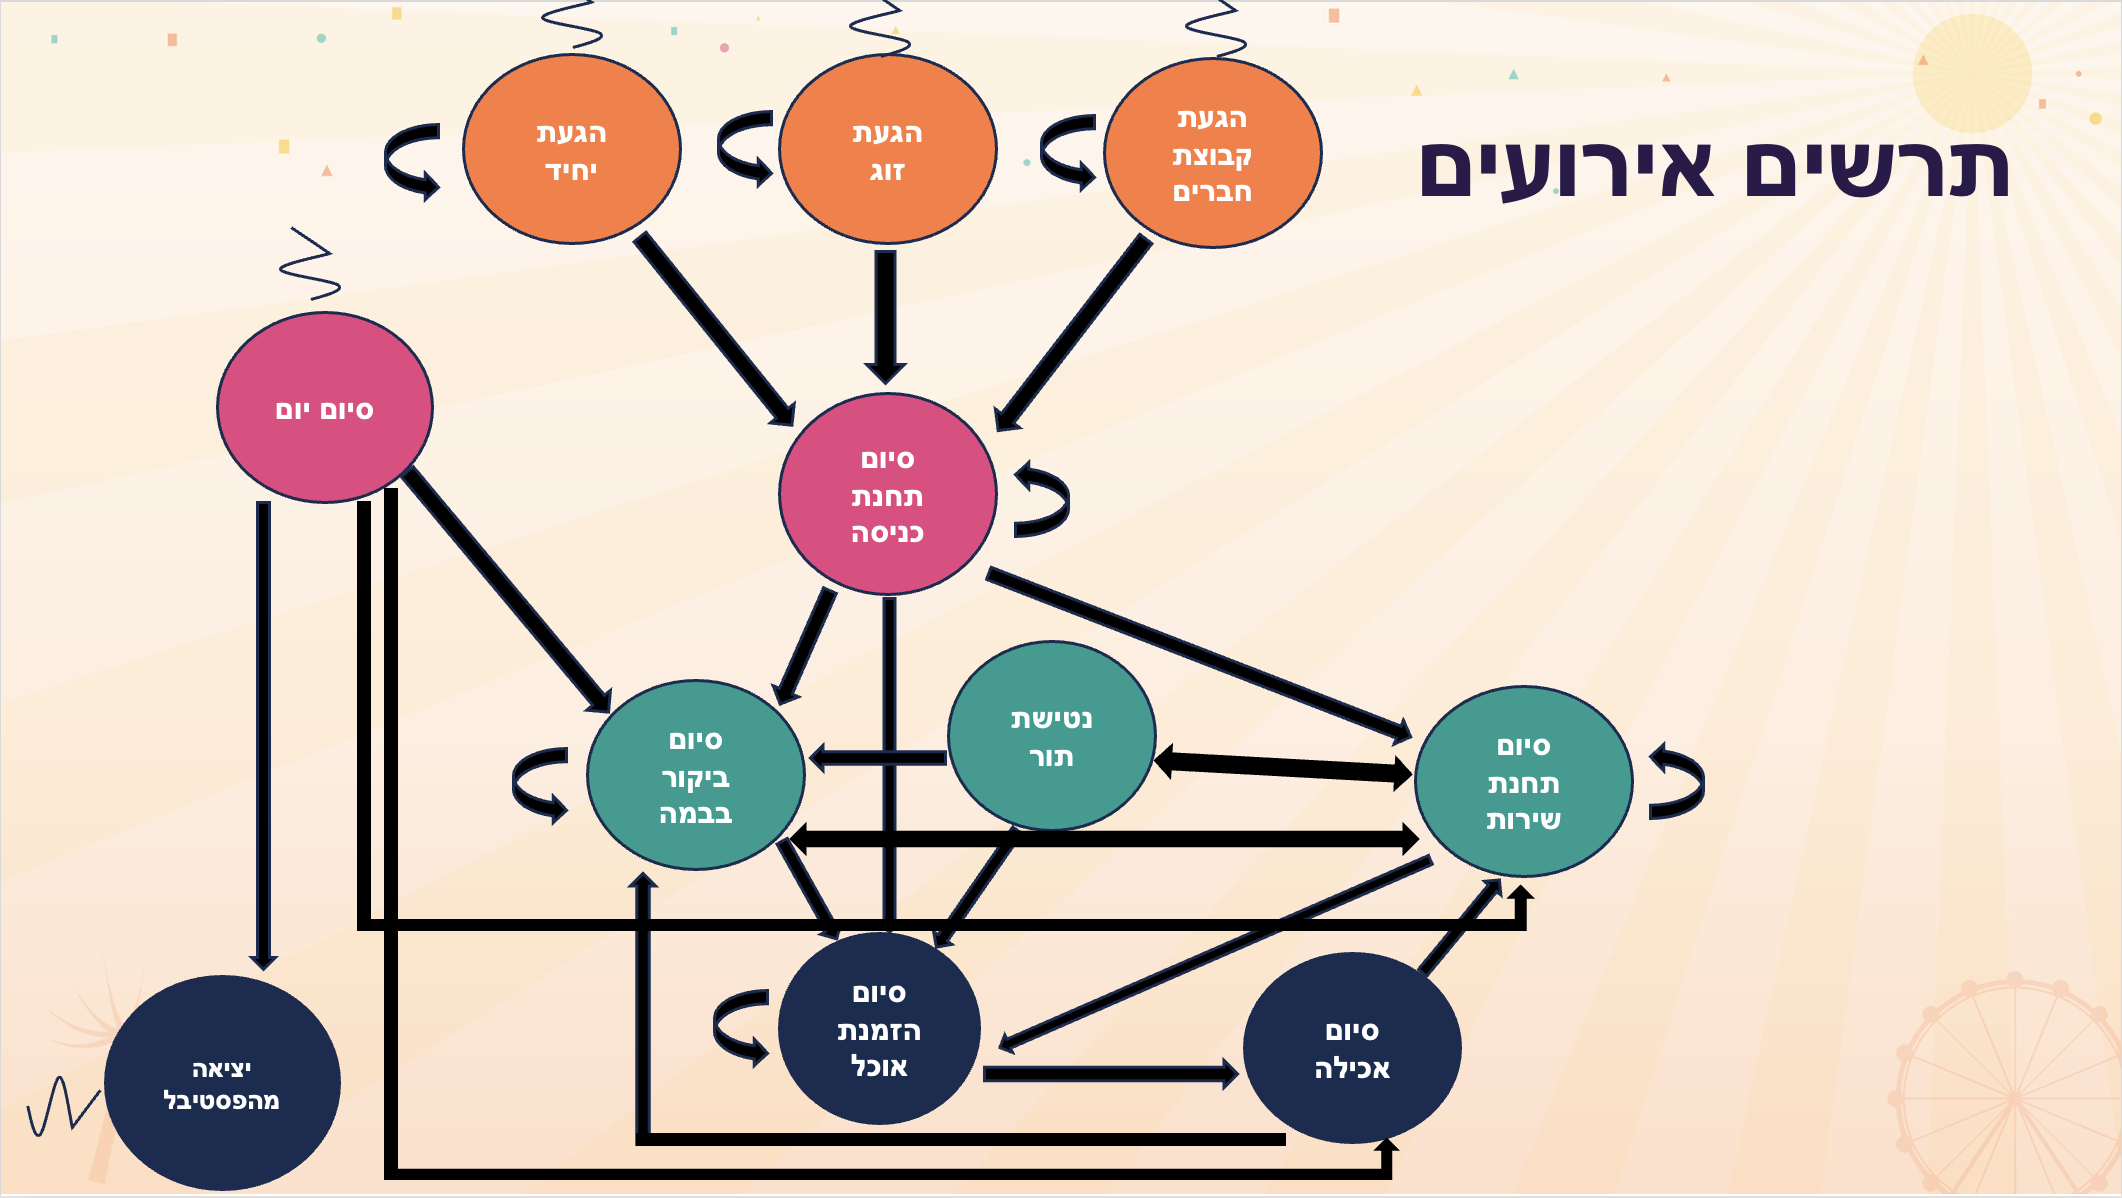

<div dir="rtl" style="text-align: right; color: blue;">

##תרשימים של 3 אירועים

<div dir="rtl" style="text-align: right; color: blue;">

# אירוע הגעה
באירוע הגעה נבדק תחילה האם זמן האירוע נמצא בתוך חלון ההגעה המותר עבור סוג הישות והיום הרלוונטי. אם התנאי מתקיים, נוצרת ישות מסוג קבוצת חברים, זוג או מבקר יחיד, ומאותחלים המאפיינים המתאימים לה, כגון גודל הקבוצה, תכנית הפעילויות ומדד שביעות הרצון ההתחלתי.
לאחר מכן הישות נשלחת לעמדת הכניסה. מאחר שהשירות בכניסה ניתן לכל אורח בנפרד, המערכת יוצרת משימת שירות נפרדת עבור כל אורח ומכניסה את כל המשימות לתור הכניסה המשותף. לבסוף נדגם זמן בין-מופעים חדש, ואם ההגעה הבאה עדיין נמצאת בתוך חלון ההגעה המותר, מתוזמן אירוע הגעה נוסף מאותו סוג.

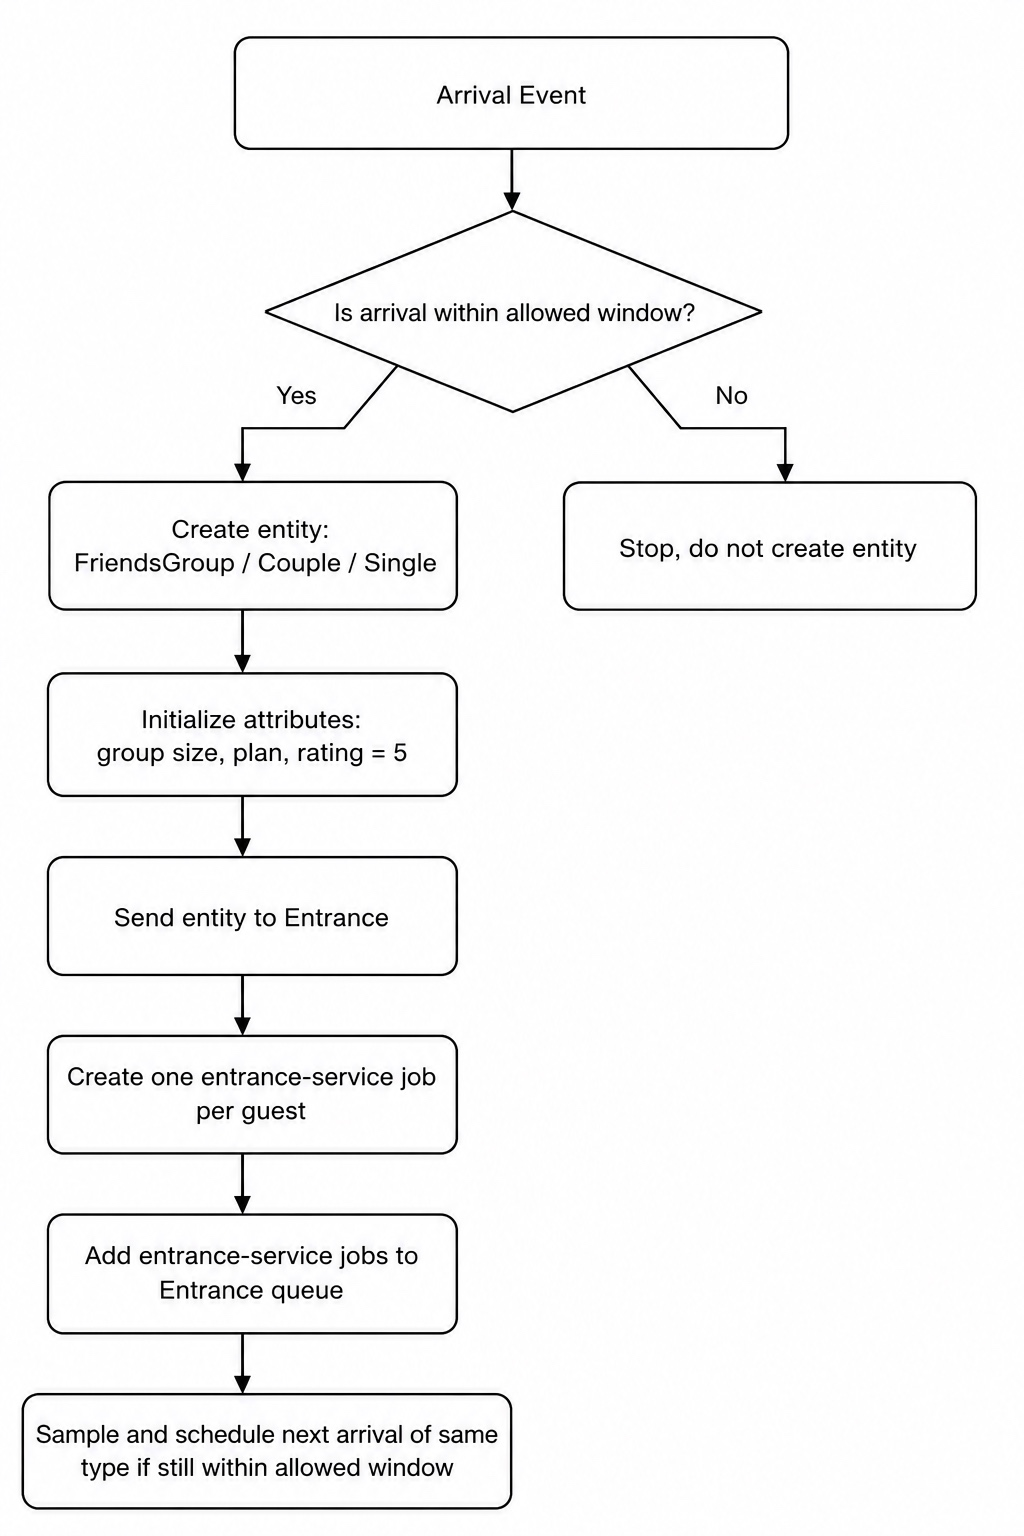

<div dir="rtl" style="text-align: right; color: blue;">

# אירוע סיום ביקור במה
באירוע סיום ביקור בבמה נבדק תחילה האם מדובר בבמת ה־DJ. עבור הבמה המרכזית והבמה המשנית, כל הישויות הנמצאות באזור הבמה מסיימות את ההופעה, מדד שביעות הרצון שלהן מתעדכן והן נשלחות לבחור את הפעילות הבאה. לאחר פינוי הבמה מחושב מועד תחילת ההופעה הבאה, ואם נותר מספיק זמן לפני סגירת הפסטיבל, מתוזמן אירוע תחילת הופעה חדש.
בבמת ה־DJ כל ישות מסיימת את הביקור באופן עצמאי בהתאם למשך השהייה שנדגם עבורה. אם האירוע עדיין תקף והישות נמצאת בבמה, היא מוסרת מרשימת השוהים, הביקור מסומן כהושלם, מתפנה מקום לישות הבאה בתור, והישות שסיימה נשלחת לבחור את הפעילות הבאה.

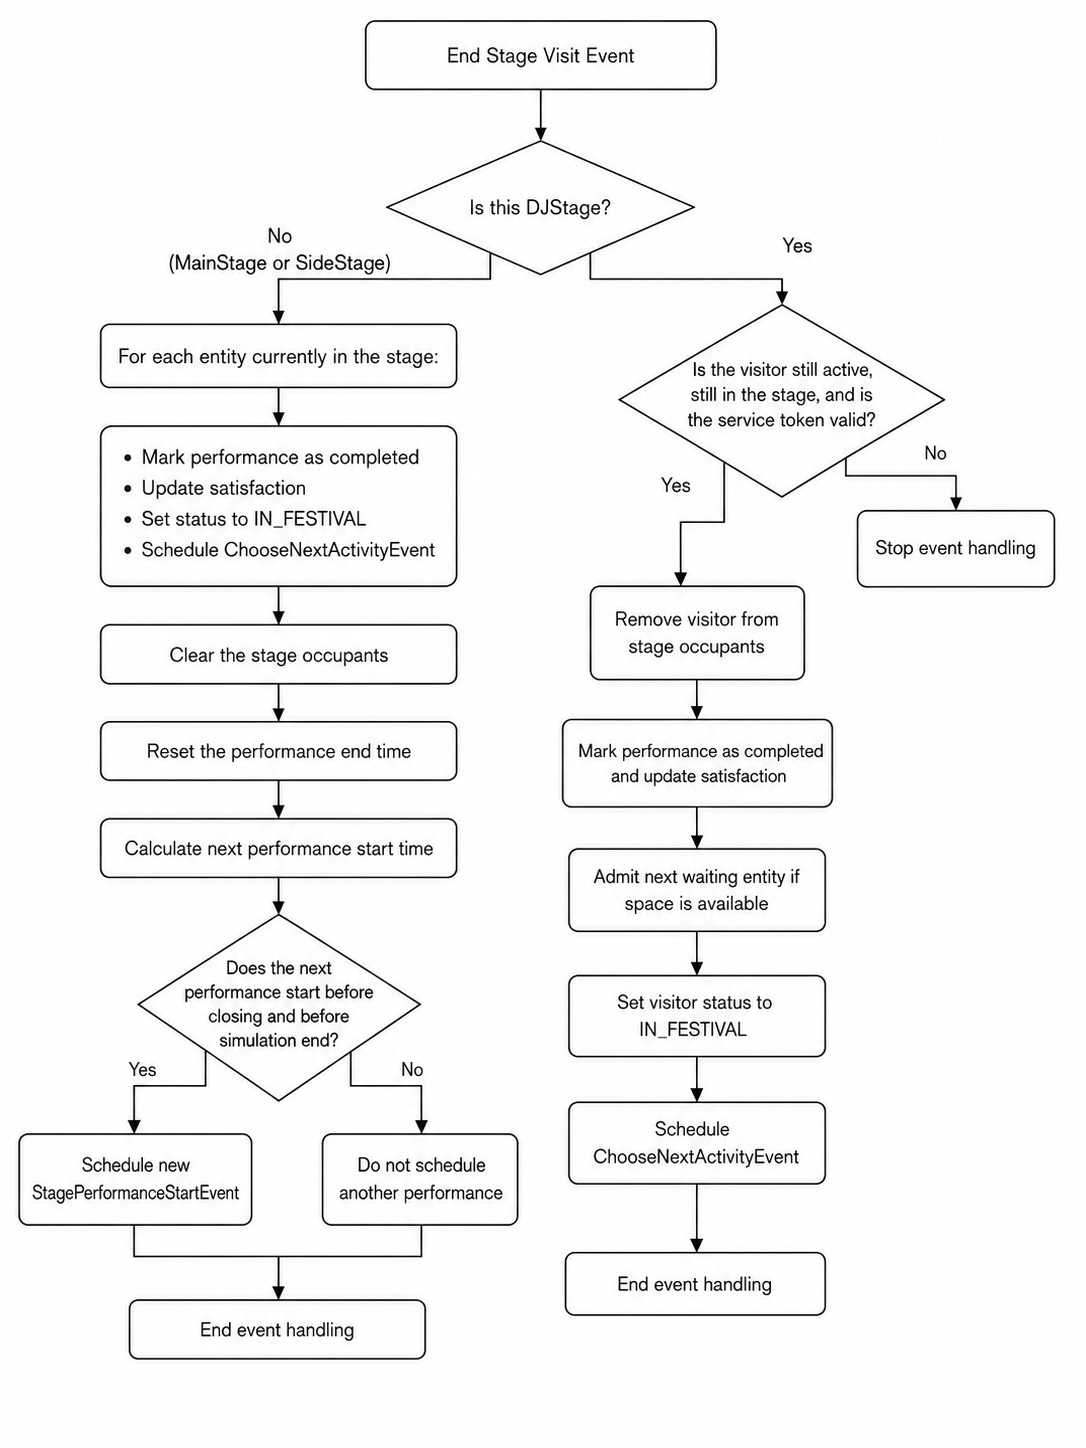

<div dir="rtl" style="text-align: right; color: blue;">

# אירוע עזיבת תור
באירוע עזיבת תור נבדק תחילה האם האירוע עדיין מתייחס לכניסה הנוכחית של הישות לתור, באמצעות התאמה בין התחנה וה־queue_token. אם האירוע אינו תקף, הוא נחשב לאירוע ישן ומסתיים ללא שינוי במערכת. לאחר מכן נבדק האם מדובר בשירות אישי שבו אחד מחברי הקבוצה כבר התחיל לקבל שירות; במקרה כזה לא מתאפשרת נטישה, כדי למנוע מצב שבו חלק מחברי הקבוצה קיבלו שירות וחלקם עזבו.
אם הישות עדיין ממתינה בתור, היא מוסרת ממנו, זמן ההמתנה והנטישה נרשמים, ומדד שביעות הרצון שלה מופחת בהתאם לסוג הישות. במקרה של תור לשירות אישי, עבודות השירות שנותרו עבור חברי הקבוצה מוסרות ומצב השירות האישי של הקבוצה מאופס. לבסוף, מצב הישות משתנה ל־IN_FESTIVAL ומתוזמן עבורה אירוע לבחירת הפעילות הבאה.

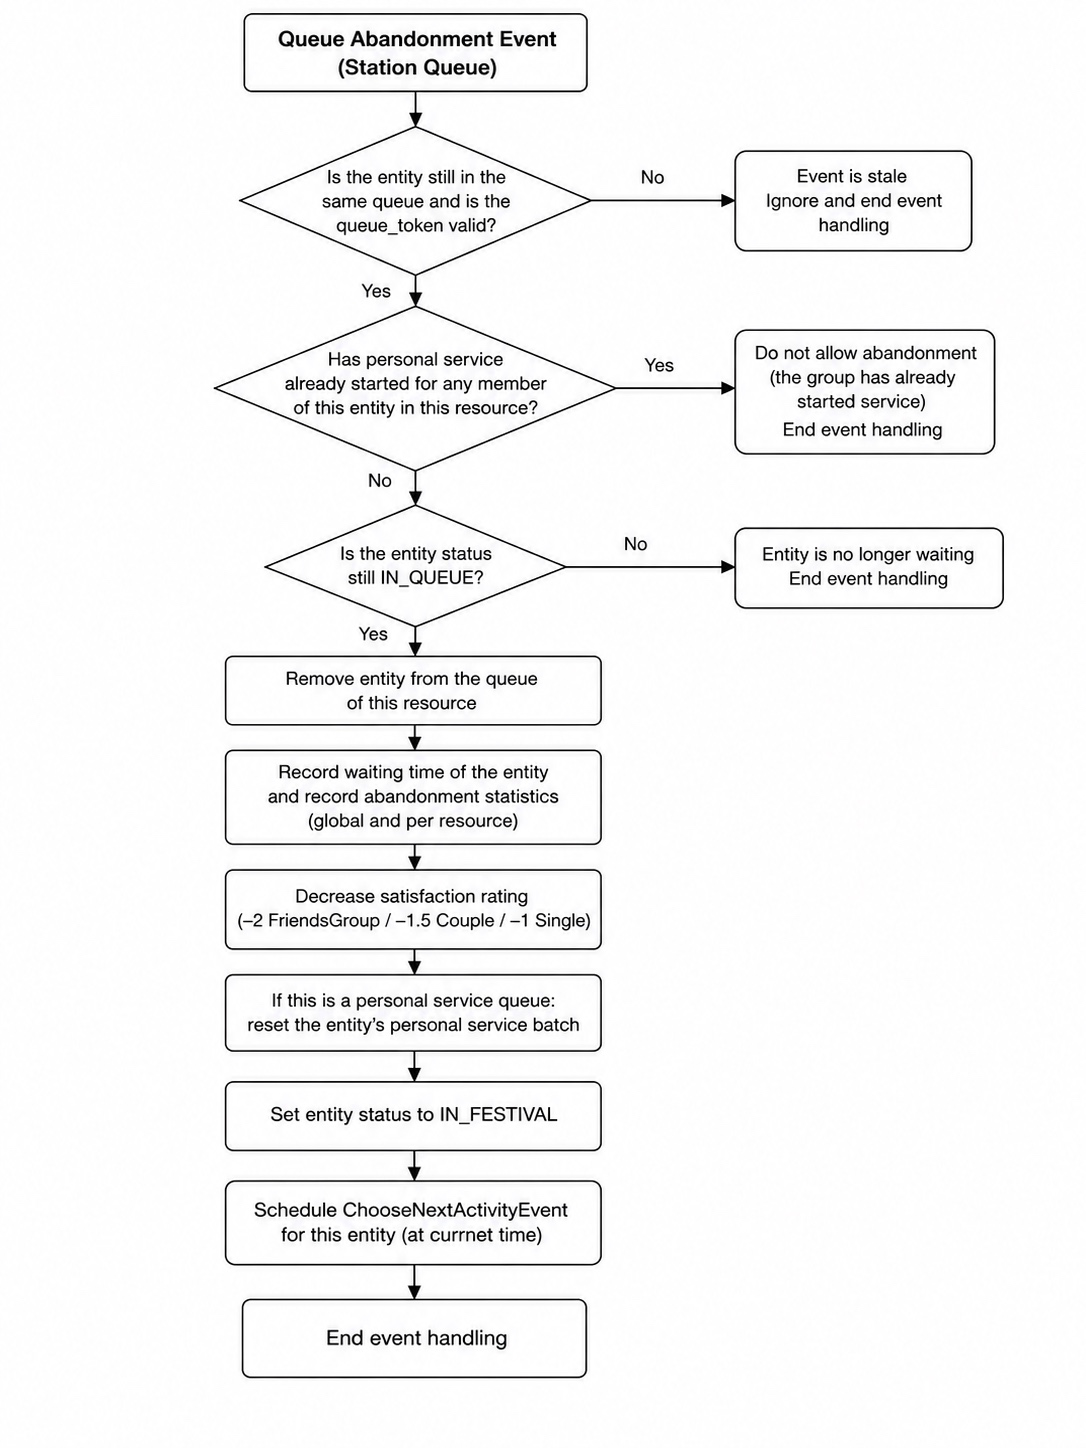

<div dir="rtl" style="text-align: right; color: blue;">

##קוד אירועים
תא זה מכיל את מחלקות האירועים של הסימולציה, המייצגות את כל השינויים הדינמיים שמתרחשים בפסטיבל לאורך ציר הזמן. כל אירוע מוגדר כאובייקט עם זמן ביצוע ופונקציית טיפול, האחראית לעדכון מצב הפסטיבל ולתזמון אירועים עתידיים. באמצעות מנגנון זה מתקדמת הסימולציה מאירוע לאירוע ולא בצעדים קבועים של זמן.

In [ ]:

# ----------------------------------------------------------- #
# -------------------------- EVENTS ------------------------- #
# ----------------------------------------------------------- #


class Event:
    _counter = 0

    # Initializes a scheduled simulation event.
    def __init__(self, time: float, visitor: Optional[FestivalEntity] = None, priority: int = 5) -> None:
        self.time = float(time)
        self.visitor = visitor
        self.priority = int(priority)
        self.sequence = Event._counter
        Event._counter += 1

    # Orders events by time, priority, and creation sequence.
    def __lt__(self, other: "Event") -> bool:
        return (self.time, self.priority, self.sequence) < (other.time, other.priority, other.sequence)

    # Handles the event when it is removed from the event list.
    def handle(self, festival: "Festival") -> None:
        raise NotImplementedError


class FriendsGroupArrivalEvent(Event):
    # Creates a friends group arrival event.
    def __init__(self, time: float) -> None:
        super().__init__(time, None, priority=1)

    # Processes a friends group arrival and schedules the next one.
    def handle(self, festival: "Festival") -> None:
        if not festival.arrival_time_allowed("FriendsGroup", 1, self.time):
            festival.invalid_arrival_window_events += 1
            return
        visitor = FriendsGroup(festival.new_id(), self.time)
        festival.process_arrival(visitor)
        next_time = festival.current_time + Sampler.sample_friends_group_arrival_interval()
        _, window_end = arrival_window_global(1, OPEN, ONE_PM)
        if next_time <= window_end and next_time <= festival.tmax:
            festival.schedule_event(FriendsGroupArrivalEvent(next_time))


class CoupleArrivalEvent(Event):
    # Creates a couple arrival event.
    def __init__(self, time: float, day: int) -> None:
        super().__init__(time, None, priority=1)
        self.day = int(day)

    # Processes a couple arrival and schedules the next one.
    def handle(self, festival: "Festival") -> None:
        if not festival.arrival_time_allowed("Couple", self.day, self.time):
            festival.invalid_arrival_window_events += 1
            return
        visitor = Couple(festival.new_id(), self.day, self.time)
        festival.process_arrival(visitor)
        next_time = festival.current_time + Sampler.sample_couple_arrival_interval()
        _, window_end = arrival_window_global(self.day, TEN_AM, FOUR_PM)
        if next_time <= window_end and next_time <= festival.tmax:
            festival.schedule_event(CoupleArrivalEvent(next_time, self.day))


class SingleArrivalEvent(Event):
    # Creates a single visitor arrival event.
    def __init__(self, time: float, day: int) -> None:
        super().__init__(time, None, priority=1)
        self.day = int(day)

    # Processes a single visitor arrival and schedules the next one.
    def handle(self, festival: "Festival") -> None:
        if not festival.arrival_time_allowed("Single", self.day, self.time):
            festival.invalid_arrival_window_events += 1
            return
        visitor = Single(festival.new_id(), self.day, self.time)
        festival.process_arrival(visitor)
        next_time = festival.current_time + Sampler.sample_single_arrival_interval()
        _, window_end = arrival_window_global(self.day, OPEN, FOUR_PM)
        if next_time <= window_end and next_time <= festival.tmax:
            festival.schedule_event(SingleArrivalEvent(next_time, self.day))


class GuestServiceCompleteEvent(Event):
    # Creates a guest-level personal service completion event.
    def __init__(
        self,
        time: float,
        job: GuestServiceJob,
        resource_name: str,
        server_id: Optional[int] = None,
        service_token: Optional[int] = None,
    ) -> None:
        super().__init__(time, job.parent, priority=5)
        self.job = job
        self.resource_name = resource_name
        self.server_id = server_id
        self.service_token = job.service_token if service_token is None else service_token

    # Completes a personal service job and updates the parent entity.
    def handle(self, festival: "Festival") -> None:
        if festival.completion_event_after_day_end(self.time):
            festival.service_completions_after_day_end_detected += 1
            return
        parent = self.job.parent
        if (
            parent.personal_service_token != self.service_token
            or not parent.personal_service_active
            or parent.personal_service_resource != self.resource_name
            or parent.status == "EXITED"
        ):
            festival.stale_completion_events_ignored += 1
            return
        station = festival.entrance if self.resource_name == "Entrance" else festival.stations[self.resource_name]
        if isinstance(station, BodyArtStation):
            if self.server_id is None:
                raise RuntimeError("BodyArt guest completion missing artist_id")
            station.finish_artist_service(festival, self.server_id)
        elif isinstance(station, PersonalStation):
            station.finish_service()
        else:
            raise RuntimeError(f"{self.resource_name} is not a personal station")
        festival.apply_personal_service_effect(self.job)
        festival.personal_service_jobs_completed_by_resource[self.resource_name] = (
            festival.personal_service_jobs_completed_by_resource.get(self.resource_name, 0) + 1
        )
        if parent.mark_personal_service_completed() and not parent.personal_service_incomplete_due_to_close:
            festival.finish_personal_service_batch(parent, self.resource_name)
        station.start_if_possible(festival)


class ChooseNextActivityEvent(Event):
    # Creates an event for choosing a visitor's next activity.
    def __init__(self, time: float, visitor: FestivalEntity) -> None:
        super().__init__(time, visitor, priority=6)

    # Chooses and schedules the visitor's next action.
    def handle(self, festival: "Festival") -> None:
        visitor = self.visitor
        if visitor is None or visitor.status == "EXITED":
            return
        if local_time(festival.current_time) >= CLOSE:
            return
        if festival.maybe_send_to_lunch(visitor):
            return
        next_activity = festival.choose_next_activity(visitor)
        if next_activity is None:
            festival.finalize_exit(visitor)
            return
        festival.schedule_event(JoinQueueEvent(festival.current_time, visitor, next_activity))


class JoinQueueEvent(Event):
    # Creates an event that sends a visitor to an activity queue.
    def __init__(self, time: float, visitor: FestivalEntity, activity: str) -> None:
        super().__init__(time, visitor, priority=4)
        self.activity = activity

    # Places the visitor in the selected queue.
    def handle(self, festival: "Festival") -> None:
        visitor = self.visitor
        if visitor is None or visitor.status == "EXITED":
            return
        visitor.status = "IN_QUEUE"
        visitor.current_activity = self.activity
        visitor.queue_join_time = festival.current_time
        visitor.queue_token += 1
        festival.join_activity_queue(visitor, self.activity)


class QueueAbandonmentEvent(Event):
    # Creates a queue abandonment event for a visitor.
    def __init__(self, time: float, visitor: FestivalEntity, resource_name: str, queue_token: int) -> None:
        super().__init__(time, visitor, priority=7)
        self.resource_name = resource_name
        self.queue_token = queue_token

    # Removes a visitor from a queue if the abandonment is still valid.
    def handle(self, festival: "Festival") -> None:
        visitor = self.visitor
        if visitor is None:
            return
        if visitor.current_activity != self.resource_name or visitor.queue_token != self.queue_token:
            festival.stale_abandonment_events_ignored += 1
            return
        if (
            visitor.personal_service_active
            and visitor.personal_service_resource == self.resource_name
            and visitor.personal_service_started > 0
        ):
            festival.personal_abandonment_ignored_started_batch += 1
            return
        if visitor.status != "IN_QUEUE":
            return
        personal_queue_abandonment = visitor.personal_service_active and self.resource_name in PERSONAL_RESOURCES
        removed = festival.remove_from_queue(visitor, self.resource_name)
        if not removed:
            festival.invalid_abandonment_events += 1
            return
        wait = festival.current_time - float(visitor.queue_join_time or festival.current_time)
        festival.record_wait(self.resource_name, wait)
        festival.abandonments += 1
        festival.abandonments_by_resource[self.resource_name] = festival.abandonments_by_resource.get(self.resource_name, 0) + 1
        if personal_queue_abandonment:
            festival.personal_abandonments_by_resource[self.resource_name] = (
                festival.personal_abandonments_by_resource.get(self.resource_name, 0) + 1
            )
        if visitor.entity_type == "FriendsGroup":
            visitor.update_rating(-2.0)
        elif visitor.entity_type == "Couple":
            visitor.update_rating(-1.5)
        else:
            visitor.update_rating(-1.0)
        if visitor.personal_service_active:
            visitor.reset_personal_service_batch()
        visitor.status = "IN_FESTIVAL"
        festival.schedule_event(ChooseNextActivityEvent(festival.current_time, visitor))


class StagePerformanceStartEvent(Event):
    # Creates a stage performance start event.
    def __init__(self, time: float, stage_name: str) -> None:
        super().__init__(time, None, priority=0)
        self.stage_name = stage_name

    # Starts a stage performance and admits waiting visitors.
    def handle(self, festival: "Festival") -> None:
        stage = festival.stages[self.stage_name]
        if festival.current_time >= day_end(festival.current_time) or local_time(festival.current_time) >= CLOSE:
            return
        duration = Sampler.sample_main_stage_duration() if stage.name == MAIN_STAGE else Sampler.sample_side_stage_duration()
        end_time = festival.current_time + duration
        if end_time > day_end(festival.current_time) or end_time > festival.tmax:
            return
        stage.performance_end_time = end_time
        festival.stage_capacity_minutes[stage.name] += (end_time - festival.current_time) * stage.capacity
        festival.schedule_event(StagePerformanceEndEvent(end_time, stage.name))
        stage.admit_waiting(festival)


class StagePerformanceEndEvent(Event):
    # Creates a stage performance end event.
    def __init__(self, time: float, stage_name: str) -> None:
        super().__init__(time, None, priority=0)
        self.stage_name = stage_name

    # Ends a stage performance and releases the audience.
    def handle(self, festival: "Festival") -> None:
        stage = festival.stages[self.stage_name]
        for visitor in list(stage.occupants):
            if visitor.status != "EXITED":
                festival.complete_performance(visitor, stage.name)
                visitor.status = "IN_FESTIVAL"
                festival.schedule_event(ChooseNextActivityEvent(festival.current_time, visitor))
        stage.occupants.clear()
        stage.performance_end_time = None
        next_start = festival.current_time + stage.break_time
        if next_start < festival.tmax and next_start < day_end(festival.current_time) and local_time(next_start) < CLOSE:
            festival.schedule_event(StagePerformanceStartEvent(next_start, stage.name))


class StageEarlyLeaveEvent(Event):
    # Creates an event for a visitor leaving a stage early.
    def __init__(self, time: float, visitor: FestivalEntity, stage_name: str) -> None:
        super().__init__(time, visitor, priority=3)
        self.stage_name = stage_name

    # Removes the visitor from the stage before the performance ends.
    def handle(self, festival: "Festival") -> None:
        visitor = self.visitor
        stage = festival.stages[self.stage_name]
        if visitor is not None and stage.remove_occupant(visitor):
            visitor.status = "IN_FESTIVAL"
            stage.admit_waiting(festival)
            festival.schedule_event(ChooseNextActivityEvent(festival.current_time, visitor))


class ActivityCompleteEvent(Event):
    # Creates an activity completion event for a visitor.
    def __init__(self, time: float, visitor: FestivalEntity, activity: str, service_token: Optional[int] = None) -> None:
        super().__init__(time, visitor, priority=5)
        self.activity = activity
        self.service_token = visitor.service_token if service_token is None else service_token

    # Completes an activity if the scheduled token is still valid.
    def handle(self, festival: "Festival") -> None:
        visitor = self.visitor
        if visitor is None or visitor.status == "EXITED":
            return
        if festival.completion_event_after_day_end(self.time):
            festival.service_completions_after_day_end_detected += 1
            return
        if visitor.service_token != self.service_token:
            festival.stale_completion_events_ignored += 1
            return
        if self.activity in festival.stages:
            stage = festival.stages[self.activity]
            if not stage.remove_occupant(visitor):
                return
            festival.complete_performance(visitor, self.activity)
            if self.activity == DJ_STAGE:
                stage.admit_waiting(festival)
        visitor.status = "IN_FESTIVAL"
        festival.schedule_event(ChooseNextActivityEvent(festival.current_time, visitor))


class StationServiceCompleteEvent(Event):
    # Creates a station service completion event.
    def __init__(
        self,
        time: float,
        visitor: FestivalEntity,
        station_name: str,
        artist_id: Optional[int] = None,
        service_token: Optional[int] = None,
    ) -> None:
        super().__init__(time, visitor, priority=5)
        self.station_name = station_name
        self.artist_id = artist_id
        self.service_token = visitor.service_token if service_token is None else service_token

    # Completes a station service and starts the next waiting service.
    def handle(self, festival: "Festival") -> None:
        if festival.completion_event_after_day_end(self.time):
            festival.service_completions_after_day_end_detected += 1
            return
        visitor = self.visitor
        if visitor is not None and visitor.service_token != self.service_token:
            festival.stale_completion_events_ignored += 1
            return
        if self.station_name in PERSONAL_RESOURCES:
            raise RuntimeError(f"{self.station_name} must complete through GuestServiceCompleteEvent")
        station = festival.stations[self.station_name]
        station.finish_service()
        if visitor is not None and visitor.status != "EXITED":
            festival.complete_station(visitor, self.station_name)
            visitor.status = "IN_FESTIVAL"
            festival.schedule_event(ChooseNextActivityEvent(festival.current_time, visitor))
        station.start_if_possible(festival)


class ArtistBreakEndEvent(Event):
    # Creates an event for the end of a body art artist break.
    def __init__(self, time: float, artist_id: int) -> None:
        super().__init__(time, None, priority=3)
        self.artist_id = artist_id

    # Makes the artist available again after a break.
    def handle(self, festival: "Festival") -> None:
        station = festival.stations[BODY_ART]
        if not isinstance(station, BodyArtStation):
            return
        station.finish_break(self.artist_id, festival.current_time)
        station.start_if_possible(festival)


class FoodOrderCompleteEvent(Event):
    # Creates a food order completion event.
    def __init__(self, time: float, visitor: FestivalEntity, restaurant_name: str, service_token: Optional[int] = None) -> None:
        super().__init__(time, visitor, priority=5)
        self.restaurant_name = restaurant_name
        self.service_token = visitor.service_token if service_token is None else service_token

    # Completes a food order and schedules meal time.
    def handle(self, festival: "Festival") -> None:
        if festival.completion_event_after_day_end(self.time):
            festival.service_completions_after_day_end_detected += 1
            return
        visitor = self.visitor
        if visitor is not None and visitor.service_token != self.service_token:
            festival.stale_completion_events_ignored += 1
            return
        restaurant = festival.restaurants[self.restaurant_name]
        restaurant.finish_service()
        if visitor is not None and visitor.status != "EXITED":
            revenue = festival.food_price(visitor, self.restaurant_name)
            festival.total_income += revenue
            festival.food_income += revenue
            festival.food_income_by_restaurant[self.restaurant_name] = (
                festival.food_income_by_restaurant.get(self.restaurant_name, 0.0) + revenue
            )
            festival.total_people_ate += visitor.group_size
            visitor.has_eaten = True
            if random.random() <= SCN_BAD_DISH_PROB:
                visitor.update_rating(-0.6)
            meal_duration = visitor.pending_meal_duration
            if meal_duration is None:
                meal_duration = Sampler.sample_meal_duration()
            visitor.pending_food_order_duration = None
            visitor.pending_meal_duration = None
            visitor.pending_restaurant_name = None
            token = visitor.next_service_token()
            festival.schedule_event(MealCompleteEvent(festival.current_time + meal_duration, visitor, token))
        restaurant.start_if_possible(festival)


class MealCompleteEvent(Event):
    # Creates a meal completion event.
    def __init__(self, time: float, visitor: FestivalEntity, service_token: Optional[int] = None) -> None:
        super().__init__(time, visitor, priority=5)
        self.service_token = visitor.service_token if service_token is None else service_token

    # Returns a visitor to the festival after eating.
    def handle(self, festival: "Festival") -> None:
        if festival.completion_event_after_day_end(self.time):
            festival.service_completions_after_day_end_detected += 1
            return
        visitor = self.visitor
        if visitor is not None and visitor.service_token != self.service_token:
            festival.stale_completion_events_ignored += 1
            return
        if visitor is not None and visitor.status != "EXITED":
            visitor.status = "IN_FESTIVAL"
            festival.schedule_event(ChooseNextActivityEvent(festival.current_time, visitor))


class EndOfDayEvent(Event):
    # Creates an end-of-day event.
    def __init__(self, time: float, day: int) -> None:
        super().__init__(time, None, priority=8)
        self.day = day

    # Ends the current day and starts day two when needed.
    def handle(self, festival: "Festival") -> None:
        festival.end_day(self.day)
        if self.day == 1:
            festival.start_day(DAY_2_START)


class FestivalCloseEvent(Event):
    # Creates a festival closing event.
    def __init__(self, time: float) -> None:
        super().__init__(time, None, priority=9)

    # Finalizes remaining visitors and clears system state at closing.
    def handle(self, festival: "Festival") -> None:
        for visitor in list(festival.entities):
            if not visitor.completed:
                festival.finalize_exit(visitor)
        festival.clean_all_queues_and_occupants()

<div dir="rtl" style="text-align: right; color: blue;">

#המחלקה פסטיבל והרצה




<div dir="rtl" style="text-align: right;">

במודל הסימולציה הונחו ההנחות הבאות לצורך פישוט המערכת וייצוג יעיל של פעילות הפסטיבל:

* זמן המעבר בין הבמות, התחנות ומתחם המזון נחשב זניח.
* הפסטיבל פועל במשך יומיים, בכל יום בין השעות 09:00 ל-20:00.
* שעות הלילה אינן נכללות בזמן הפעיל של הסימולציה.
* מבקרים הנשארים ללון אינם עוברים שוב את תהליך הכניסה ביום השני.
* קבוצות חברים וזוגות נשארים כישות אחת ואינם מתפצלים במהלך הביקור.
* בשירותים הניתנים לכל אדם בנפרד, כגון הכניסה, עמדת הטעינה, המרצ'נדייז וציורי הגוף, נוצרת משימת שירות נפרדת לכל חבר בקבוצה.
* הקבוצה ממשיכה לפעילות הבאה רק לאחר שכל חבריה סיימו את השירות האישי.
* סדר השירות בתורים הוא לפי זמן ההצטרפות לתור, ללא קדימות בין סוגי המבקרים.
* בבמות, קבוצה נכנסת רק אם קיימת קיבולת מספקת לכל חבריה, ואינה מתפצלת לצורך מילוי מקומות פנויים.
* כאשר הקבוצה הראשונה בתור אינה מתאימה לקיבולת שנותרה, ניתן להכניס קבוצה אחרת שמתאימה למספר המקומות הפנויים.
* נטישה מתרחשת רק בתורי התחנות, ולא בתורי הבמות, המזון או הכניסה.
* קבוצת חברים נוטשת תור לאחר 15 דקות, וזוגות ומבקרים יחידים לאחר 20 דקות.
* קבוצה אינה יכולה לנטוש שירות אישי לאחר שאחד מחבריה כבר התחיל לקבל שירות.
* לאחר נטישה מהתור, דירוג שביעות הרצון של המבקרים בקבוצה יורד.
* הופעה או שירות מתחילים רק אם ניתן לסיימם לפני שעת הסגירה של אותו יום.
* פעילות שלא ניתן להתחיל לפני הסגירה אינה נבחרת שוב על ידי אותה ישות במהלך אותו יום.
* ניתן להיכנס לבמה המרכזית ולבמה המשנית לאחר תחילת ההופעה, כל עוד קיימת קיבולת פנויה.
* ישות שנשארת בבמה עד סיום ההופעה נחשבת כמי שהשלימה אותה, גם אם נכנסה לאחר תחילתה.
* ישות שעוזבת את הבמה המרכזית מוקדם אינה נחשבת כמי שהשלימה את ההופעה.
* ההחלטה אם לאכול מתקבלת פעם אחת בלבד במהלך הביקור, בין השעות 13:00 ל-15:00.
* בכל מסעדה קיים שרת אחד, הנשאר תפוס בזמן קבלת ההזמנה והכנת המזון בלבד.
* זמן האכילה אינו תופס משאב, ולא קיימת מגבלת קיבולת באזור הישיבה.
* ערכים שליליים או בלתי אפשריים הנדגמים מהתפלגות נורמלית נדחים עד לקבלת ערך חוקי.
* בסיום כל יום מתאפסים התורים, מצב השרתים ותפוסת הבמות.
* קבוצות חברים נשארות ללון לפי הסתברות שנדגמת בעת הגעתן.
* זוג שהגיע ביום הראשון נשאר ללון רק אם דירוגו בסוף היום גבוה מ-7.
* מבקרים יחידים מגיעים ליום אחד בלבד ואינם נשארים ללון.
* דירוג שביעות הרצון נשמר בנפרד לכל אורח ומוגבל לערכים שבין 0 ל-10.

---

## מידול הפסטיבל

הקוד מגדיר מחלקה מרכזית בשם **Festival**, המייצגת את מערכת פסטיבל Queuechella כולה. מחלקה זו מרכזת את כלל רכיבי הסימולציה: במות ההופעות, תחנות השירות, מתחם המזון, עמדת הכניסה ושלושת סוגי המבקרים - קבוצות חברים, זוגות ומבקרים יחידים.

בעת יצירת אובייקט פסטיבל מאותחלים יומן אירועים המבוסס על תור עדיפויות, הבמות עם הקיבולות המתאימות, תחנות השירות, המסעדות ומנגנונים לאיסוף הכנסות, זמני המתנה, נטישות ודירוגי שביעות רצון. בנוסף, קיימת מערכת לתזמון אירועים עתידיים, כך שכל אירוע מתבצע בזמן שנקבע לו מראש.

הרצת הסימולציה מתבצעת באמצעות לולאת אירועים. בתחילת ההרצה מתוזמנים אירועי ההגעה הראשונים ותחילת ההופעות. לאחר מכן המערכת שולפת בכל פעם את האירוע המוקדם ביותר, מעדכנת את שעון הסימולציה ומבצעת את השינויים המתאימים במצב המערכת. אירוע עשוי ליצור אירועים עתידיים נוספים, כגון סיום שירות, סיום הופעה, נטישה או בחירת הפעילות הבאה.

הקוד משתמש במחלקה **FestivalEntity** כמחלקת בסיס לכל סוגי המבקרים. מחלקה זו שומרת את גודל הקבוצה, זמן ההגעה, יום ההגעה, מצב הישות, הפעילויות שבוצעו, דירוגי שביעות הרצון וההכנסות ששולמו.

מחלקות **FriendsGroup**, **Couple** ו-**Single** יורשות ממנה ומיישמות את דפוסי הפעילות המתאימים לכל סוג מבקר. קבוצות חברים מבקרות בכל סוגי ההופעות ובכל התחנות, זוגות עוברים לסירוגין בין הופעה לתחנה, ומבקרים יחידים מתחילים במרצ'נדייז ולאחר מכן מבקרים במספר מוגדר של הופעות מכל סוג.

השירותים בכניסה, במרצ'נדייז, בעמדת הטעינה ובציורי הגוף ממודלים ברמת האדם הבודד. לעומת זאת, הבמות, עמדת הצילום והמסעדות מטופלות ברמת הישות הקבוצתית.

בסיום היום הראשון מתקבלת החלטה אילו מבקרים נשארים ליום השני. המבקרים הנשארים ממשיכים עם דירוג שביעות הרצון והפעילויות שכבר השלימו, אך אינם עוברים פעם נוספת בעמדת הכניסה.

---

## בחירת המדדים

בסימולציה נבחרו שלושה מדדי הצלחה המשקפים הן את חוויית המבקר והן את ביצועי הפסטיבל מבחינה כלכלית:

### סך ההכנסות מכרטיסי כניסה ולינה

הכנסות הכניסה והלינה מהוות את מקור ההכנסה המרכזי של הפסטיבל. המדד כולל את ההכנסות ממכירת הכרטיסים ואת התשלום הנוסף של קבוצות חברים וזוגות הנשארים ללון.

מבחינה עסקית, מדד זה משקף הן את יכולת הפסטיבל למשוך מבקרים והן את יכולתו לעודד אותם להישאר ליום פעילות נוסף.

מדד זה נבחר כדי לבחון כיצד החלופות משפיעות על מספר המבקרים ועל כמות המבקרים הנשארים ללינה.

שיפור במדד זה מצביע על גידול בהיקף הפעילות ועל יכולת טובה יותר להפיק הכנסה מביקור ממושך בפסטיבל.

### הכנסות מאוהל המרצ'נדייז

הכנסות המרצ'נדייז מחושבות לפי הרכישות שמבצע כל אורח באוהל המרצ'נדייז. כל אורח יכול לרכוש מספר מוצרים בהתאם להסתברויות המוגדרות בקוד.

מבחינה עסקית, המרצ'נדייז מהווה מקור הכנסה נוסף מעבר להכנסות הכניסה והלינה, ומשקף את רמת העניין של המבקרים במותג הפסטיבל ובאמנים המשתתפים בו.

מדד זה נבחר מכיוון שהוא מושפע הן ממספר המבקרים והן מפופולריות ההופעות והמוצרים המוצעים.

שיפור במדד זה מצביע על הצלחה מסחרית גבוהה יותר ועל יכולת טובה יותר להפוך את נוכחות הקהל להכנסה נוספת.

### דירוג שביעות רצון ממוצע

הדירוג הממוצע משקף את החוויה הכוללת של המבקרים בפסטיבל, תוך התייחסות לזמני המתנה, נטישות, איכות המזון, ההופעות והשירותים השונים.

הדירוג נשמר בנפרד לכל אורח, והמדד מחושב כממוצע הדירוגים של כלל המבקרים שיצאו מהפסטיבל.

מבחינה עסקית, דירוג גבוה תורם למוניטין הפסטיבל, להמלצות חיוביות ולהגדלת הסיכוי של מבקרים לחזור בעתיד. בנוסף, דירוג הזוגות משפיע על החלטתם להישאר ללון.

מדד זה נבחר כדי לוודא ששיפור בהכנסות אינו מתקבל על חשבון חוויית המבקר.

שיפור במדד זה מעיד על איזון מוצלח יותר בין עומסים, איכות השירות והחוויה הכוללת בפסטיבל.

## סיכום בחירת המדדים

הכנסות הפסטיבל מורכבות מחמישה מקורות מרכזיים: מכירת כרטיסי כניסה, תשלומי לינה, הכנסות ממזון, הכנסות ממרצ'נדייז והכנסות מתמונות.

שלושת המדדים שנבחרו בסימולציה הם סך ההכנסות מכרטיסים ולינה, הכנסות המרצ'נדייז ודירוג שביעות הרצון הממוצע. ההכנסות מכרטיסים ולינה מייצגות את היקף הביקוש ואת משך השהייה בפסטיבל, הכנסות המרצ'נדייז מייצגות את היכולת להפיק הכנסה נוספת מהמבקרים, והדירוג הממוצע מייצג את איכות החוויה.

בחירה זו נועדה לאפשר ניתוח של החלופות מנקודת מבט כלכלית ושירותית, ולבחור חלופה המגדילה את הכנסות הפסטיבל תוך שמירה על שביעות רצון גבוהה של המבקרים.

</div>


<div dir="rtl" style="text-align: right; color: blue;">

##קוד מחלקת פסטיבל

In [ ]:
# ----------------------------------------------------------- #
# --------------------- SIMULATION ENGINE ------------------- #
# ----------------------------------------------------------- #


class Festival:
    # Initializes all resources, entities, counters, and metrics.
    def __init__(self) -> None:
        self.current_time = OPEN
        self.tmax = SIM_END
        self.log: list[Event] = []
        self.entities: list[FestivalEntity] = []
        self.next_entity_id = 1

        self.entrance = PersonalStation("Entrance", 5)
        self.stations = {
            MERCH: PersonalStation(MERCH, 7),
            PHOTO: Station(PHOTO, SCN_PHOTO_STATIONS),
            CHARGING: PersonalStation(CHARGING, 150),
            BODY_ART: BodyArtStation(BODY_ART, SCN_BODY_ART_ARTISTS),
        }
        self.restaurants = {name: Restaurant(name) for name in RESTAURANTS}
        self.stages = {
            MAIN_STAGE: Stage(MAIN_STAGE, int(200 * SCN_STAGE_CAPACITY_MULTIPLIER), 10.0),
            SIDE_STAGE: Stage(SIDE_STAGE, int(100 * SCN_STAGE_CAPACITY_MULTIPLIER), 5.0),
            DJ_STAGE: Stage(DJ_STAGE, int(70 * SCN_STAGE_CAPACITY_MULTIPLIER), 0.0, continuous=True),
        }

        self.customers_arriving = 0
        self.customers_leaving = 0
        self.arrivals_by_type: dict[str, int] = {}
        self.invalid_arrival_window_events = 0
        self.total_rating = 0.0
        self.total_income = 0.0
        # Per-source revenue decomposition (sums to total_income):
        self.ticket_income = 0.0          # base entry tickets
        self.sleep_income = 0.0           # overnight premiums (friends + couples)
        self.food_income = 0.0
        self.food_income_by_restaurant: dict[str, float] = {name: 0.0 for name in RESTAURANTS}
        self.merch_income = 0.0
        self.photo_income = 0.0
        self.total_people_ate = 0
        self.abandonments = 0
        self.abandonments_by_resource: dict[str, int] = {}
        self.personal_abandonments_by_resource: dict[str, int] = {}
        self.personal_abandonment_ignored_started_batch = 0
        self.stale_abandonment_events_ignored = 0
        self.invalid_abandonment_events = 0
        self.stale_queue_entities_discarded = 0
        self.stale_completion_events_ignored = 0
        self.service_completions_after_day_end_detected = 0
        self.blocked_service_starts_end_of_day = 0
        self.blocked_service_starts_by_resource: dict[str, int] = {}
        self.personal_service_jobs_started_by_resource: dict[str, int] = {}
        self.personal_service_jobs_completed_by_resource: dict[str, int] = {}
        self.personal_service_batches_completed_by_resource: dict[str, int] = {}
        self.incomplete_personal_batches_near_close_by_resource: dict[str, int] = {}
        self.end_of_day_queue_removals = 0
        self.waiting_times: list[float] = []
        self.waiting_times_by_resource: dict[str, list[float]] = {}
        self.activity_counts: dict[str, int] = {}
        self.stage_person_minutes = {MAIN_STAGE: 0.0, SIDE_STAGE: 0.0, DJ_STAGE: 0.0}
        self.stage_capacity_minutes = {MAIN_STAGE: 0.0, SIDE_STAGE: 0.0, DJ_STAGE: 0.0}
        self.stage_max_occupancy = {MAIN_STAGE: 0, SIDE_STAGE: 0, DJ_STAGE: 0}
        self.body_art_breaks_taken = 0
        self.body_art_break_windows: list[tuple[int, float, float]] = []

    # Adds an event to the future event list.
    def schedule_event(self, event: Event) -> None:
        if event.time <= self.tmax:
            heapq.heappush(self.log, event)

    # Runs the simulation event loop.
    def run(self, seed: Optional[int] = None) -> None:
        if seed is not None:
            random.seed(seed)
        Event._counter = 0
        self.initialize()
        while self.log and self.current_time <= self.tmax:
            event = heapq.heappop(self.log)
            self.current_time = event.time
            event.handle(self)

    # Schedules the initial events for a replication.
    def initialize(self) -> None:
        self.start_day(OPEN)
        self.schedule_event(EndOfDayEvent(DAY_2_START, 1))
        self.schedule_event(FestivalCloseEvent(SIM_END))
        self.schedule_initial_arrivals()

    # Starts stage activity for a festival day.
    def start_day(self, start_time: float) -> None:
        self.schedule_event(StagePerformanceStartEvent(start_time, MAIN_STAGE))
        self.schedule_event(StagePerformanceStartEvent(start_time, SIDE_STAGE))
        self.stages[DJ_STAGE].occupants.clear()
        self.stages[DJ_STAGE].performance_end_time = min(start_time + CLOSE, self.tmax)
        self.stage_capacity_minutes[DJ_STAGE] += (min(start_time + CLOSE, self.tmax) - start_time) * self.stages[DJ_STAGE].capacity

    # Returns the next unique entity identifier.
    def new_id(self) -> int:
        entity_id = self.next_entity_id
        self.next_entity_id += 1
        return entity_id

    # Schedules the first arrivals for each visitor type.
    def schedule_initial_arrivals(self) -> None:
        first_time = day_local_to_global(1, OPEN) + Sampler.sample_friends_group_arrival_interval()
        _, window_end = arrival_window_global(1, OPEN, ONE_PM)
        if first_time <= window_end:
            self.schedule_event(FriendsGroupArrivalEvent(first_time))

        for day in (1, 2):
            start, end = arrival_window_global(day, TEN_AM, FOUR_PM)
            first_time = start + Sampler.sample_couple_arrival_interval()
            if first_time <= end:
                self.schedule_event(CoupleArrivalEvent(first_time, day))

            start, end = arrival_window_global(day, OPEN, FOUR_PM)
            first_time = start + Sampler.sample_single_arrival_interval()
            if first_time <= end:
                self.schedule_event(SingleArrivalEvent(first_time, day))

    # Records a visitor arrival and sends it to entrance.
    def process_arrival(self, visitor: FestivalEntity) -> None:
        visitor.status = "ARRIVED"
        self.customers_arriving += visitor.group_size
        self.arrivals_by_type[visitor.entity_type] = self.arrivals_by_type.get(visitor.entity_type, 0) + 1
        self.entities.append(visitor)
        self.join_entrance(visitor)

    # Checks whether an arrival is inside its allowed time window.
    def arrival_time_allowed(self, entity_type: str, day: int, t_now: float) -> bool:
        if entity_type == "FriendsGroup":
            if int(day) != 1 or day_number(t_now) != 1:
                return False
            start, end = arrival_window_global(1, OPEN, ONE_PM)
        elif entity_type == "Couple":
            if int(day) not in (1, 2) or day_number(t_now) != int(day):
                return False
            start, end = arrival_window_global(day, TEN_AM, FOUR_PM)
        elif entity_type == "Single":
            if int(day) not in (1, 2) or day_number(t_now) != int(day):
                return False
            start, end = arrival_window_global(day, OPEN, FOUR_PM)
        else:
            return False
        return start <= float(t_now) <= end

    # Records a waiting time observation.
    def record_wait(self, resource_name: str, wait: float) -> None:
        wait = max(0.0, float(wait))
        self.waiting_times.append(wait)
        self.waiting_times_by_resource.setdefault(resource_name, []).append(wait)

    # Returns the remaining time before the current day closes.
    def time_left_today(self) -> float:
        return max(0.0, day_end(self.current_time) - self.current_time)

    # Checks whether a duration can finish before day end.
    def can_finish_today(self, duration: float) -> bool:
        return self.current_time + float(duration) <= day_end(self.current_time)

    # Checks whether a duration can finish before a deadline.
    def can_finish_by(self, duration: float, finish_deadline: float) -> bool:
        return self.current_time + float(duration) <= float(finish_deadline)

    # Detects completions scheduled after the day has ended.
    def completion_event_after_day_end(self, event_time: float) -> bool:
        return float(event_time) > day_end(float(event_time) - EPSILON)

    # Records a service start blocked by end-of-day timing.
    def record_blocked_service_start(self, resource_name: str) -> None:
        self.blocked_service_starts_end_of_day += 1
        self.blocked_service_starts_by_resource[resource_name] = (
            self.blocked_service_starts_by_resource.get(resource_name, 0) + 1
        )

    # Returns a blocked visitor to the festival flow.
    def return_blocked_visitor_to_festival(self, visitor: FestivalEntity, resource_name: str) -> None:
        self.record_blocked_service_start(resource_name)
        visitor.reset_personal_service_batch()
        visitor.blocked_activities_today.add(resource_name)
        visitor.status = "IN_FESTIVAL"
        visitor.current_activity = None
        visitor.queue_join_time = None
        visitor.queue_token += 1
        if local_time(self.current_time) < CLOSE:
            self.schedule_event(ChooseNextActivityEvent(self.current_time, visitor))

    # Rejects an entrance arrival that cannot finish before closing.
    def reject_arrival_at_close(self, visitor: FestivalEntity, record_blocked: bool = True) -> None:
        if record_blocked:
            self.record_blocked_service_start("Entrance")
        visitor.reset_personal_service_batch()
        visitor.current_activity = None
        visitor.queue_join_time = None
        visitor.queue_token += 1
        self.finalize_exit(visitor)

    # Checks whether a personal service job is still valid.
    def is_valid_personal_job(self, job: GuestServiceJob) -> bool:
        parent = job.parent
        return (
            parent.personal_service_active
            and parent.personal_service_resource == job.resource_name
            and parent.personal_service_token == job.service_token
            and parent.queue_token == job.queue_token
            and parent.current_activity == job.resource_name
            and parent.status in {"IN_QUEUE", "IN_SERVICE"}
            and not parent.completed
        )

    # Handles a personal service job that cannot start before closing.
    def handle_blocked_personal_job(self, station: PersonalStation, job: GuestServiceJob) -> None:
        parent = job.parent
        self.record_blocked_service_start(job.resource_name)
        if parent.personal_service_started == 0:
            station.remove_jobs_for_parent(parent)
            if job.resource_name == "Entrance":
                self.reject_arrival_at_close(parent, record_blocked=False)
                return
            parent.reset_personal_service_batch()
            parent.blocked_activities_today.add(job.resource_name)
            parent.status = "IN_FESTIVAL"
            parent.current_activity = None
            parent.queue_join_time = None
            parent.queue_token += 1
            if local_time(self.current_time) < CLOSE:
                self.schedule_event(ChooseNextActivityEvent(self.current_time, parent))
            return
        station.remove_jobs_for_parent(parent)
        parent.personal_service_incomplete_due_to_close = True
        parent.blocked_activities_today.add(job.resource_name)
        parent.status = "IN_SERVICE"
        self.incomplete_personal_batches_near_close_by_resource[job.resource_name] = (
            self.incomplete_personal_batches_near_close_by_resource.get(job.resource_name, 0) + 1
        )

    # Applies the effect of a completed personal service job.
    def apply_personal_service_effect(self, job: GuestServiceJob) -> None:
        parent = job.parent
        if job.resource_name == MERCH:
            merch = REVENUE["merch"]
            amount = 0.0
            base_price, base_prob = merch["base"]
            if random.random() <= base_prob:
                amount += base_price
            accessory_price, accessory_prob = merch["accessory"]
            if random.random() <= accessory_prob:
                amount += accessory_price
            small_price, small_prob = merch["small"]
            if random.random() <= small_prob:
                amount += small_price
            if random.random() <= SCN_BAND_SHIRT_PROB:
                amount += merch["band_shirt_price"]
            self.total_income += amount
            self.merch_income += amount
        elif job.resource_name == BODY_ART:
            probs = {
                "glitter": (0.7, 0.8),
                "neon": (0.6, 1.2),
                "henna": (0.8, 0.7),
            }
            p, delta = probs.get(job.body_art_type or "henna", (0.8, 0.7))
            if random.random() <= p:
                parent.update_guest_rating(job.guest_index, delta)

    # Completes a full personal service batch for an entity.
    def finish_personal_service_batch(self, visitor: FestivalEntity, resource_name: str) -> None:
        if visitor.personal_service_completed < visitor.group_size:
            raise RuntimeError(f"{resource_name} batch completed before every guest received service")
        if visitor.personal_service_incomplete_due_to_close:
            raise RuntimeError(f"{resource_name} incomplete near-close batch cannot finish")
        self.personal_service_batches_completed_by_resource[resource_name] = (
            self.personal_service_batches_completed_by_resource.get(resource_name, 0) + 1
        )
        if resource_name == "Entrance":
            base, premium = self.entry_price_components(visitor)
            visitor.revenue_paid += base + premium
            self.total_income += base + premium
            self.ticket_income += base
            self.sleep_income += premium
        else:
            visitor.mark_station_completed(resource_name)
            self.activity_counts[resource_name] = self.activity_counts.get(resource_name, 0) + 1
        visitor.reset_personal_service_batch()
        if visitor.status != "EXITED":
            visitor.status = "IN_FESTIVAL"
            visitor.current_activity = None
            visitor.queue_join_time = None
            self.schedule_event(ChooseNextActivityEvent(self.current_time, visitor))

    # Updates the maximum observed occupancy for a stage.
    def record_stage_occupancy(self, stage_name: str) -> None:
        occupied = self.stages[stage_name].occupied_people()
        self.stage_max_occupancy[stage_name] = max(self.stage_max_occupancy[stage_name], occupied)

    # Checks whether a queued entity still belongs in a queue.
    def is_valid_queue_entity(self, visitor: FestivalEntity, activity_name: str) -> bool:
        return (
            visitor.status == "IN_QUEUE"
            and visitor.current_activity == activity_name
            and not visitor.completed
        )

    # Checks whether an entity should be removed from queues.
    def queue_should_be_removed(self, visitor: FestivalEntity) -> bool:
        return visitor.status == "EXITED" or visitor.completed

    # Clears queues, occupants, and active services.
    def clean_all_queues_and_occupants(self) -> None:
        self.end_of_day_queue_removals += self.entrance.queue.clear()
        self.entrance.busy = 0
        for station in self.stations.values():
            self.end_of_day_queue_removals += station.queue.clear()
            station.busy = 0
            if isinstance(station, BodyArtStation):
                station.artist_busy = [False for _ in range(station.servers)]
                station.unavailable_until = [0.0 for _ in range(station.servers)]
        for restaurant in self.restaurants.values():
            self.end_of_day_queue_removals += restaurant.queue.clear()
            restaurant.busy = 0
        for stage in self.stages.values():
            self.end_of_day_queue_removals += stage.queue.clear()
            self.end_of_day_queue_removals += len(stage.occupants)
            stage.occupants.clear()
            stage.performance_end_time = None
        for visitor in self.entities:
            if visitor.personal_service_active:
                visitor.reset_personal_service_batch()

    # Invalidates a visitor's day-specific queue and service state.
    def invalidate_day_state(self, visitor: FestivalEntity) -> None:
        visitor.invalidate_pending_service()
        visitor.reset_personal_service_batch()
        visitor.queue_token += 1
        visitor.current_activity = None
        visitor.queue_join_time = None
        visitor.blocked_activities_today.clear()
        if visitor.status != "EXITED":
            visitor.status = "IN_FESTIVAL"

    # Returns all entities currently waiting in queues.
    def all_queue_entities(self) -> list[FestivalEntity]:
        entities = []
        entities.extend(job.parent for job in self.entrance.queue.jobs())
        for station in self.stations.values():
            if isinstance(station, PersonalStation):
                entities.extend(job.parent for job in station.queue.jobs())
            else:
                entities.extend(station.queue.entities())
        for restaurant in self.restaurants.values():
            entities.extend(restaurant.queue.entities())
        for stage in self.stages.values():
            entities.extend(stage.queue.entities())
        return entities

    # Sends a visitor to the entrance queue.
    def join_entrance(self, visitor: FestivalEntity) -> None:
        visitor.status = "IN_QUEUE"
        visitor.current_activity = "Entrance"
        visitor.queue_join_time = self.current_time
        visitor.queue_token += 1
        self.entrance.enqueue_parent(visitor, self.current_time)
        self.entrance.start_if_possible(self)

    # Sends a visitor to the selected activity queue.
    def join_activity_queue(self, visitor: FestivalEntity, activity: str) -> None:
        if activity in self.stages:
            self.stages[activity].enqueue(visitor, self.current_time)
            self.stages[activity].admit_waiting(self)
            return
        if activity in self.stations:
            station = self.stations[activity]
            if isinstance(station, PersonalStation):
                station.enqueue_parent(visitor, self.current_time)
            else:
                station.enqueue(visitor, self.current_time)
            self.schedule_event(QueueAbandonmentEvent(self.current_time + visitor.max_wait_time, visitor, activity, visitor.queue_token))
            station.start_if_possible(self)
            return
        raise ValueError("Unknown activity")

    # Removes a visitor from a named queue.
    def remove_from_queue(self, visitor: FestivalEntity, resource_name: str) -> bool:
        if resource_name.startswith("Food:"):
            name = resource_name.split(":", 1)[1]
            return self.restaurants[name].queue.remove(visitor)
        if resource_name in self.stations:
            station = self.stations[resource_name]
            if isinstance(station, PersonalStation):
                return station.remove_jobs_for_parent(visitor) > 0
            return station.queue.remove(visitor)
        return False

    # Samples a station service duration for a visitor.
    def sample_station_duration(self, station_name: str, visitor: FestivalEntity) -> float:
        if station_name == "Entrance":
            return Sampler.sample_entrance_duration()
        if station_name == MERCH:
            return Sampler.sample_merch_duration()
        if station_name == PHOTO:
            return Sampler.sample_photo_duration()
        if station_name == CHARGING:
            return Sampler.sample_charging_duration()
        if station_name == BODY_ART:
            visitor.body_art_type = Sampler.sample_body_art_type()
            return Sampler.sample_body_art_duration(visitor.body_art_type)
        raise ValueError("Unknown station")

    # Sends a visitor to lunch when the lunch rule applies.
    def maybe_send_to_lunch(self, visitor: FestivalEntity) -> bool:
        if visitor.has_eaten or visitor.lunch_attempted:
            return False
        if not (ONE_PM <= local_time(self.current_time) <= THREE_PM):
            return False
        if not visitor.decide_lunch_once():
            return False

        restaurant = Sampler.sample_discrete_by_probs(["Burger", "Pizza", "Asian"], [3 / 8, 1 / 4, 3 / 8])
        service_time = Sampler.sample_food_service_time()
        prep_time = Sampler.sample_food_prep_time(restaurant)
        meal_duration = Sampler.sample_meal_duration()
        order_duration = service_time + prep_time
        total_food_duration = order_duration + meal_duration

        visitor.lunch_attempted = True
        if not self.can_finish_today(total_food_duration):
            visitor.pending_food_order_duration = None
            visitor.pending_meal_duration = None
            visitor.pending_restaurant_name = None
            return False

        visitor.pending_food_order_duration = order_duration
        visitor.pending_meal_duration = meal_duration
        visitor.pending_restaurant_name = restaurant
        visitor.status = "IN_QUEUE"
        visitor.current_activity = "Food:" + restaurant
        visitor.queue_join_time = self.current_time
        visitor.queue_token += 1
        self.restaurants[restaurant].enqueue(visitor, self.current_time)
        self.restaurants[restaurant].start_if_possible(self)
        return True

    # Chooses the next activity for a visitor.
    def choose_next_activity(self, visitor: FestivalEntity) -> Optional[str]:
        blocked_today = visitor.blocked_activities_today
        if isinstance(visitor, Single) and visitor.activity_plan:
            while visitor.activity_plan:
                activity = visitor.activity_plan.pop(0)
                if activity not in blocked_today:
                    return activity
            return None

        if isinstance(visitor, FriendsGroup):
            remaining_perf = [
                name for name, count in visitor.target_performances.items()
                if count > 0 and name not in blocked_today
            ]
            if remaining_perf:
                return min(remaining_perf, key=lambda name: self.stages[name].q_length())
            remaining_stations = [
                name for name in STATIONS
                if name not in visitor.visited_stations and name not in blocked_today
            ]
            return min(remaining_stations, key=lambda name: self.stations[name].q_length()) if remaining_stations else None

        if isinstance(visitor, Couple):
            if visitor.next_kind == "performance":
                remaining_perf = [
                    name for name in (MAIN_STAGE, SIDE_STAGE)
                    if visitor.target_performances.get(name, 0) > 0 and name not in blocked_today
                ]
                if remaining_perf:
                    visitor.next_kind = "station"
                    return random.choice(remaining_perf)
            remaining_stations = [
                name for name in STATIONS
                if name not in visitor.visited_stations and name not in blocked_today
            ]
            if remaining_stations:
                visitor.next_kind = "performance"
                return random.choice(remaining_stations)
            return None

        if isinstance(visitor, Single):
            remaining_perf = [
                name for name, count in visitor.target_performances.items()
                if count > 0 and name not in blocked_today
            ]
            return min(remaining_perf, key=lambda name: self.stages[name].q_length()) if remaining_perf else None

        return None

    # Applies completion effects for a stage performance.
    def complete_performance(self, visitor: FestivalEntity, stage_name: str) -> None:
        if visitor.target_performances.get(stage_name, 0) <= 0:
            return
        visitor.ensure_guest_ratings()
        visitor.mark_performance_completed(stage_name)
        genre_weight = {
            MAIN_STAGE: SCN_MAINSTREAM_GENRE_WEIGHT,
            SIDE_STAGE: 2.0,
            DJ_STAGE: 1.0,
        }[stage_name]
        end_hour = 9.0 + local_time(self.current_time) / 60.0
        score = ((genre_weight - 1.0) / 2.0) + ((end_hour - 1.0) / 19.0)
        for guest_index in range(visitor.group_size):
            if random.random() <= 0.5:
                visitor.update_guest_rating(guest_index, score)
            else:
                visitor.update_guest_rating(guest_index, -1.0)
        self.activity_counts[stage_name] = self.activity_counts.get(stage_name, 0) + 1

    # Applies completion effects for a non-personal station.
    def complete_station(self, visitor: FestivalEntity, station_name: str) -> None:
        if station_name in PERSONAL_RESOURCES:
            raise RuntimeError(f"{station_name} must complete through personal guest-level service logic")
        visitor.mark_station_completed(station_name)
        self.activity_counts[station_name] = self.activity_counts.get(station_name, 0) + 1
        if station_name == PHOTO:
            photo = REVENUE["photo"]
            u = random.random()
            if u <= photo["prob"]:
                visitor.update_rating(2.0)
                self.total_income += photo["price"]
                self.photo_income += photo["price"]
            elif u <= 0.85:
                visitor.update_rating(-0.5)

    # Returns the base ticket and overnight premium components.
    def entry_price_components(self, visitor: FestivalEntity) -> tuple[float, float]:
        """Return (base_ticket, sleep_premium) for this visitor's entry payment."""
        base = REVENUE["ticket_per_person"] * visitor.group_size
        premium = 0.0
        if isinstance(visitor, FriendsGroup) and visitor.is_overnight:
            premium = REVENUE["overnight_friends_premium_per_person"] * visitor.group_size
        return base, premium

    # Returns the total entrance price for a visitor.
    def entry_price(self, visitor: FestivalEntity) -> float:
        base, premium = self.entry_price_components(visitor)
        return base + premium

    # Returns the food price for a visitor at a restaurant.
    def food_price(self, visitor: FestivalEntity, restaurant: str) -> float:
        food = REVENUE["food"]
        if restaurant == "Burger":
            return food["Burger"] * visitor.group_size
        if restaurant == "Pizza":
            return food["Pizza_single"] if visitor.group_size == 1 else food["Pizza_per_3"] * math.ceil(visitor.group_size / 3.0)
        if restaurant == "Asian":
            return food["Asian"] * visitor.group_size
        raise ValueError("Unknown restaurant")

    # Finalizes a visitor exit and records ratings.
    def finalize_exit(self, visitor: FestivalEntity) -> None:
        if visitor.completed:
            visitor.status = "EXITED"
            return
        visitor.completed = True
        visitor.status = "EXITED"
        self.customers_leaving += visitor.group_size
        self.total_rating += visitor.total_guest_rating()

    # Ends a festival day and handles overnight visitors.
    def end_day(self, day: int) -> None:
        for visitor in list(self.entities):
            if not visitor.completed:
                self.invalidate_day_state(visitor)

        for visitor in list(self.entities):
            if visitor.completed or visitor.status == "EXITED" or visitor.arrival_day != day:
                continue
            stay = False
            if isinstance(visitor, FriendsGroup):
                stay = visitor.is_overnight
            elif isinstance(visitor, Couple) and day == 1 and visitor.average_rating() > 7.0:
                stay = True
                visitor.is_overnight = True
                extra = REVENUE["couple_overnight_extra_per_person"] * visitor.group_size
                self.total_income += extra
                self.sleep_income += extra
            if stay and day == 1:
                visitor.status = "IN_FESTIVAL"
                visitor.arrival_day = 2
                visitor.current_activity = None
                visitor.queue_join_time = None
                visitor.completed = False
                self.schedule_event(ChooseNextActivityEvent(DAY_2_START, visitor))
            else:
                self.finalize_exit(visitor)
        self.clean_all_queues_and_occupants()

<div dir="rtl" style="text-align: right; color: blue;">

#בחינת חלופות

<div dir="rtl" style="text-align: right; color: blue;">

בהתאם למדדים שנבחרו ולמטרת הסימולציה, בחנו שתי חלופות השקעה מרכזיות, כאשר כל חלופה מייצגת שילוב של מספר שיפורים שנועדו להשפיע על היבטים שונים בפעילות הפסטיבל.

## **חלופה 1: השקעה בלהקות מיינסטרים פופולריות, הטבה למבקרים ושיפור צוות המטבח**

עלות כוללת: 1,000,000 ₪

חלופה זו משלבת שלושה שיפורים המשפיעים הן על חוויית המבקרים והן על הכנסות הפסטיבל. השקעה בלהקות מיינסטרים פופולריות מגדילה את ההסתברות לרכישת חולצת להקה מ-0.3 ל-0.8, ולכן עשויה להגדיל באופן ישיר את הכנסות המרצ'נדייז. בנוסף, משקל הופעות המיינסטרים בחישוב שביעות הרצון עולה מ-3 ל-4, כך שחוויה חיובית בבמה המרכזית משפיעה יותר על דירוג המבקרים.

ההטבה למבקרים מעלה את דירוג שביעות הרצון ההתחלתי של כל אורח מ-5 ל-6.5. שינוי זה עשוי להגדיל את הדירוג הממוצע, וכן להגדיל את מספר הזוגות הנשארים ללון, מכיוון שהחלטת הלינה שלהם תלויה בדירוג בסוף היום הראשון.

שיפור צוות המטבח מקטין את ההסתברות לקבלת מנה לא מוצלחת מ-0.4 ל-0.1, ומגדיל את שיעור המבקרים הבוחרים לאכול מ-0.7 ל-0.85. בכך החלופה מפחיתה פגיעה אפשרית בשביעות הרצון ומשפרת את חוויית האכילה בפסטיבל.

שילוב זה יוצר חלופה המתמקדת בשיפור דירוג המבקרים ובהגדלת הכנסות המרצ'נדייז, תוך השפעה אפשרית גם על הכנסות הלינה.

## **חלופה 2: פרסום הפסטיבל, הצבת עמדות כניסה אוטומטיות והטבה למבקרים**

עלות כוללת: 1,000,000 ₪

חלופה זו מתמקדת בהגדלת מספר המבקרים, בשיפור תהליך הכניסה ובהעלאת שביעות הרצון ההתחלתית. פרסום הפסטיבל מגדיל את קצב הגעת המבקרים ב-20%, ולכן עשוי להגדיל את ההכנסות מכרטיסי כניסה, לינה ומרצ'נדייז.

הצבת עמדות אוטומטיות לסריקת כרטיסים מבטלת את זמן הסריקה הידנית בתהליך הכניסה. כתוצאה מכך, זמן השירות בכניסה כולל רק את משך הבידוק הביטחוני. שינוי זה מקצר את תהליך הכניסה ומאפשר למערכת להתמודד בצורה טובה יותר עם הגידול במספר המבקרים שנוצר בעקבות הפרסום.

בנוסף, ההטבה למבקרים מעלה את דירוג שביעות הרצון ההתחלתי מ-5 ל-6.5. השינוי עשוי לשפר את הדירוג הממוצע ולהגדיל את הסיכוי שזוגות יישארו ללון לאחר היום הראשון.

חלופה זו עשויה להגדיל באופן ישיר את הכנסות הכניסה ואת מספר הלקוחות הפוטנציאליים באוהל המרצ'נדייז. עם זאת, הגידול במספר המבקרים עלול ליצור עומסים נוספים בבמות, בתחנות ובמתחם המזון, מאחר שהחלופה אינה מגדילה את הקיבולת של משאבים אלו.

</div>


<div dir="rtl" style="text-align: right; color: blue;">

#הרצה
תא זה הוא נקודת ההרצה של הפרויקט. כאן מוגדרת פונקציית דוגמה שמאתחלת את רכיבי הפארק ומריצה סימולציה אחת, ובסוף מודפסת תוצאות ההדפסה.

הסימולציה מורצת עשרים פעמים, כאשר בכל הרצה נבחנים שלושה תרחישים: המצב הקיים ללא שינויים, חלופה 1 וחלופה 2. בכל הרצה מופעל פארק זהה מבחינת תנאי ההתחלה וההתנהגות הסטוכסטית, כאשר ההבדל היחיד בין התרחישים הוא השינויים התפעוליים שמגדירים כל חלופה.
לצורך יצירת השוואה הוגנת בין התרחישים, בכל הרצה נקבע seed זהה לחילול המספרים האקראיים עבור שלושת התרחישים. באופן זה מובטח שכל הרצה משתמשת באותם מימושים אקראיים של זמני הגעה, שירות והתנהגות מבקרים, וההבדלים בתוצאות נובעים אך ורק מהחלופות הנבחנות.
במהלך כל הרצה מחושבים ערכי הממוצע של המדדים שנבחרו - רווח ממחלקת המזון בממוצע לאדם אוכל, כמות הלקוחות ביום והדירוג הממוצע למבקר - והם נשמרים ברשימות נפרדות עבור כל תרחיש.

לאחר השלמת כלל ההרצות, נבנות רשימות הפרשים בין המצב הקיים לבין כל אחת מהחלופות, כך שכל איבר מייצג את ההבדל בין תוצאות של אותה הרצה תחת שני תרחישים שונים.
מבנה זה יוצר זוגות תצפיות תואמות, ולכן מאפשר שימוש במבחן t-מזווג, אשר מספק ניתוח סטטיסטי מדויק יותר ומפחית את השונות הנובעת מהאקראיות, לצורך בחינת השיפור שמציעות החלופות ביחס למצב הקיים.
</div>

# ניתוח סטטיסטי והשוואת חלופות

כדי להבטיח שההמלצות הסופיות אינן מבוססות על תנודות אקראיות של הרצה בודדת, הקוד מבצע מספר הרצות עבור כל אחד משלושת התרחישים: המצב הקיים, חלופה 1 וחלופה 2.

הניתוח מתבצע ברמת סמך כללית של 90%, כלומר:

**alpha = 0.1**

בנוסף, נדרשת שגיאה יחסית מרבית של 10% עבור שלושת המדדים שנבחרו.

הקוד מותאם לביצוע השוואה מזווגת בין התרחישים באמצעות התנאים הבאים:

1. מספר הרצות זהה מבוצע עבור המצב הקיים ועבור כל אחת מהחלופות.

2. עבור אותו מספר הרצה נעשה שימוש באותו SEED בשלושת התרחישים. כך, הרצה מסוימת במצב הקיים מזווגת להרצה המתאימה בחלופה 1 ובחלופה 2 באמצעות אותה נקודת התחלה של מחולל המספרים הפסאודו-אקראיים.

3. השימוש באותו SEED נועד לצמצם את השונות האקראית בהשוואה. עם זאת, הוא אינו מבטיח שכל האירועים יהיו זהים בין התרחישים, מכיוון שהחלופות משנות פרמטרים ולוגיקות במערכת.

4. בין הרצות שונות נעשה שימוש ב-SEED שונה, באמצעות הוספת מספר ההרצה ל-SEED ההתחלתי. כך, כל הרצה מבוססת על רצף אקראי שונה.

לצורך מבחן t מזווג מניחים כי ההפרשים בין התוצאות המזווגות מתפלגים בקירוב נורמלי.

אין צורך להניח שוויון שונויות בין התרחישים, מכיוון שהניתוח אינו מתבצע ישירות על שתי סדרות התוצאות, אלא על סדרת ההפרשים בין תוצאות מזווגות.

## חישוב שגיאה יחסית ומספר ההרצות

בשלב הראשון מבוצעות 20 הרצות עבור כל אחד מהתרחישים:

**n0 = 20**

עבור כל מדד מחושבים:

* הממוצע המדגמי.
* השונות המדגמית.
* סטיית התקן המדגמית.
* חצי רווח הסמך.

חצי רווח הסמך בהרצות הראשוניות מחושב לפי:

**h0 = t_critical × SD0 / √n0**

כאשר:

* **h0** הוא חצי רווח הסמך שהתקבל בהרצות הראשוניות.
* **t_critical** הוא הערך הקריטי מהתפלגות t.
* **SD0** היא סטיית התקן המדגמית שהתקבלה ב-20 ההרצות הראשוניות.
* **n0** הוא מספר ההרצות הראשוני.

בשלב חישוב מספר ההרצות, רמת המובהקות מחולקת בין שלושת המדדים ושלוש ההשוואות הזוגיות.

לכן:

**alpha_star = 0.1 / (3 × 3)**

ומכאן:

**alpha_star = 0.1 / 9**

מספר ההרצות הנדרש עבור כל מדד וכל תרחיש נאמד באמצעות:

**n_req = ceiling[n0 × (h0 / (gamma × |mean0|))²]**

כאשר:

* **n_req** הוא מספר ההרצות הנדרש.
* **n0 = 20** הוא מספר ההרצות הראשוני.
* **h0** הוא חצי רווח הסמך שהתקבל בהרצות הראשוניות.
* **gamma = 0.1** היא השגיאה היחסית המרבית המותרת.
* **mean0** הוא הממוצע המדגמי שהתקבל בהרצות הראשוניות.
* **|mean0|** הוא הערך המוחלט של הממוצע.
* **ceiling** פירושו עיגול כלפי מעלה למספר השלם הקרוב.

הקוד מחשב את מספר ההרצות הנדרש עבור כל אחד משלושת המדדים בכל אחד משלושת התרחישים.

לאחר מכן נבחר מספר ההרצות המרבי שהתקבל מבין כל המדדים והתרחישים.

אם מספר ההרצות הנדרש גדול מ-20, הקוד מבצע הרצות נוספות עד להשלמת הכמות שנקבעה.

לאחר השלמת ההרצות הנוספות מחושבים מחדש הממוצעים, השונויות, סטיות התקן ורווחי הסמך על סמך כלל ההרצות.

## מבחן t מזווג ותיקון בנפרוני

לאחר קביעת מספר ההרצות הסופי, הקוד מבצע שלוש השוואות זוגיות:

* המצב הקיים מול חלופה 1.
* המצב הקיים מול חלופה 2.
* חלופה 1 מול חלופה 2.

עבור כל מדד וכל זוג תרחישים מחושב ההפרש בין התוצאות שהתקבלו באותו מספר הרצה.

ההפרש בהרצה מספר i מחושב לפי:

**D_i = X_A,i - X_B,i**

כאשר:

* **X_A,i** היא תוצאת תרחיש A בהרצה מספר i.
* **X_B,i** היא תוצאת תרחיש B באותה הרצה.
* **D_i** הוא ההפרש בין שתי התוצאות המזווגות.

ממוצע ההפרשים מחושב לפי:

**mean_D = (D_1 + D_2 + ... + D_n) / n**

כאשר:

* **mean_D** הוא ממוצע ההפרשים.
* **n** הוא מספר זוגות ההרצות.

רווח הסמך לממוצע ההפרשים מחושב לפי:

**CI = mean_D ± t_critical × SD_D / √n**

כאשר:

* **CI** הוא רווח הסמך לממוצע ההפרשים.
* **mean_D** הוא ממוצע ההפרשים.
* **t_critical** הוא הערך הקריטי מהתפלגות t.
* **SD_D** היא סטיית התקן המדגמית של ההפרשים.
* **n** הוא מספר זוגות ההרצות.

בשלב ההשוואה הסופית הקוד מיישם תיקון בנפרוני עבור שלוש ההשוואות הזוגיות בין התרחישים.

לכן:

**alpha_pair = alpha / 3**

ומכאן:

**alpha_pair = 0.1 / 3**

אם רווח הסמך כולל את הערך אפס, לא ניתן לקבוע שקיים הבדל מובהק בין שני התרחישים עבור אותו מדד.

אם הגבול התחתון והגבול העליון של רווח הסמך חיוביים, ממוצע המדד בתרחיש הראשון גבוה באופן מובהק מממוצע המדד בתרחיש השני.

אם הגבול התחתון והגבול העליון של רווח הסמך שליליים, ממוצע המדד בתרחיש השני גבוה באופן מובהק מממוצע המדד בתרחיש הראשון.

מכיוון שכל שלושת המדדים שנבחרו הם מדדים שאותם מעוניינים למקסם, התרחיש בעל הערך הגבוה יותר נחשב עדיף כאשר ההבדל מובהק סטטיסטית.

שיטה זו מאפשרת להשוות בין החלופות תוך התחשבות בשונות האקראית בין ההרצות, ולבסס את ההמלצה הסופית על הבדלים מובהקים ולא רק על השוואה ישירה בין ממוצעי התוצאות.


In [ ]:
# ----------------------------------------------------------- #
# --------------- MULTI-RUN COMPARISON --------------------- #
# ----------------------------------------------------------- #


# Extracts output metrics from a completed festival run.
def get_metrics(festival: Festival) -> dict:
    avg_rating = festival.total_rating / festival.customers_leaving if festival.customers_leaving > 0 else 0.0
    avg_waiting_time = statistics.mean(festival.waiting_times) if festival.waiting_times else 0.0
    total_people_ate = int(festival.total_people_ate)
    avg_food_income = festival.food_income / total_people_ate if total_people_ate > 0 else 0.0
    income_by_source = {
        "ticket_income": float(festival.ticket_income),
        "sleep_income": float(festival.sleep_income),
        "food_income": float(festival.food_income),
        "merch_income": float(festival.merch_income),
        "photo_income": float(festival.photo_income),
    }
    source_income_total = sum(income_by_source.values())
    income_shares = {
        name: (value / source_income_total if source_income_total > 0 else 0.0)
        for name, value in income_by_source.items()
    }
    stage_fill = {
        name: (festival.stage_person_minutes[name] / festival.stage_capacity_minutes[name])
        if festival.stage_capacity_minutes[name] > 0 else 0.0
        for name in festival.stage_capacity_minutes
    }
    return {
        "avg_food_income": avg_food_income,
        "avg_rating": avg_rating,
        "total_customers": float(festival.customers_leaving),
        "avg_waiting_time": avg_waiting_time,
        "total_income": float(festival.total_income),
        "ticket_income": float(festival.ticket_income),
        "sleep_income": float(festival.sleep_income),
        # Combined entry revenue: base ticket + overnight lodging premium.
        "ticket_income_total": float(festival.ticket_income + festival.sleep_income),
        "merch_income": float(festival.merch_income),
        "photo_income": float(festival.photo_income),
        "food_income": float(festival.food_income),
        "food_income_by_restaurant": dict(festival.food_income_by_restaurant),
        "income_by_source": income_by_source,
        "income_shares": income_shares,
        "income_sources_total": float(source_income_total),
        "income_decomposition_error": float(festival.total_income - source_income_total),
        "total_people_ate": float(festival.total_people_ate),
        "abandonments": float(festival.abandonments),
        "abandonments_by_resource": dict(festival.abandonments_by_resource),
        "personal_abandonments_by_resource": dict(festival.personal_abandonments_by_resource),
        "personal_abandonment_ignored_started_batch": int(festival.personal_abandonment_ignored_started_batch),
        "activity_counts": dict(festival.activity_counts),
        "stage_fill": stage_fill,
        "body_art_breaks_taken": int(festival.body_art_breaks_taken),
        "stage_max_occupancy": dict(festival.stage_max_occupancy),
        "arrivals_by_type": dict(festival.arrivals_by_type),
        "invalid_arrival_window_events": int(festival.invalid_arrival_window_events),
        "stale_abandonment_events_ignored": int(festival.stale_abandonment_events_ignored),
        "invalid_abandonment_events": int(festival.invalid_abandonment_events),
        "stale_queue_entities_discarded": int(festival.stale_queue_entities_discarded),
        "stale_completion_events_ignored": int(festival.stale_completion_events_ignored),
        "service_completions_after_day_end_detected": int(festival.service_completions_after_day_end_detected),
        "blocked_service_starts_end_of_day": int(festival.blocked_service_starts_end_of_day),
        "blocked_service_starts_by_resource": dict(festival.blocked_service_starts_by_resource),
        "personal_service_jobs_started_by_resource": dict(festival.personal_service_jobs_started_by_resource),
        "personal_service_jobs_completed_by_resource": dict(festival.personal_service_jobs_completed_by_resource),
        "personal_service_batches_completed_by_resource": dict(festival.personal_service_batches_completed_by_resource),
        "incomplete_personal_batches_near_close_by_resource": dict(festival.incomplete_personal_batches_near_close_by_resource),
        "end_of_day_queue_removals": int(festival.end_of_day_queue_removals),
    }


# Computes sample size, mean, and variance.
def compute_basic_stats(xs: list[float]) -> dict:
    n = len(xs)
    mean = statistics.mean(xs)
    var = statistics.variance(xs) if n > 1 else 0.0
    return {"n": n, "mean": mean, "var": var}


# Computes the half-width of a confidence interval.
def compute_half_confidence_interval(xs: list[float], alpha: float) -> float:
    stats = compute_basic_stats(xs)
    n = stats["n"]
    if n <= 1 or stats["var"] <= 0:
        return 0.0
    t_crit = t.ppf(1 - alpha / 2.0, n - 1)
    return float(t_crit) * math.sqrt(stats["var"] / n)


# Estimates the replication count for relative accuracy.
def required_n_relative_accuracy(n0: int, mean: float, half_ci: float, rel_acc: float = 0.1) -> int:
    eps = 1e-9
    if not math.isfinite(mean) or not math.isfinite(half_ci) or abs(mean) < eps:
        return int(n0)
    target = abs(mean) * rel_acc
    if target <= eps:
        return int(n0)
    n_req = n0 * ((half_ci / target) ** 2)
    if not math.isfinite(n_req) or n_req <= 0:
        return int(n0)
    return max(int(n0), math.ceil(n_req))


# Summarizes relative accuracy for one metric.
def analyze_metric_relative_accuracy(xs: list[float], alpha: float, n0: int) -> dict:
    stats = compute_basic_stats(xs)
    half_ci = compute_half_confidence_interval(xs, alpha)
    return {
        "n": stats["n"],
        "mean": stats["mean"],
        "var": stats["var"],
        "half_ci": half_ci,
        "required_n": required_n_relative_accuracy(n0, stats["mean"], half_ci),
    }


# Computes required replications for each primary metric in one scenario.
def required_n_per_scenario(scenario_results: dict, n0: int, rel_acc: float, alpha: float) -> dict:
    output: dict[str, dict] = {}
    for key in PRIMARY_METRICS:
        xs = scenario_results[key]
        stats = analyze_metric_relative_accuracy(xs, alpha, n0)
        req_n = required_n_relative_accuracy(n0, stats["mean"], stats["half_ci"], rel_acc=rel_acc)
        output[key] = {
            "mean": float(stats["mean"]),
            "variance": float(stats["var"]),
            "half_ci": float(stats["half_ci"]),
            "required_n": int(req_n),
        }
    return output


# Computes required replications across all active scenarios.
def required_n_all_scenarios(all_results: dict, n0: int, rel_acc: float, alpha: float) -> dict:
    per_scenario: dict[str, dict] = {}
    required_values: list[int] = []
    for scn_key in ACTIVE_SCENARIO_KEYS:
        scn_stats = required_n_per_scenario(all_results[scn_key], n0, rel_acc, alpha)
        per_scenario[scn_key] = scn_stats
        required_values.extend(int(v["required_n"]) for v in scn_stats.values())
    return {
        "per_scenario": per_scenario,
        "global_required_n": max(required_values) if required_values else int(n0),
    }


# Adds extra replications when the required sample size is larger.
def extend_replications_if_needed(all_results: dict, global_required_n: int, n0: int, base_seed: int) -> dict:
    if int(global_required_n) <= int(n0):
        return all_results
    for i in range(int(n0), int(global_required_n)):
        seed = int(base_seed) + i
        for scn_key in ACTIVE_SCENARIO_KEYS:
            r_i = run_single_scenario(scn_key, seed=seed)
            for metric in PRIMARY_METRICS:
                all_results[scn_key][metric].append(float(r_i[metric]))
    return all_results


# Runs the initial replications and extends them for relative accuracy.
def run_relative_accuracy_extension(R0: int, base_seed: int, rel_acc: float, alpha: float) -> dict:
    all_results = run_all_scenarios_replications(R0, base_seed)
    required_summary = required_n_all_scenarios(all_results, R0, rel_acc, alpha)
    global_required_n = int(required_summary["global_required_n"])
    all_results = extend_replications_if_needed(all_results, global_required_n, R0, base_seed)
    required_summary = required_n_all_scenarios(all_results, max(R0, global_required_n), rel_acc, alpha)
    return {
        "final_results": all_results,
        "initial_n": int(R0),
        "final_n": int(max(R0, global_required_n)),
        "required_n_summary": required_summary,
    }


# Computes a paired confidence interval for two samples.
def paired_confidence_band(xs: list[float], ys: list[float], alpha: float) -> tuple[float, float]:
    if len(xs) != len(ys):
        raise ValueError("Paired samples must have equal length")
    diffs = [float(x) - float(y) for x, y in zip(xs, ys)]
    stats = compute_basic_stats(diffs)
    half_ci = compute_half_confidence_interval(diffs, alpha)
    mean = float(stats["mean"])
    return mean - half_ci, mean + half_ci


# Returns all scenario pairs to compare.
def scenario_pairs() -> list[tuple[str, str]]:
    pairs: list[tuple[str, str]] = []
    keys = list(ACTIVE_SCENARIO_KEYS)
    for i in range(len(keys)):
        for j in range(i + 1, len(keys)):
            pairs.append((keys[i], keys[j]))
    return pairs


# Computes paired confidence intervals for one metric.
def paired_ci_per_metric(all_results: dict, metric: str, alpha: float) -> dict:
    return {
        f"{left}_minus_{right}": paired_confidence_band(all_results[left][metric], all_results[right][metric], alpha)
        for left, right in scenario_pairs()
    }


# Classifies whether a confidence interval is positive, negative, or mixed.
def ci_relation(ci: tuple[float, float]) -> str:
    if ci[1] < 0:
        return "NEGATIVE"
    if ci[0] > 0:
        return "POSITIVE"
    return "CROSSES_ZERO"


# Determines which scenario wins a metric comparison.
def comparison_outcome(left: str, right: str, metric: str, ci: tuple[float, float]) -> str:
    relation = ci_relation(ci)
    direction = METRIC_DIRECTIONS[metric]
    if relation == "CROSSES_ZERO":
        return "INCONCLUSIVE"
    if direction == "maximize":
        return right if relation == "NEGATIVE" else left
    return right if relation == "POSITIVE" else left


# Selects the metric winner from paired confidence intervals.
def metric_winner_from_cis(metric: str, cis: dict) -> dict:
    wins = {key: 0 for key in ACTIVE_SCENARIO_KEYS}
    comparisons = {}
    for left, right in scenario_pairs():
        label = f"{left}_minus_{right}"
        outcome = comparison_outcome(left, right, metric, cis[label])
        comparisons[f"{left}_vs_{right}"] = outcome
        if outcome in wins:
            wins[outcome] += 1
    best_score = max(wins.values()) if wins else 0
    leaders = [key for key, score in wins.items() if score == best_score and score > 0]
    winner = leaders[0] if len(leaders) == 1 else "INCONCLUSIVE"
    return {"winner": winner, "comparisons": comparisons}


# Computes paired confidence bands for the report comparison.
def paired_t_confidence_bands_part_d(all_results: dict, overall_alpha: float) -> dict:
    number_of_comparisons = len(scenario_pairs())
    alpha_pairwise = overall_alpha / number_of_comparisons
    metrics = PRIMARY_METRICS
    bands = {metric: paired_ci_per_metric(all_results, metric, alpha_pairwise) for metric in metrics}
    winners = {metric: metric_winner_from_cis(metric, bands[metric]) for metric in metrics}
    return {
        "alpha": alpha_pairwise,
        "number_of_comparisons": number_of_comparisons,
        "bands": bands,
        "per_metric_winner": winners,
    }


# Prints the revenue distribution for one scenario.
def print_revenue_distribution(all_results: dict, scn_key: str, alpha: float) -> None:
    """RESEARCH PHASE: report how the active scenario's revenue splits across sources.

    For each source we print mean income, variance, half-CI (at the given alpha) and the
    source's share of mean total income, so we can see where revenue concentrates before
    designing alternatives.
    """
    global _SIM_ALREADY_RAN
    if _SIM_ALREADY_RAN:
        print("DEBUG: revenue distribution called again - skipping")
        return
    _SIM_ALREADY_RAN = True

    results = all_results[scn_key]
    total_mean = statistics.mean(results["total_income"]) if results["total_income"] else 0.0
    n = len(results["total_income"])

    print(f"C) Revenue distribution for {scn_key} - {SCENARIOS[scn_key]['label']}")
    print(f"   (replications = {n}, alpha = {alpha}, shares are of mean total income)")
    print()
    print(f"   {'source':<14}{'mean':>14}{'variance':>16}{'half_ci':>14}{'share':>9}")

    share_total = 0.0
    for metric in REVENUE_METRICS:
        xs = results[metric]
        stats = compute_basic_stats(xs)
        half_ci = compute_half_confidence_interval(xs, alpha)
        share = (stats["mean"] / total_mean) if total_mean > 0 else 0.0
        share_total += share
        label = metric.replace("_income", "")
        print(f"   {label:<14}{stats['mean']:>14.2f}{stats['var']:>16.2f}{half_ci:>14.2f}{share:>8.1%}")

    print(f"   {'-' * 65}")
    print(f"   {'total':<14}{total_mean:>14.2f}{'':>16}{'':>14}{share_total:>8.1%}")

    # Food broken down per restaurant.
    food_lists = results.get("food_income_by_restaurant_lists", {})
    if food_lists:
        print()
        print("   Food income by restaurant:")
        for name in RESTAURANTS:
            xs = food_lists.get(name, [])
            if not xs:
                continue
            stats = compute_basic_stats(xs)
            share = (stats["mean"] / total_mean) if total_mean > 0 else 0.0
            print(f"     {name:<12}{stats['mean']:>14.2f}{'':>16}{'':>14}{share:>8.1%}")


# Prints paired confidence band results for the report.
def print_summary(part_d_result: dict) -> None:
    global _SIM_ALREADY_RAN
    if _SIM_ALREADY_RAN:
        print("DEBUG: part d called again - skipping")
        return
    _SIM_ALREADY_RAN = True
    print(f"C) Paired confidence bands (alpha = {part_d_result['alpha']})")
    bands = part_d_result["bands"]
    winners = part_d_result["per_metric_winner"]
    for metric in PRIMARY_METRICS:
        cis = bands[metric]
        win = winners[metric]
        print()
        print(f"  {metric}")
        for left, right in scenario_pairs():
            label = f"{left}_minus_{right}"
            ci = cis[label]
            print(f"    {label}: ({ci[0]:.6f}, {ci[1]:.6f})")
        for left, right in scenario_pairs():
            print(f"    {left}_vs_{right}: {win['comparisons'][f'{left}_vs_{right}']}")
        print(f"    Winner: {win['winner']}")


# Produces the final recommendation from comparison results.
def final_recommendation(part_d_result: dict) -> str:
    wins = {key: 0 for key in ACTIVE_SCENARIO_KEYS}
    for metric, win in part_d_result["per_metric_winner"].items():
        winner = win["winner"]
        if winner in wins:
            wins[winner] += 1
    best = max(wins.values()) if wins else 0
    leaders = [key for key, value in wins.items() if value == best and value > 0]
    if len(leaders) == 1:
        return f"Recommend {leaders[0]} based on the paired confidence bands across primary metrics."
    return "Recommendation is inconclusive: primary metrics conflict or confidence intervals cross zero."


# Runs consistency checks on scenarios and simulation behavior.
def run_validation_checks(seed: int = SEED) -> dict:
    validate_scenarios()

    expected = {
        "BASE": (0.40, 0.70, 1.0, 0.30, 3.0, 3, 2),
        # ALT1 = Mainstream Bands + Visitor Benefit + Better Kitchen Staff
        "ALT1": (0.10, 0.85, 1.0, 0.80, 4.0, 3, 2),
        # ALT2 = Advertising + Automatic Entrance + Visitor Benefit
        "ALT2": (0.40, 0.70, 1.0, 0.30, 3.0, 3, 2),
    }
    expected_new = {
        # (arrival_rate_multiplier, automatic_entrance, initial_rating)
        "BASE": (1.0, False, 5.0),
        "ALT1": (1.0, False, 6.5),
        "ALT2": (1.2, True, 6.5),
    }
    if tuple(expected.keys()) != SCENARIO_KEYS:
        raise AssertionError("Scenario validation set must match final report scenarios")
    for key, values in expected.items():
        scn = SCENARIOS[key]
        actual = (
            scn["bad_dish_prob"],
            scn["lunch_prob"],
            scn["stage_capacity_multiplier"],
            scn["band_shirt_prob"],
            scn["mainstream_genre_weight"],
            scn["photo_stations"],
            scn["body_art_artists"],
        )
        if actual != values:
            raise AssertionError(f"{key} scenario parameters are not Queuechella-compliant: {actual}")
        actual_new = (
            float(scn["arrival_rate_multiplier"]),
            bool(scn["automatic_entrance"]),
            float(scn["initial_rating"]),
        )
        if actual_new != expected_new[key]:
            raise AssertionError(f"{key} advertising/entrance/benefit parameters are not compliant: {actual_new}")
        if int(scn["invest_cost"]) > BUDGET:
            raise AssertionError(f"{key} exceeds budget")

        apply_scenario_to_globals(scn)
        scenario_festival = Festival()
        expected_main_capacity = int(200 * float(scn["stage_capacity_multiplier"]))
        expected_side_capacity = int(100 * float(scn["stage_capacity_multiplier"]))
        expected_dj_capacity = int(70 * float(scn["stage_capacity_multiplier"]))
        if (
            scenario_festival.stages[MAIN_STAGE].capacity != expected_main_capacity
            or scenario_festival.stages[SIDE_STAGE].capacity != expected_side_capacity
            or scenario_festival.stages[DJ_STAGE].capacity != expected_dj_capacity
        ):
            raise AssertionError(f"{key} stage capacity multiplier was not applied to all stages")
        if scenario_festival.stations[PHOTO].servers != int(scn["photo_stations"]):
            raise AssertionError(f"{key} photo station count was not applied")
        if scenario_festival.stations[BODY_ART].servers != int(scn["body_art_artists"]):
            raise AssertionError(f"{key} BodyArt artist count was not applied")
        if (
            SCN_BAD_DISH_PROB != float(scn["bad_dish_prob"])
            or SCN_LUNCH_PROB != float(scn["lunch_prob"])
            or SCN_BAND_SHIRT_PROB != float(scn["band_shirt_prob"])
            or SCN_MAINSTREAM_GENRE_WEIGHT != float(scn["mainstream_genre_weight"])
            or SCN_ARRIVAL_RATE_MULTIPLIER != float(scn["arrival_rate_multiplier"])
            or SCN_AUTOMATIC_ENTRANCE != bool(scn["automatic_entrance"])
            or SCN_INITIAL_RATING != float(scn["initial_rating"])
        ):
            raise AssertionError(f"{key} scenario globals were not applied")

    apply_scenario_to_globals(SCENARIOS["BASE"])
    festival = Festival()
    festival.run(seed=seed)
    metrics = get_metrics(festival)
    income_sources_total = (
        festival.ticket_income
        + festival.sleep_income
        + festival.food_income
        + festival.merch_income
        + festival.photo_income
    )
    income_decomposition_error = festival.total_income - income_sources_total

    if not (0.0 <= metrics["avg_rating"] <= MAX_RATING):
        raise AssertionError("Average rating metric must be within [0, MAX_RATING]")
    if abs(income_decomposition_error) > 1e-6:
        raise AssertionError("Total income must equal ticket + sleep + food + merch + photo income")
    if abs(festival.food_income - sum(festival.food_income_by_restaurant.values())) > 1e-6:
        raise AssertionError("Food income must equal the sum of per-restaurant food income")
    if festival.total_people_ate > festival.customers_arriving:
        raise AssertionError("Physical guests who ate cannot exceed physical guests arriving")
    if metrics["avg_waiting_time"] < 0:
        raise AssertionError("Average waiting time must be non-negative")

    activity_counts = dict(festival.activity_counts)
    if activity_counts.get(MAIN_STAGE, 0) <= 0:
        raise AssertionError("MainStage completions must be greater than 0")
    if activity_counts.get(SIDE_STAGE, 0) <= 0:
        raise AssertionError("SideStage completions must be greater than 0")
    if activity_counts.get(DJ_STAGE, 0) <= 0:
        raise AssertionError("DJStage completions must be greater than 0")

    for stage_name, stage in festival.stages.items():
        if festival.stage_max_occupancy[stage_name] > stage.capacity:
            raise AssertionError(f"{stage_name} exceeded capacity")

    for visitor in festival.entities:
        visitor.ensure_guest_ratings()
        if len(visitor.guest_ratings) != visitor.group_size:
            raise AssertionError("guest_ratings length must equal group_size")
        if any((rating < 0.0 or rating > MAX_RATING) for rating in visitor.guest_ratings):
            raise AssertionError("Guest rating outside [0, MAX_RATING]")
        if not (0.0 <= visitor.rating <= 10.0):
            raise AssertionError("Visitor rating outside [0, 10]")
        if visitor.guest_ratings and abs(visitor.rating - visitor.average_rating()) > 1e-9:
            raise AssertionError("Entity compatibility rating must equal average guest rating")
        if visitor.completed and visitor.status != "EXITED":
            raise AssertionError("Completed visitor must have EXITED status at simulation end")
        if visitor.personal_service_active:
            raise AssertionError("No visitor may have an active personal service batch at simulation end")
        if visitor.personal_service_incomplete_due_to_close:
            raise AssertionError("No visitor may retain an incomplete personal service close marker at simulation end")
        if visitor.personal_service_total not in (0, visitor.group_size):
            raise AssertionError("Personal service total must be 0 or equal to group_size")
        arrival_day = day_number(visitor.arrival_time)
        arrival_local = local_time(visitor.arrival_time)
        if isinstance(visitor, FriendsGroup):
            if arrival_day != 1 or not (OPEN <= arrival_local <= ONE_PM):
                raise AssertionError("FriendsGroup arrival occurred outside the Day 1 09:00-13:00 window")
        elif isinstance(visitor, Couple):
            if arrival_day not in (1, 2) or not (TEN_AM <= arrival_local <= FOUR_PM):
                raise AssertionError("Couple arrival occurred outside a 10:00-16:00 daily window")
        elif isinstance(visitor, Single):
            if arrival_day not in (1, 2) or not (OPEN <= arrival_local <= FOUR_PM):
                raise AssertionError("Single arrival occurred outside a 09:00-16:00 daily window")

        counts = {stage_name: visitor.visited_performances.count(stage_name) for stage_name in PERFORMANCES}
        if isinstance(visitor, FriendsGroup):
            limits = {MAIN_STAGE: 1, SIDE_STAGE: 1, DJ_STAGE: 1}
        elif isinstance(visitor, Couple):
            limits = {MAIN_STAGE: 1, SIDE_STAGE: 1, DJ_STAGE: 0}
        elif isinstance(visitor, Single):
            limits = {MAIN_STAGE: 2, SIDE_STAGE: 2, DJ_STAGE: 1}
        else:
            limits = {}
        for stage_name, limit in limits.items():
            if counts[stage_name] > limit:
                raise AssertionError(
                    f"{visitor.entity_type} {visitor.entity_id} completed too many {stage_name} performances"
                )

    for queued_visitor in festival.all_queue_entities():
        if queued_visitor.status == "EXITED" or queued_visitor.completed:
            raise AssertionError("A queue contains an EXITED or completed visitor at simulation end")

    for stage in festival.stages.values():
        for occupant in stage.occupants:
            if occupant.status == "EXITED" or occupant.completed:
                raise AssertionError("A stage occupant list contains an EXITED or completed visitor at simulation end")
        if len(stage.occupants) != 0:
            raise AssertionError("Stage occupant lists must be empty at simulation end")
        if len(stage.queue) != 0:
            raise AssertionError("Stage queues must be empty at simulation end")

    if len(festival.entrance.queue) != 0:
        raise AssertionError("Entrance queue must be empty at simulation end")
    if festival.entrance.busy < 0:
        raise AssertionError("Entrance busy count must never be negative")
    if festival.entrance.busy > festival.entrance.servers:
        raise AssertionError("Entrance busy count must not exceed clerk count")
    if festival.entrance.busy != 0:
        raise AssertionError("Entrance busy count must be 0 at simulation end")
    for station in festival.stations.values():
        if len(station.queue) != 0:
            raise AssertionError(f"{station.name} queue must be empty at simulation end")
        if station.busy < 0:
            raise AssertionError(f"{station.name} busy count must never be negative")
        if station.busy > station.servers:
            raise AssertionError(f"{station.name} busy count must not exceed server count")
        if station.busy != 0:
            raise AssertionError(f"{station.name} busy count must be 0 at simulation end")
        if isinstance(station, BodyArtStation) and any(station.artist_busy):
            raise AssertionError("No BodyArt artist may be busy at simulation end")
    for restaurant in festival.restaurants.values():
        if len(restaurant.queue) != 0:
            raise AssertionError(f"{restaurant.name} queue must be empty at simulation end")
        if restaurant.busy < 0:
            raise AssertionError(f"{restaurant.name} busy count must never be negative")
        if restaurant.busy != 0:
            raise AssertionError(f"{restaurant.name} busy count must be 0 at simulation end")

    if festival.customers_arriving != festival.customers_leaving:
        raise AssertionError("Physical guests arriving must equal physical guests leaving by simulation end")
    if festival.invalid_arrival_window_events != 0:
        raise AssertionError("Arrival events must stay inside their valid type/day windows")
    if festival.blocked_service_starts_end_of_day < 0:
        raise AssertionError("Blocked service starts counter must not be negative")
    if festival.service_completions_after_day_end_detected != 0:
        raise AssertionError("No service completion event may execute after the current festival day ends")
    if festival.personal_service_jobs_started_by_resource != festival.personal_service_jobs_completed_by_resource:
        raise AssertionError("Personal service jobs started must equal jobs completed by resource")

    progressed_friends = [
        visitor for visitor in festival.entities
        if isinstance(visitor, FriendsGroup)
        and (len(visitor.visited_performances) >= 3 or len(visitor.visited_stations) > 0)
    ]
    if not progressed_friends:
        raise AssertionError("No FriendsGroup completed performances or progressed to stations")

    base_festival = Festival()
    if base_festival.stages[MAIN_STAGE].capacity != 200 or base_festival.stages[SIDE_STAGE].capacity != 100 or base_festival.stages[DJ_STAGE].capacity != 70:
        raise AssertionError("Base stage capacities are incorrect")

    # ALT2 = Advertising + Automatic Entrance + Visitor Benefit: arrival rate is boosted,
    # ticket scanning is automated, and guests start at 6.5. Stage capacities are unchanged.
    apply_scenario_to_globals(SCENARIOS["ALT2"])
    if SCN_ARRIVAL_RATE_MULTIPLIER != 1.2 or SCN_AUTOMATIC_ENTRANCE is not True:
        raise AssertionError("ALT2 must apply +20% arrivals and automatic entrance")
    if Couple(0, 1, 0.0).rating != 6.5:
        raise AssertionError("ALT2 Visitor Benefit must start guests at rating 6.5")
    alt2_festival = Festival()
    if (
        alt2_festival.stages[MAIN_STAGE].capacity != 200
        or alt2_festival.stages[SIDE_STAGE].capacity != 100
        or alt2_festival.stages[DJ_STAGE].capacity != 70
    ):
        raise AssertionError("ALT2 must not change stage capacities")

    # ALT1 = Mainstream Bands + Visitor Benefit + Better Kitchen: merch/genre/kitchen
    # globals shift and guests start at 6.5; station counts are unchanged.
    apply_scenario_to_globals(SCENARIOS["ALT1"])
    if (
        SCN_BAND_SHIRT_PROB != 0.80
        or SCN_MAINSTREAM_GENRE_WEIGHT != 4.0
        or SCN_BAD_DISH_PROB != 0.10
        or SCN_LUNCH_PROB != 0.85
    ):
        raise AssertionError("ALT1 must apply mainstream-band and kitchen globals")
    if FriendsGroup(0, 0.0).rating != 6.5:
        raise AssertionError("ALT1 Visitor Benefit must start guests at rating 6.5")
    alt1_festival = Festival()
    if alt1_festival.stations[PHOTO].servers != 3 or alt1_festival.stations[BODY_ART].servers != 2:
        raise AssertionError("ALT1 must not change photo/BodyArt station counts")

    if festival.invalid_abandonment_events != 0:
        raise AssertionError("Queue abandonment removed an entity that was not in the matching queue")

    food_abandonments = sum(
        count for resource, count in festival.abandonments_by_resource.items()
        if resource.startswith("Food:")
    )
    if food_abandonments != 0:
        raise AssertionError("Food queues must not have abandonment events")

    results = {
        "activity_counts": activity_counts,
        "stage_max_occupancy": dict(festival.stage_max_occupancy),
        "arrivals_by_type": dict(festival.arrivals_by_type),
        "invalid_arrival_window_events": festival.invalid_arrival_window_events,
        "body_art_breaks_taken": festival.body_art_breaks_taken,
        "body_art_break_windows": list(festival.body_art_break_windows[:5]),
        "stale_abandonment_events_ignored": festival.stale_abandonment_events_ignored,
        "invalid_abandonment_events": festival.invalid_abandonment_events,
        "food_abandonments": food_abandonments,
        "abandonments_by_resource": dict(festival.abandonments_by_resource),
        "personal_abandonments_by_resource": dict(festival.personal_abandonments_by_resource),
        "personal_abandonment_ignored_started_batch": festival.personal_abandonment_ignored_started_batch,
        "stale_queue_entities_discarded": festival.stale_queue_entities_discarded,
        "stale_completion_events_ignored": festival.stale_completion_events_ignored,
        "service_completions_after_day_end_detected": festival.service_completions_after_day_end_detected,
        "blocked_service_starts_end_of_day": festival.blocked_service_starts_end_of_day,
        "blocked_service_starts_by_resource": dict(festival.blocked_service_starts_by_resource),
        "personal_service_jobs_started_by_resource": dict(festival.personal_service_jobs_started_by_resource),
        "personal_service_jobs_completed_by_resource": dict(festival.personal_service_jobs_completed_by_resource),
        "personal_service_batches_completed_by_resource": dict(festival.personal_service_batches_completed_by_resource),
        "incomplete_personal_batches_near_close_by_resource": dict(festival.incomplete_personal_batches_near_close_by_resource),
        "end_of_day_queue_removals": festival.end_of_day_queue_removals,
        "customers_arriving": festival.customers_arriving,
        "customers_leaving": festival.customers_leaving,
        "avg_rating": metrics["avg_rating"],
        "avg_waiting_time": metrics["avg_waiting_time"],
        "total_income": festival.total_income,
        "income_sources_total": income_sources_total,
        "income_decomposition_error": income_decomposition_error,
        "total_people_ate": festival.total_people_ate,
        "queues_clean_at_end": True,
        "resources_idle_at_end": True,
        "performance_bounds_ok": True,
        "friends_groups_progressed": len(progressed_friends),
        "validation_status": "PASS",
    }
    return results


# Runs one replication for a single scenario.
def run_single_scenario(scn_key: str, seed: Optional[int] = None) -> dict:
    scn = SCENARIOS[scn_key]
    apply_scenario_to_globals(scn)
    festival = Festival()
    festival.run(seed=seed)
    m = get_metrics(festival)
    invest = float(scn["invest_cost"])
    feasible = invest <= float(BUDGET)
    return {
        "name": scn["label"],
        "key": scn_key,
        "feasible": feasible,
        "invest_cost": invest,
        "alternatives": scn["alternatives"],
        "avg_food_income": m["avg_food_income"],
        "avg_rating": m["avg_rating"],
        "total_customers": m["total_customers"],
        "avg_waiting_time": m["avg_waiting_time"],
        "total_income": m["total_income"],
        "ticket_income": m["ticket_income"],
        "sleep_income": m["sleep_income"],
        "ticket_income_total": m["ticket_income_total"],
        "food_income": m["food_income"],
        "merch_income": m["merch_income"],
        "photo_income": m["photo_income"],
        "food_income_by_restaurant": m["food_income_by_restaurant"],
        "abandonments": m["abandonments"],
        "abandonments_by_resource": m["abandonments_by_resource"],
        "personal_abandonments_by_resource": m["personal_abandonments_by_resource"],
        "personal_abandonment_ignored_started_batch": m["personal_abandonment_ignored_started_batch"],
        "activity_counts": m["activity_counts"],
        "stage_fill": m["stage_fill"],
        "body_art_breaks_taken": m["body_art_breaks_taken"],
        "stage_max_occupancy": m["stage_max_occupancy"],
        "arrivals_by_type": m["arrivals_by_type"],
        "invalid_arrival_window_events": m["invalid_arrival_window_events"],
        "stale_abandonment_events_ignored": m["stale_abandonment_events_ignored"],
        "invalid_abandonment_events": m["invalid_abandonment_events"],
        "stale_queue_entities_discarded": m["stale_queue_entities_discarded"],
        "stale_completion_events_ignored": m["stale_completion_events_ignored"],
        "service_completions_after_day_end_detected": m["service_completions_after_day_end_detected"],
        "blocked_service_starts_end_of_day": m["blocked_service_starts_end_of_day"],
        "blocked_service_starts_by_resource": m["blocked_service_starts_by_resource"],
        "personal_service_jobs_started_by_resource": m["personal_service_jobs_started_by_resource"],
        "personal_service_jobs_completed_by_resource": m["personal_service_jobs_completed_by_resource"],
        "personal_service_batches_completed_by_resource": m["personal_service_batches_completed_by_resource"],
        "incomplete_personal_batches_near_close_by_resource": m["incomplete_personal_batches_near_close_by_resource"],
        "end_of_day_queue_removals": m["end_of_day_queue_removals"],
    }


# Runs multiple replications for one scenario.
def run_scenario_replications(scn_key: str, R: int, base_seed: int) -> dict:
    if int(R) <= 0:
        raise ValueError("R must be positive")
    first = run_single_scenario(scn_key, seed=base_seed)
    metric_lists = {metric: [float(first[metric])] for metric in PRIMARY_METRICS}
    secondary_lists = {
        "avg_food_income": [float(first["avg_food_income"])],
        "total_customers": [float(first["total_customers"])],
        "abandonments": [float(first["abandonments"])],
    }
    # Per-source revenue, collected across replications for the distribution study.
    revenue_lists = {metric: [float(first[metric])] for metric in REVENUE_METRICS}
    revenue_lists["total_income"] = [float(first["total_income"])]
    food_by_restaurant_lists = {
        name: [float(first["food_income_by_restaurant"].get(name, 0.0))] for name in RESTAURANTS
    }
    last_run = first
    for i in range(1, int(R)):
        r_i = run_single_scenario(scn_key, seed=base_seed + i)
        last_run = r_i
        for metric in PRIMARY_METRICS:
            metric_lists[metric].append(float(r_i[metric]))
        for metric in secondary_lists:
            secondary_lists[metric].append(float(r_i[metric]))
        for metric in REVENUE_METRICS:
            revenue_lists[metric].append(float(r_i[metric]))
        revenue_lists["total_income"].append(float(r_i["total_income"]))
        for name in RESTAURANTS:
            food_by_restaurant_lists[name].append(float(r_i["food_income_by_restaurant"].get(name, 0.0)))
    result = {
        "name": first["name"],
        "key": scn_key,
        "feasible": first["feasible"],
        "invest_cost": first["invest_cost"],
        "alternatives": first["alternatives"],
        "last_activity_counts": last_run["activity_counts"],
        "last_stage_fill": last_run["stage_fill"],
        "last_body_art_breaks_taken": last_run["body_art_breaks_taken"],
        "last_abandonments_by_resource": last_run["abandonments_by_resource"],
        "food_income_by_restaurant_lists": food_by_restaurant_lists,
    }
    result.update(metric_lists)
    result.update(secondary_lists)
    result.update(revenue_lists)
    return result


# Runs replications for all active scenarios.
def run_all_scenarios_replications(R: int, base_seed: int) -> dict:
    return {key: run_scenario_replications(key, R, base_seed) for key in ACTIVE_SCENARIO_KEYS}

<div dir="rtl" style="text-align: right; color: blue;">

##הרצה ראשית


</div>

In [ ]:
# ----------------------------------------------------------- #
# ------------------ MAIN RUNNER ---------------------------- #
# ----------------------------------------------------------- #


# Runs the validation, replication, and reporting workflow.
def run_simulation_example(iterations, overall_alpha, relative_accuracy) -> None:
    global _SIM_ALREADY_RAN
    if _SIM_ALREADY_RAN:
        print("DEBUG: run_simulation_example called again - skipping")
        return
    run_validation_checks()
    # With a single active scenario there are no pairs to compare; keep the pilot alpha
    # well-defined by guarding the comparison count.
    num_pairs = max(1, len(scenario_pairs()))
    pilot_pairwise_alpha = overall_alpha / (len(PRIMARY_METRICS) * num_pairs)
    out = run_relative_accuracy_extension(R0=iterations, base_seed=SEED, rel_acc=relative_accuracy, alpha=pilot_pairwise_alpha)
    final_results = out["final_results"]
    initial_n = out["initial_n"]
    final_n = out["final_n"]
    required_n_summary = out["required_n_summary"]

    print("=" * 70)
    print("FINAL SUMMARY")
    print("=" * 70)
    print()
    print("A) Number of runs")
    print(f"  Initial runs (R0): {initial_n}")
    print(f"  Final runs used:  {final_n}")

    print()
    print("B) Per scenario statistics")
    for scn_key in ACTIVE_SCENARIO_KEYS:
        print()
        print(f"  {scn_key} - {SCENARIOS[scn_key]['label']}")
        scn_stats = required_n_summary["per_scenario"][scn_key]
        for metric in PRIMARY_METRICS:
            m = scn_stats[metric]
            print(f"    {metric}: mean={m['mean']:.6f}, variance={m['variance']:.6f}, half_ci={m['half_ci']:.6f}, required_n={m['required_n']}")

    print()
    if len(ACTIVE_SCENARIO_KEYS) >= 2:
        # COMPARISON PHASE: paired confidence bands between scenarios.
        part_d = paired_t_confidence_bands_part_d(final_results, overall_alpha)
        print_summary(part_d)
    else:
        # RESEARCH PHASE: revenue distribution of the single active scenario.
        print_revenue_distribution(final_results, ACTIVE_SCENARIO_KEYS[0], overall_alpha)
    print()
    print("=" * 70)


if __name__ == "__main__":
    num_of_runs = 20
    overall_alpha = 0.1
    relative_accuracy = 0.1
    run_simulation_example(num_of_runs, overall_alpha, relative_accuracy)

FINAL SUMMARY

A) Number of runs
  Initial runs (R0): 20
  Final runs used:  20

B) Per scenario statistics

  BASE - BASE (Current state)
    ticket_income_total: mean=833060.000000, variance=117538315.789474, half_ci=6818.713040, required_n=20
    merch_income: mean=261498.500000, variance=35881592.368421, half_ci=3767.459013, required_n=20
    avg_rating: mean=4.163051, variance=0.006710, half_ci=0.051520, required_n=20

  ALT1 - ALT1 (Mainstream Bands + Visitor Benefit + Kitchen) [1.0M]
    ticket_income_total: mean=832780.000000, variance=107770105.263158, half_ci=6529.228020, required_n=20
    merch_income: mean=382066.000000, variance=68909762.105263, half_ci=5220.992358, required_n=20
    avg_rating: mean=5.495846, variance=0.007737, half_ci=0.055322, required_n=20

  ALT2 - ALT2 (Advertising + Automatic Entrance + Visitor Benefit) [1.0M]
    ticket_income_total: mean=1694040.000000, variance=761124631.578947, half_ci=17351.641678, required_n=20
    merch_income: mean=411630.50

<div dir="rtl" style="text-align: right; color: blue;">

#ניתוח הפלט
להלן ניתוח התוצאות והשוואה סטטיסטית בין החלופות עבור המדדים הנבחרים, בהתבסס על רווחי הסמך להפרשי הממוצעים.


<div dir="rtl" style="text-align: right; color: blue;">

###סך ההכנסות מכרטיסי כניסה ולינה
נשים לב כי בהשוואה בין המצב הקיים לחלופה 1, הערך 0 מוכל בתוך רווח הסמך, ולכן לא ניתן לקבוע שיש הבדל מובהק ביניהן. לעומת זאת, בהשוואה בין המצב הקיים לחלופה 2, רווח הסמך נמצא כולו בטווח השלילי, כלומר הערך של חלופה 2 גבוה באופן מובהק. בהשוואה הישירה בין שתי החלופות (חלופה 1 פחות חלופה 2), רווח הסמך שלילי כולו, מה שמוביל למסקנה שחלופה 2 היא העדיפה ביותר באופן מובהק עבור מדד סך ההכנסות מכרטיסי כניסה ולינה.

###הכנסות מאוהל המרצ'נדייז
במדד זה התוצאות חד משמעיות לטובת שתי החלופות. הן בהשוואה של חלופה 1 והן בהשוואה של חלופה 2 מול המצב הקיים (המצב הקיים פחות חלופה 1 או פחות חלופה 2), רווחי הסמך שליליים לחלוטין, מה שמעיד על גידול מובהק בהכנסות המרצ'נדייז בשתי החלופות. בהשוואה הפנימית בין החלופות (חלופה 1 פחות חלופה 2), רווח הסמך שלילי גם כן, מה שקובע כי חלופה 2 היא העדיפה ביותר באופן מובהק עבור מדד הכנסות המרצ'נדייז.

###דירוג שביעות רצון ממוצע
עבור מדד זה, בהשוואה בין המצב הקיים לחלופה 1 ובהשוואה בין המצב הקיים לחלופה 2 (המצב הקיים פחות חלופה 1 או פחות חלופה 2), רווחי הסמך שליליים במלואם. משמעות הדבר היא ששתי החלופות מובילות לשיפור מובהק בדירוג שביעות הרצון ביחס למצב הקיים. אולם, בהשוואה הישירה בין שתי החלופות (חלופה 1 פחות חלופה 2), רווח הסמך חיובי כולו, מה שמעיד כי חלופה 1 מובילה לשיפור המובהק והגבוה ביותר בדירוג שביעות הרצון של המבקרים.

</div>


<div dir="rtl" style="text-align: right; color: blue;">

#מסקנות

<div dir="rtl" style="text-align: right; color: blue;">

בבחינת המדדים סך ההכנסות מכרטיסי כניסה ולינה והכנסות מאוהל המרצ'נדייז, נמצאה עדיפות מובהקת לחלופה 2. מסקנה זו נתמכת על ידי רווחי הסמך בהשוואה בין חלופה 2 לבין המצב הקיים ובינה לבין חלופה 1, אשר נמצאו שליליים במלואם כאשר חלופה 2 הופחתה מהתרחישים האחרים. תוצאה זו מעידה על יתרון סטטיסטי מובהק לחלופה 2 בשני המדדים הכלכליים.

מבחינה עסקית, למדדים אלו חשיבות מרכזית: ההכנסות מכרטיסי כניסה ולינה משקפות את יכולת הפסטיבל למשוך מספר גדול יותר של מבקרים ולהפיק הכנסה נוספת מאורחים הנשארים ליום השני. הכנסות המרצ'נדייז משקפות את היכולת להפוך את נוכחות הקהל בפסטיבל להכנסה מסחרית נוספת. חלופה 2, הכוללת פרסום לפסטיבל, עמדות כניסה אוטומטיות והטבה למבקרים, מגדילה את קצב הגעת המבקרים ומשפרת את תהליך הכניסה, ולכן מובילה לגידול מובהק בשני מקורות ההכנסה.

מנגד, במדד דירוג שביעות הרצון הממוצע, חלופה 1 הציגה את הביצועים העדיפים. רווחי הסמך בהשוואה בין המצב הקיים לבין שתי החלופות הראו כי שתיהן משפרות את הדירוג באופן מובהק. עם זאת, רווח הסמך של חלופה 1 פחות חלופה 2 נמצא כולו מעל 0, ולכן ניתן לקבוע כי חלופה 1 מובילה לדירוג שביעות רצון גבוה יותר באופן מובהק. ממצא זה תואם את השינויים הנכללים בחלופה זו, ובהם שיפור צוות המטבח, הגדלת האטרקטיביות של הופעות המיינסטרים והעלאת דירוג המבקרים ההתחלתי.

לסיכום, כאשר המטרה המרכזית היא הגדלת הכנסות הפסטיבל, ההמלצה שלנו היא להשקיע ביישום חלופה 2, הכוללת פרסום לפסטיבל, עמדות כניסה אוטומטיות והטבה למבקרים. חלופה זו נמצאה עדיפה באופן מובהק בשני המדדים הכלכליים שנבחרו. עם זאת, אם המטרה המרכזית של הנהלת הפסטיבל היא למקסם את שביעות רצון המבקרים, חלופה 1 היא הבחירה העדיפה.

ראוי להדגיש כי המלצתנו תקפה למסגרת הניסוי הנוכחית בלבד. הניתוח התמקד בסט מוגדר של חלופות ומדדים, ואינו מכסה את מלוא מרחב הפתרונות האפשריים. שינוי בבחירת המדדים העסקיים, במשקל הניתן לכל מדד או בחינת תרחישים נוספים שלא נכללו במודל, עשויים לשנות את המסקנה ולהצריך הערכה מחודשת של כדאיות ההשקעה.

</div>
